## Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import dill
import pandas as pd
from dataclasses import make_dataclass
from collections import defaultdict
import seaborn as sns


# ---------------------------------------------------------------------------
# small shared helpers (pure refactor -- every function below produces the
# exact same output as the corresponding inline code did in the original)
# ---------------------------------------------------------------------------

def _load_pl(name):
    """Load a pickled results dict from ../results/{name}.pl"""
    with open(f'../results/{name}.pl', 'rb') as file:
        return dill.load(file)


def _suffix_parts(zeros=False, pool=False, sparse=False, alpha=None, corr=False):
    """Build the '_zeros_pool_sparse_alphaX_corr' filename suffix that was
    previously hand-built with if/else blocks in get_anti, get_data and
    draw_table_shapes."""
    return (
        ('_zeros' if zeros else '') +
        ('_pool' if pool else '') +
        ('_sparse' if sparse else '') +
        (f'_alpha{alpha}' if alpha is not None else '') +
        ('_corr' if corr else '')
    )


def _config_suffix(config):
    return _suffix_parts(
        zeros=config.get('zeros', False),
        pool=config.get('pool', False),
        sparse=config.get('sparse', False),
        alpha=config.get('alpha'),
        corr=config.get('corr', False),
    )


def _format_mean_std(df, mapping):
    """mapping: list of (out_col, src_col) pairs. Writes 'mean ± std' strings
    (formatted to 4 decimals) into df[out_col], reading df[src_col] and
    df[f'{src_col}_std']. Replaces the repeated df.apply(lambda row: ...)
    blocks that appeared in draw_table, draw_table_shapes and draw_table_pairs."""
    for out_col, src_col in mapping:
        df[out_col] = df.apply(
            lambda row, s=src_col: f"{row[s]:.4f} \u00b1 {row[f'{s}_std']:.4f}", axis=1
        )
    return df


# label/color used by both plot_train and plot_vals (they matched exactly)
MODEL_STYLE = [
    ('cnn', 'CNN', 'red'),
    ('trans', 'Basic MHA', 'blue'),
    ('spartan', 'SPARTAN', 'green'),
    ('sparse', 'SPARTAN (Sparse)', 'pink'),
]


# ---------------------------------------------------------------------------
# plot 1: comparing training accuracies of the models against each other
# ---------------------------------------------------------------------------

def basic_plot(ax, xs, data, label, color, q=5):
    mean = np.mean(data, axis=0)

    ci_upper = list(np.percentile(data, q=100 - q, axis=0))
    ci_lower = list(np.percentile(data, q=q, axis=0))

    ax.fill_between(xs, ci_lower, ci_upper, alpha=0.2, color=color)
    ax.plot(xs, mean, label=label, color=color)


def plot_train(files, datasize, figsize=(8, 6)):
    plt.style.use('ggplot')

    cnn_results, transformer_results, spartan_results, sparse_results = (
        _load_pl(f) for f in files
    )

    fig, ax = plt.subplots(1, 1, figsize=figsize)
    xs = np.arange(1000) + 1

    results = {k: [] for k in ['cnn', 'trans', 'spartan', 'sparse']}
    for seed in cnn_results.keys():
        results['cnn'].append(cnn_results[seed]['train_acc'])
        results['trans'].append(transformer_results[seed]['train_acc'])
        results['spartan'].append(spartan_results[seed]['train_acc'])
        results['sparse'].append(sparse_results[seed]['train_acc'])
    results = {k: np.array(v) for k, v in results.items()}

    for key, label, color in MODEL_STYLE:
        basic_plot(ax, xs, results[key], label=label, color=color)

    ax.set_title(f'Training Accuracy for Dataset Size: {datasize}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(True)

    fig.tight_layout()
    fig.show()


# ---------------------------------------------------------------------------
# plot 2: comparing validation accuracies of the models against each other
# ---------------------------------------------------------------------------

def plot_vals(files, test_name, size):
    plt.style.use('ggplot')

    cnn_results, transformer_results, spartan_results, sparse_results = (
        _load_pl(f) for f in files
    )

    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    xs = np.arange(999) + 1

    test_to_title = {
        'id': 'In-distribution',
        'col': 'OOD Colors',
        'pair': 'Num of Pairs',
        'dist': 'Distractors',
        'comb': 'All OOD Combined'
    }

    results = {k: [] for k in ['cnn', 'trans', 'spartan', 'sparse']}
    for seed in cnn_results.keys():
        results['cnn'].append(cnn_results[seed]['val_accs'][test_name][1:-1])
        results['trans'].append(transformer_results[seed]['val_accs'][test_name][1:-1])
        results['spartan'].append(spartan_results[seed]['test_accs'][test_name][1:])
        results['sparse'].append(sparse_results[seed]['test_accs'][test_name][1:])
    results = {k: np.array(v) for k, v in results.items()}

    for key, label, color in MODEL_STYLE:
        basic_plot(ax, xs, results[key], label=label, color=color)

    ax.set_title(f'Validation Accuracy OOD Axis: {test_to_title[test_name]} (Size: {size})')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(True)

    fig.tight_layout()
    fig.show()


# ---------------------------------------------------------------------------
# draw table with test accs vs dataset size
# ---------------------------------------------------------------------------

def draw_table(files, test_name, sizes=list([500, 1000, 2000, 5000, 10000, 20000, 50000])):
    Config = make_dataclass("Config", [
        ("DataSize", int),
        ("CNN", float),
        ("Transformer", float),
        ("SPARTAN", float),
        ("SPARTAN_Sparse", float),
        ("CNN_std", float),
        ("Transformer_std", float),
        ("SPARTAN_std", float),
        ("SPARTAN_Sparse_std", float),
    ])

    data_objs = []
    id = test_name[5:]

    for size, file_group in zip(sizes, files):
        cnn_results, trans_results, spartan_results, sparse_results = (
            _load_pl(f) for f in file_group
        )

        results = {k: [] for k in ['cnn', 'trans', 'spartan', 'sparse']}
        for seed in cnn_results.keys():
            results['cnn'].append(cnn_results[seed][test_name][0][f'test/acc_{id}'])
            results['trans'].append(trans_results[seed][test_name][0][f'test/acc_{id}'])
            results['spartan'].append(spartan_results[seed][test_name]['acc'])
            results['sparse'].append(sparse_results[seed][test_name]['acc'])

        data_objs.append(
            Config(size, np.mean(results['cnn']), np.mean(results['trans']), np.mean(results['spartan']),
                   np.mean(results['sparse']), np.std(results['cnn']), np.std(results['trans']), np.std(results['spartan']),
                   np.std(results['sparse']))
        )

    df = pd.DataFrame(data_objs)
    df = _format_mean_std(df, [
        ('CNN', 'CNN'),
        ('Basic MHA', 'Transformer'),
        ('SPARTAN', 'SPARTAN'),
        ('SPARSE', 'SPARTAN_Sparse'),
    ])

    return df[['DataSize', 'CNN', 'Basic MHA', 'SPARTAN', 'SPARSE']].style.hide(axis='index')


def get_anti(config, size, grid):
    model_name = config['model_name']
    spartan = config.get('spartan', False)
    suffix = _config_suffix(config) if spartan else ''
    file_name = f'{model_name}{suffix}_{size}_size{grid}'
    return _load_pl(file_name)


def draw_2d_sparse(
    configs,
    method="acc",
    grid=5,
    size=20000,
    figsize=(6, 4)
):
    fig, ax = plt.subplots(figsize=figsize)
    for config in configs:
        results = get_anti(config, size, grid)
        data_a = []
        data_b = []
        for seed in results.keys():
            data_a.append(results[seed]["anti_results"][f"{method}_a"])
            data_b.append(results[seed]["anti_results"][f"{method}_b"])

        ax.scatter(data_b, data_a, label=config["name"])

    ax.set_title(f'Sparsity over seeds for dataset size: {size}')
    ax.set_ylabel(f"{method.capitalize()} for Expl. A")
    ax.set_xlabel(f"{method.capitalize()} for Expl. B")
    ax.legend(loc='best')
    ax.set_xlim(0, 1.1)
    ax.set_ylim(0, 1.1)

    return fig, ax


def draw_2d_heatmap(
    configs,
    methods=["acc"],
    bins=5,
    sizes=[100, 2000, 5000, 10000, 20000],
    figsize=None
):
    num_configs = len(configs)
    num_sizes = len(sizes)

    if figsize is None:
        figsize = (num_sizes * 3.5, num_configs * 3.5)

    fig, axes = plt.subplots(
        num_configs,
        num_sizes,
        figsize=figsize,
        squeeze=False,
        layout="constrained"
    )

    bin_edges = np.linspace(0, 1.0, bins + 1)
    labels = [f"{bin_edges[i]:.1f}-{bin_edges[i+1]:.1f}" for i in range(bins)]

    max_count = 0
    all_dfs = {}

    for y, config in enumerate(configs):
        for x, size in enumerate(sizes):
            all_b, all_a = [], []
            results = get_anti(config, size, bins)
            for seed in results.keys():
                for method in methods:
                    all_a.append(results[seed]["anti_results"][f"{method}_a"])
                    all_b.append(results[seed]["anti_results"][f"{method}_b"])

            counts, _, _ = np.histogram2d(all_b, all_a, bins=bin_edges)
            df = pd.DataFrame(counts.T, index=labels, columns=labels)

            all_dfs[(y, x)] = df
            if df.values.max() > max_count:
                max_count = df.values.max()

    for y, config in enumerate(configs):
        for x, size in enumerate(sizes):
            ax = axes[y, x]
            df = all_dfs[(y, x)]

            show_cbar = (x == num_sizes - 1)

            sns.heatmap(
                df,
                ax=ax,
                cmap="viridis",
                annot=True,
                fmt="g",
                vmin=0,
                vmax=max_count,
                square=True,
                cbar=show_cbar,
                cbar_kws={'label': 'Seed Count'} if show_cbar else None,
                linewidths=0.5,
                linecolor="white",
                annot_kws={"size": 9}
            )

            ax.invert_yaxis()

            if y == 0:
                ax.set_title(f"Size: {size}", fontsize=12, pad=10, fontweight="bold")

            if x == 0:
                ax.set_ylabel(f"{config['name']}\n\nExpl. A Accuracy", fontsize=10, fontweight="bold")
            else:
                ax.set_ylabel("")
                ax.set_yticklabels([])

            if y == num_configs - 1:
                ax.set_xlabel("Expl. B Accuracy", fontsize=10, fontweight="bold")
            else:
                ax.set_xlabel("")
                ax.set_xticklabels([])

    fig.suptitle('Sparsity Heatmaps Across Methods and Sizes', fontsize=16, fontweight="bold")

    return fig, axes


def draw_table_shapes(model_name,
                       spartan=False, grid: int = 5, pool: bool = False,
                       sparse: bool = False, zeros: bool = False,
                       alpha: float = None,
                       sizes=list([500, 1000, 2000, 5000, 10000, 20000])):
    Config = make_dataclass("Config", [
        ("DataSize", int),
        ("Train", float),
        ("TestID", float),
        ("TestA", float),
        ("TestB", float),
        ("Train_std", float),
        ("TestID_std", float),
        ("TestA_std", float),
        ("TestB_std", float),
    ])

    data_objs = []

    test_ids = {
        'test_id': 'test/acc_id',
        'test_a': 'test/acc_a',
        'test_b': 'test/acc_b',
    } if not spartan else {
        'test_id': 'acc',
        'test_a': 'acc',
        'test_b': 'acc'
    }

    suffix = _suffix_parts(zeros=zeros, pool=pool, sparse=sparse, alpha=alpha) if spartan else ''

    for size in sizes:
        train_results = []
        test_results = defaultdict(list)
        file_name = f'{model_name}{suffix}_{size}_grid{grid}'
        results = _load_pl(file_name)

        for seed in results.keys():
            train_results.append(results[seed]['train_acc'][-1])
            for test_id, test_acc in test_ids.items():
                test_results[test_id].append(
                    results[seed][test_id][0][test_acc] if not spartan else
                    results[seed][test_id][test_acc]
                )

        data_objs.append(
            Config(
                size,
                np.mean(train_results),
                np.mean(test_results['test_id']),
                np.mean(test_results['test_a']),
                np.mean(test_results['test_b']),
                np.std(train_results),
                np.std(test_results['test_id']),
                np.std(test_results['test_a']),
                np.std(test_results['test_b']),
            )
        )

    df = pd.DataFrame(data_objs)
    combine = ['Train', 'TestID', 'TestA', 'TestB']
    df = _format_mean_std(df, [(c, c) for c in combine])

    return df[['DataSize'] + combine].style.hide(axis='index')


def get_data(config, sizes, grid):
    model_name = config['model_name']
    spartan = config.get('spartan', False)
    suffix = _config_suffix(config) if spartan else ''

    test_ids = {
        'test_id': 'test/acc_id',
        'test_a': 'test/acc_a',
        'test_b': 'test/acc_b',
    } if not spartan else {
        'test_id': 'acc',
        'test_a': 'acc',
        'test_b': 'acc'
    }

    data = {}
    for size in sizes:
        file_name = f'{model_name}{suffix}_{size}_size{grid}'
        results = _load_pl(file_name)

        train_results = []
        test_results = defaultdict(list)
        for seed in results.keys():
            train_results.append(results[seed]['train_acc'][-1])
            for test_id, test_acc in test_ids.items():
                test_results[test_id].append(
                    results[seed][test_id][0][test_acc] if not spartan else
                    results[seed][test_id][test_acc]
                )

        data[size] = {
            'train_acc_mean': np.mean(train_results),
            'train_acc_std': np.std(train_results),
        }
        for test_id in test_ids:
            data[size][f'{test_id}_acc_mean'] = np.mean(test_results[test_id])
            data[size][f'{test_id}_acc_std'] = np.std(test_results[test_id])

    return data


def draw_chart_shapes(
        configs,
        grid=5,
        sizes=list([2000, 5000, 10000, 20000]),
        figsize=(20, 15)
):
    full_data = {}
    fig, axes = plt.subplots(2, 2, layout='constrained', figsize=figsize)

    for config in configs:
        full_data[config['name']] = get_data(config, sizes, grid)

    plot_names = ['train', 'test_id', 'test_a', 'test_b']
    model_names = list(full_data.keys())
    num_models = len(model_names)

    total_group_width = 0.8
    bar_width = total_group_width / num_models
    x = np.arange(len(sizes))

    for plot, ax in zip(plot_names, axes.ravel()):
        plot_mean = defaultdict(list)
        plot_std = defaultdict(list)

        for model in model_names:
            for size in sizes:
                plot_mean[model].append(full_data[model][size][f'{plot}_acc_mean'])
                plot_std[model].append(full_data[model][size][f'{plot}_acc_std'])

        for i, model in enumerate(model_names):
            offset = (i - (num_models - 1) / 2) * bar_width
            scores = plot_mean[model]
            errors = plot_std[model]

            rects = ax.bar(x + offset, scores, bar_width, label=model, yerr=errors, edgecolor='black', alpha=0.9)
            ax.bar_label(rects, padding=3, fmt='%.2f', fontsize=9)

        ax.set_ylabel('Accuracy')
        ax.set_title(f'{plot.replace("_", " ").capitalize()} Results by Size')
        ax.set_xticks(x)
        ax.set_xticklabels(sizes)
        ax.set_xlabel('Dataset Sizes')

    handles, labels = axes[0, 0].get_legend_handles_labels()
    axes[0, 0].legend(
        handles,
        labels,
        loc='lower left',
        bbox_to_anchor=(0.5, 1.05),
        ncols=3,
        fontsize=11,
        frameon=True
    )

    return fig, axes


def draw_proj_hist(
    configs,
    method="acc",
    grid=5,
    sizes=[2000, 5000, 10000, 20000],
    bins=10,
    figsize=(20, 10)
):
    sorted_sizes = sorted(sizes)
    n_plots = len(sorted_sizes)

    if n_plots == 1:
        fig, axes = plt.subplots(1, 1, figsize=figsize)
        axes = [axes]
    else:
        cols = min(2, n_plots)
        rows = (n_plots + cols - 1) // cols
        fig, axes = plt.subplots(rows, cols, figsize=figsize)
        axes = np.array(axes).flatten()

    bin_edges = np.linspace(0, 1, bins + 1)

    tick_labels = []
    for edge in bin_edges:
        acc_b = edge
        acc_a = 1 - edge
        ratio_a = acc_b / acc_a if acc_a > 1e-8 else 0
        ratio_b = acc_a / acc_b if acc_b > 1e-8 else 0
        ratio = min(ratio_a, ratio_b)
        if np.isclose(edge, 0):
            tick_labels.append(f"{ratio:.2f}\n(Perfect A)")
        elif np.isclose(edge, 1):
            tick_labels.append(f"{ratio:.2f}\n(Perfect B)")
        elif np.isclose(edge, 0.5):
            tick_labels.append(f"{ratio:.2f}\n(Choosing Both/Random)")
        else:
            tick_labels.append(f"{ratio:.2f}")

    for idx, size in enumerate(sorted_sizes):
        ax = axes[idx]
        model_projections = {}

        for config in configs:
            results = get_anti(config, size, grid)
            acc_b_list = []
            acc_a_list = []
            for seed in results.keys():
                acc_b_list.append(results[seed]["anti_results"][f"{method}_b"])
                acc_a_list.append(results[seed]["anti_results"][f"{method}_a"])

            x = np.array(acc_b_list)
            y = np.array(acc_a_list)
            projected_positions = (x - y + 1) / 2.0
            model_projections[config['name']] = projected_positions

        all_projections = [model_projections[name] for name in model_projections]
        all_labels = [name for name in model_projections]

        ax.hist(
            all_projections,
            bins=bin_edges,
            label=all_labels,
            edgecolor='black',
            linewidth=1.2,
            rwidth=0.85
        )

        ax.set_xlim(0, 1)
        ax.set_xticks(bin_edges)
        ax.set_xticklabels(tick_labels, fontsize=9)
        ax.set_xlabel("Tendency towards Explanation A/B (Log2 Entropy)", fontsize=12, fontweight='bold')
        ax.set_ylabel("Seed Counts", fontsize=12, fontweight='bold')
        ax.set_title(f"Distribution of Seeds Projected onto the A-B Line (Dataset: {size})", fontsize=14, fontweight='bold', pad=20)

        ax.grid(axis='x', linestyle='-', alpha=0.3, color='gray')
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        ax.set_axisbelow(True)
        if idx == 0:
            ax.legend(loc='upper left')

    for j in range(idx + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    return fig, axes


def draw_entropy(
        configs,
        grid=5, 
        sizes=list([2000, 5000, 10000, 20000]),
        figsize=(10, 8),
        tolerance=1e-5
    ):
    
    full_data = {}
    fig, ax = plt.subplots(1, 1, layout='constrained', figsize=figsize)

    for config in configs:
        full_data[config['name']] = {}
        for size in sizes:
            full_data[config['name']][size] = get_anti(config, size, grid)
        
    model_names = list(full_data.keys())
    num_models = len(model_names)
    
    total_group_width = 0.8 
    bar_width = total_group_width / num_models
    x = np.arange(len(sizes)) 
    
    ent_mean = defaultdict(list)
    ent_std = defaultdict(list)
    
    # compute antis 
    def compute_ent(data):
        ent_res = []
        for seed in data.keys():
            acc_a = data[seed]["anti_results"][f"acc_a"]
            acc_b = data[seed]["anti_results"][f"acc_b"]

            tot = acc_a + acc_b
            if tot < tolerance:
                continue
            norm_a = acc_a / tot
            norm_b = acc_b / tot
            probs = np.array([norm_a, norm_b], dtype=float)
            nonzero_probs = probs[probs > 0]
            ent = -np.sum(nonzero_probs * np.log(nonzero_probs))
            ent_res.append(ent)

        return np.mean(ent_res), np.std(ent_res)
    
    for model in model_names:
        for size in sizes:
            mean, std = compute_ent(full_data[model][size])
            ent_mean[model].append(mean)
            ent_std[model].append(std)
    
    for i, model in enumerate(model_names):
        
        offset = (i - (num_models - 1) / 2) * bar_width
        scores = ent_mean[model]
        errors = ent_std[model]
        
        rects = ax.bar(x + offset, scores, bar_width, label=model, yerr=errors, alpha=0.9, edgecolor='black')
        ax.bar_label(rects, padding=3, fmt='%.2f', fontsize=9)


    ax.set_ylabel('Entropy')
    ax.set_title(f'Entropy Results by Size')
    ax.set_xticks(x)
    ax.set_xticklabels(sizes)
    ax.set_xlabel('Dataset Sizes')

    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        
    return fig, ax

def draw_hist_sparse(
    configs,
    method="acc",
    grid=5,
    sizes=[2000, 5000, 10000, 20000],
    bins=[0, 0.33, 0.67],
    figsize=(20, 10)
):
    sorted_sizes = sorted(sizes)
    n_plots = len(sorted_sizes)

    n_cols = min(2, n_plots)
    n_rows = (n_plots + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, squeeze=False)
    axes_flat = axes.flatten()

    edges = np.array(bins + [1.0])
    n_bins = len(bins)
    x_indexes = np.arange(n_bins**2)
    total_models = len(configs)
    width = 0.22

    labels = []
    for b_id in range(n_bins**2):
        x_b = b_id % n_bins
        y_b = (n_bins - 1) - (b_id // n_bins)

        x_str = f"{edges[x_b]:.2f} <  Acc. A < {edges[x_b+1]:.2f}"
        y_str = f"{edges[y_b]:.2f} < Acc. B < {edges[y_b+1]:.2f}"
        labels.append(f"{x_str}\n{y_str}")

    for idx, size in enumerate(sorted_sizes):
        ax = axes_flat[idx]
        multiplier = 0
        model_counts = {}

        for config in configs:
            results = get_anti(config, size, grid)
            data_a = []
            data_b = []
            for seed in results.keys():
                data_a.append(results[seed]["anti_results"][f"{method}_a"])
                data_b.append(results[seed]["anti_results"][f"{method}_b"])

            x_bins = np.digitize(data_a, edges) - 1
            y_bins = np.digitize(data_b, edges) - 1

            x_bins = np.clip(x_bins, 0, n_bins - 1)
            y_bins = np.clip(y_bins, 0, n_bins - 1)
            bin_ids = ((n_bins - 1) - y_bins) * n_bins + x_bins
            model_counts[config['name']] = np.bincount(bin_ids, minlength=n_bins**2)

        for name, counts in model_counts.items():
            offset = width * multiplier
            ax.bar(x_indexes + offset, counts, width, label=name, edgecolor='black', alpha=0.9)
            multiplier += 1

        ax.set_xticks(x_indexes + (width * (total_models - 1) / 2), labels, rotation=30, ha='right', fontsize=9)
        ax.set_xlabel("", fontsize=12, fontweight='bold')
        ax.set_ylabel("Seed Counts", fontsize=12, fontweight='bold')
        ax.set_title(f"Size: {size}", fontsize=14, fontweight='bold', pad=10)
        ax.grid(axis='y', linestyle='--', alpha=0.5)

        if idx == 0:
            ax.legend(loc='upper left')

    for j in range(idx + 1, len(axes_flat)):
        fig.delaxes(axes_flat[j])

    fig.suptitle(f"Seed counts for different models across sizes", fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()

    return fig, axes


def draw_table_pairs(model_name, spartan=False, sizes=list([500, 1000, 2000, 5000, 10000])):
    Config = make_dataclass("Config", [
        ("DataSize", int),
        ("Train_2pairs", float),
        ("Train_3pairs", float),
        ("TestID_2pairs", float),
        ("TestID_3pairs", float),
        ("TestCOL_2pairs", float),
        ("TestCOL_3pairs", float),
        ("TestPA_2pairs", float),
        ("TestPA_3pairs", float),
        ("TestDIS_2pairs", float),
        ("TestDIS_3pairs", float),
        ("TestCOM_2pairs", float),
        ("TestCOM_3pairs", float),
        ("Train_2pairs_std", float),
        ("Train_3pairs_std", float),
        ("TestID_2pairs_std", float),
        ("TestID_3pairs_std", float),
        ("TestCOL_2pairs_std", float),
        ("TestCOL_3pairs_std", float),
        ("TestPA_2pairs_std", float),
        ("TestPA_3pairs_std", float),
        ("TestDIS_2pairs_std", float),
        ("TestDIS_3pairs_std", float),
        ("TestCOM_2pairs_std", float),
        ("TestCOM_3pairs_std", float),
    ])

    data_objs = []

    test_ids = {
        'test_id': 'test/acc_id',
        'test_col': 'test/acc_col',
        'test_pair': 'test/acc_pair',
        'test_dist': 'test/acc_dist',
        'test_comb': 'test/acc_comb',
    } if not spartan else {
        'test_id': 'acc',
        'test_col': 'acc',
        'test_pair': 'acc',
        'test_dist': 'acc',
        'test_comb': 'acc'
    }

    for size in sizes:
        train_results = {'2pair': [], '3pair': []}
        test_results = {'2pair': defaultdict(list), '3pair': defaultdict(list)}

        file_name = f'{model_name}_{size}'
        two_pair_results = _load_pl(f'{file_name}_2pairs')
        three_pair_results = _load_pl(f'{file_name}_3pairs')

        # NOTE: kept exactly as in the original -- this loop iterates over
        # `cnn_results`, which is never assigned inside this function. See
        # the note in the chat reply about this.
        for seed in cnn_results.keys():
            train_results['2pair'].append(two_pair_results[seed]['train_acc'][-1])
            train_results['3pair'].append(three_pair_results[seed]['train_acc'][-1])
            for test_id, test_acc in test_ids.items():
                test_results['2pair'][test_id].append(
                    two_pair_results[seed][test_id][0][test_acc] if not spartan else
                    two_pair_results[seed][test_id][test_acc]
                )
                test_results['3pair'][test_id].append(
                    three_pair_results[seed][test_id][0][test_acc] if not spartan else
                    three_pair_results[seed][test_id][test_acc]
                )

        data_objs.append(
            Config(
                size,
                np.mean(train_results['2pair']),
                np.mean(train_results['3pair']),
                np.mean(test_results['2pair']['test_id']),
                np.mean(test_results['3pair']['test_id']),
                np.mean(test_results['2pair']['test_col']),
                np.mean(test_results['3pair']['test_col']),
                np.mean(test_results['2pair']['test_pair']),
                np.mean(test_results['3pair']['test_pair']),
                np.mean(test_results['2pair']['test_dist']),
                np.mean(test_results['3pair']['test_dist']),
                np.mean(test_results['2pair']['test_comb']),
                np.mean(test_results['3pair']['test_comb']),
                np.std(train_results['2pair']),
                np.std(train_results['3pair']),
                np.std(test_results['2pair']['test_id']),
                np.std(test_results['3pair']['test_id']),
                np.std(test_results['2pair']['test_col']),
                np.std(test_results['3pair']['test_col']),
                np.std(test_results['2pair']['test_pair']),
                np.std(test_results['3pair']['test_pair']),
                np.std(test_results['2pair']['test_dist']),
                np.std(test_results['3pair']['test_dist']),
                np.std(test_results['2pair']['test_comb']),
                np.std(test_results['3pair']['test_comb']),
            )
        )

    df = pd.DataFrame(data_objs)
    combine = ['Train_2pairs', 'Train_3pairs', 'TestID_2pairs', 'TestID_3pairs',
               'TestCOL_2pairs', 'TestCOL_3pairs', 'TestPA_2pairs', 'TestPA_3pairs', 'TestDIS_2pairs',
               'TestDIS_3pairs', 'TestCOM_2pairs', 'TestCOM_3pairs']
    df = _format_mean_std(df, [(c, c) for c in combine])

    return df[['DataSize'] + combine].style.hide(axis='index')


# plot dataset size vs test accs
def plot_size_test(files, test_name, sizes=[500, 1000, 2000, 5000, 10000, 20000, 50000]):
    id = test_name[5:]
    plt.style.use('ggplot')

    plot_data = {
        'cnn': {'mean': [], 'lower': [], 'upper': []},
        'trans': {'mean': [], 'lower': [], 'upper': []},
        'spartan': {'mean': [], 'lower': [], 'upper': []},
        'sparse': {'mean': [], 'lower': [], 'upper': []}
    }

    test_to_title = {
        'id': 'In-distribution',
        'col': 'OOD Colors',
        'pair': 'Num of Pairs',
        'dist': 'Distractors',
        'comb': 'All OOD Combined'
    }

    for i, size in enumerate(sizes):
        results = {'cnn': [], 'trans': [], 'spartan': [], 'sparse': []}

        for idx, key in enumerate(['cnn', 'trans', 'spartan', 'sparse']):
            res = _load_pl(files[i][idx])
            for seed in res.keys():
                if key in ['spartan', 'sparse']:
                    results[key].append(res[seed][test_name]['acc'])
                else:
                    results[key].append(res[seed][test_name][0][f'test/acc_{id}'])

        for key in plot_data:
            data = np.array(results[key])
            mean = np.mean(data)
            plot_data[key]['mean'].append(mean)
            plot_data[key]['lower'].append(np.percentile(data, 2.5))
            plot_data[key]['upper'].append(np.percentile(data, 97.5))

    plt.figure(figsize=(10, 6))

    model_labels = {
        'cnn': 'CNN',
        'trans': 'Transformer',
        'spartan': 'SPARTAN',
        'sparse': 'SPARTAN Sparse'
    }

    for model_key, stats in plot_data.items():
        means = np.array(stats['mean'])
        lowers = np.array(stats['lower'])
        uppers = np.array(stats['upper'])

        yerr = [means - lowers, uppers - means]

        plt.errorbar(
            sizes,
            means,
            yerr=yerr,
            label=model_labels[model_key],
            capsize=5,
            fmt='-o',
            markersize=4,
            elinewidth=1.5
        )

    plt.xscale('log')
    plt.xticks(sizes, sizes)
    plt.xlabel('Dataset Size')
    plt.ylabel('Test Accuracy (95th Percentile Range)')
    plt.title(f'Performance vs Dataset Size ({test_to_title[id]})')
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.style.use('default')

## Box-world experiments

C:\Users\garga\AppData\Local\Temp\ipykernel_5696\3382840810.py:58: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


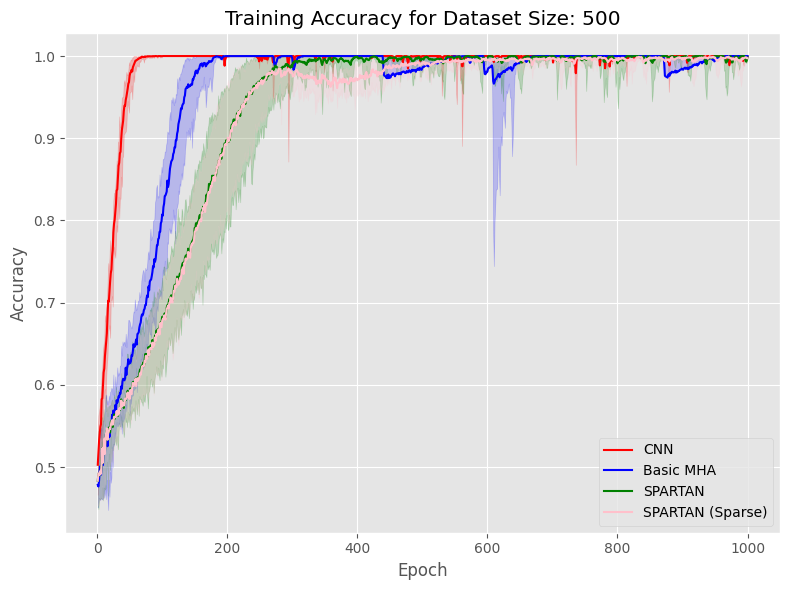

In [ ]:
plot_train([
    'cnn_500_03_Mar_2026__04h11m', 
    'transformer_500_03_Mar_2026__04h29m',
    'spartan_500_03_Mar_2026__04h38m', 
    'sparse_500_03_Mar_2026__05h42m'
], 500);

C:\Users\garga\AppData\Local\Temp\ipykernel_23860\3305488618.py:57: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\garga\AppData\Local\Temp\ipykernel_23860\3305488618.py:57: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\garga\AppData\Local\Temp\ipykernel_23860\3305488618.py:57: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\garga\AppData\Local\Temp\ipykernel_23860\3305488618.py:57: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\garga\AppData\Local\Temp\ipykernel_23860\3305488618.py:57: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


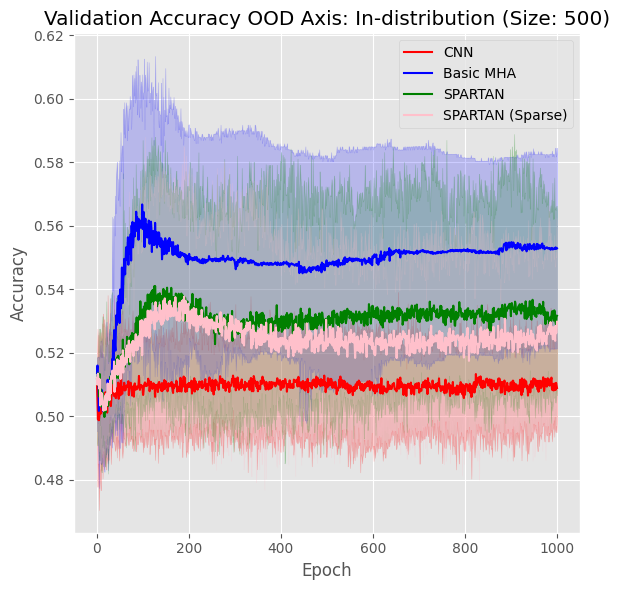

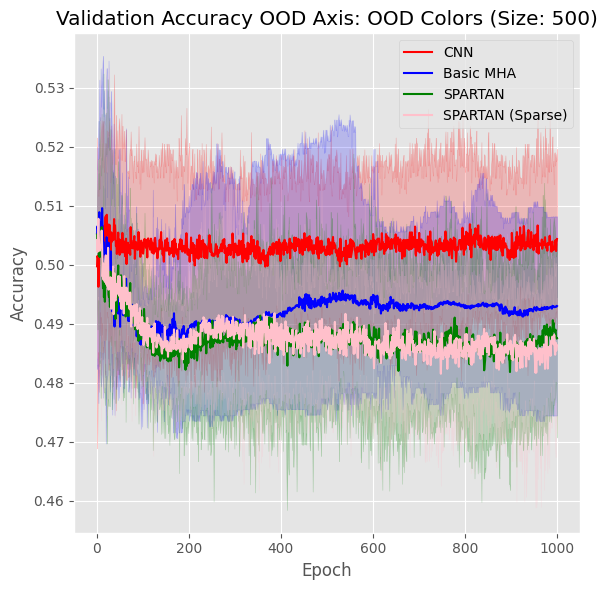

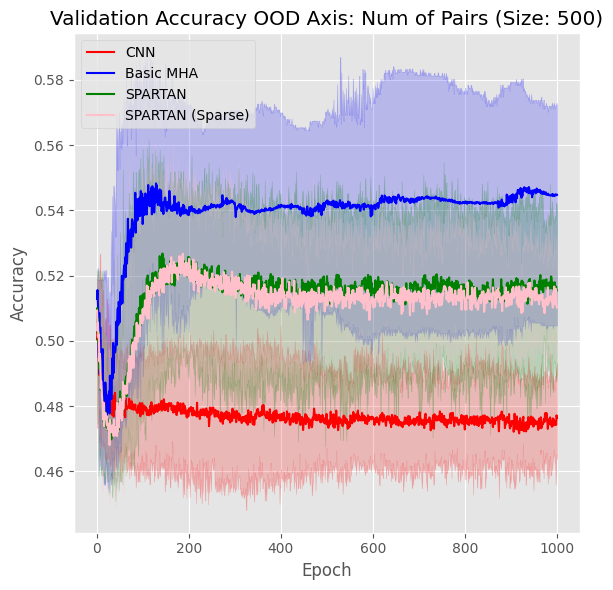

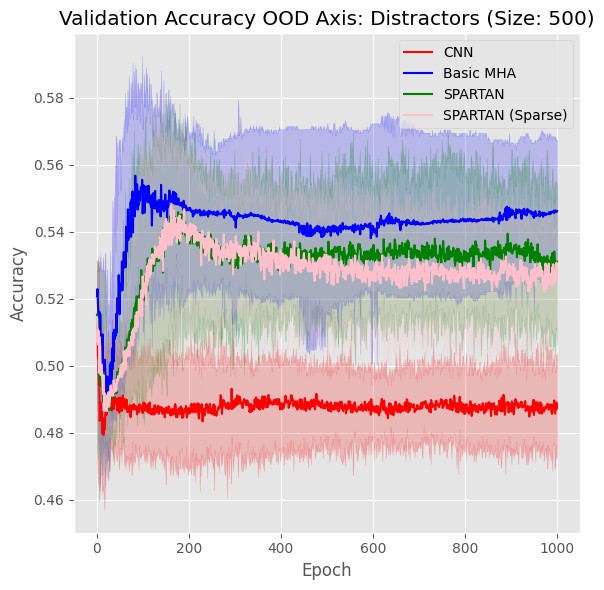

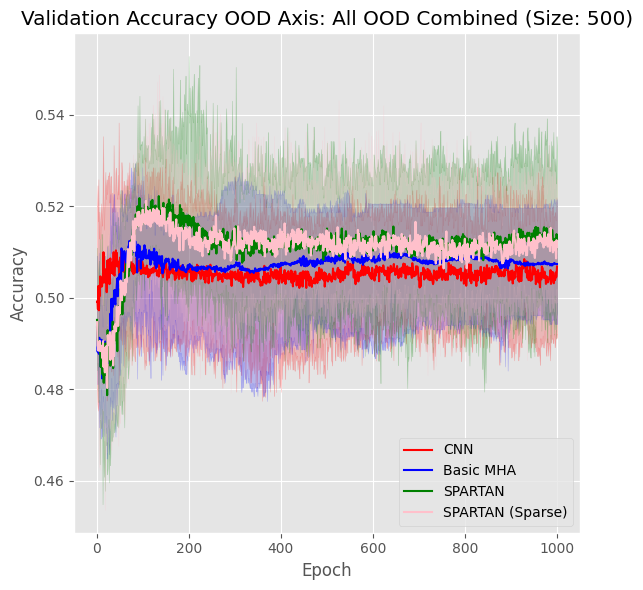

In [ ]:
plot_vals([
    'cnn_500_03_Mar_2026__04h11m', 
    'transformer_500_03_Mar_2026__04h29m',
    'spartan_500_03_Mar_2026__04h38m', 
    'sparse_500_03_Mar_2026__05h42m'
], 'id', 500)
plot_vals([
    'cnn_500_03_Mar_2026__04h11m', 
    'transformer_500_03_Mar_2026__04h29m',
    'spartan_500_03_Mar_2026__04h38m', 
    'sparse_500_03_Mar_2026__05h42m'
], 'col', 500)
plot_vals([
    'cnn_500_03_Mar_2026__04h11m', 
    'transformer_500_03_Mar_2026__04h29m',
    'spartan_500_03_Mar_2026__04h38m', 
    'sparse_500_03_Mar_2026__05h42m'
], 'pair', 500)
plot_vals([
    'cnn_500_03_Mar_2026__04h11m', 
    'transformer_500_03_Mar_2026__04h29m',
    'spartan_500_03_Mar_2026__04h38m', 
    'sparse_500_03_Mar_2026__05h42m'
], 'dist', 500)
plot_vals([
    'cnn_500_03_Mar_2026__04h11m', 
    'transformer_500_03_Mar_2026__04h29m',
    'spartan_500_03_Mar_2026__04h38m', 
    'sparse_500_03_Mar_2026__05h42m'
], 'comb', 500)

C:\Users\garga\AppData\Local\Temp\ipykernel_23860\3305488618.py:57: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\garga\AppData\Local\Temp\ipykernel_23860\3305488618.py:57: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\garga\AppData\Local\Temp\ipykernel_23860\3305488618.py:57: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\garga\AppData\Local\Temp\ipykernel_23860\3305488618.py:57: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\garga\AppData\Local\Temp\ipykernel_23860\3305488618.py:57: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


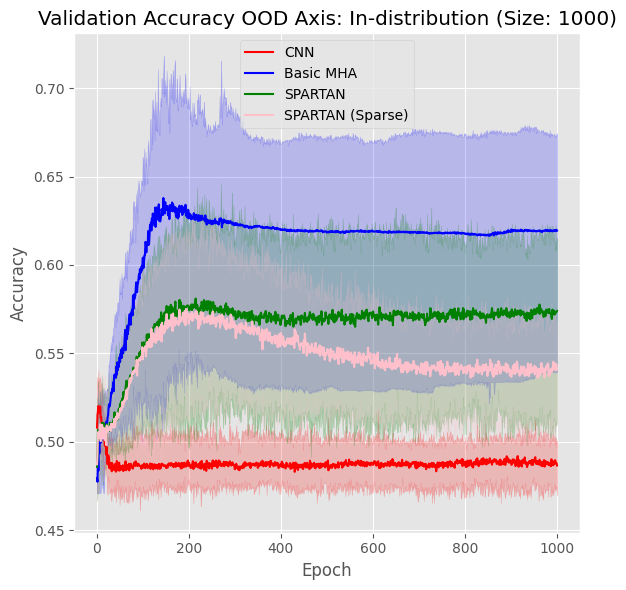

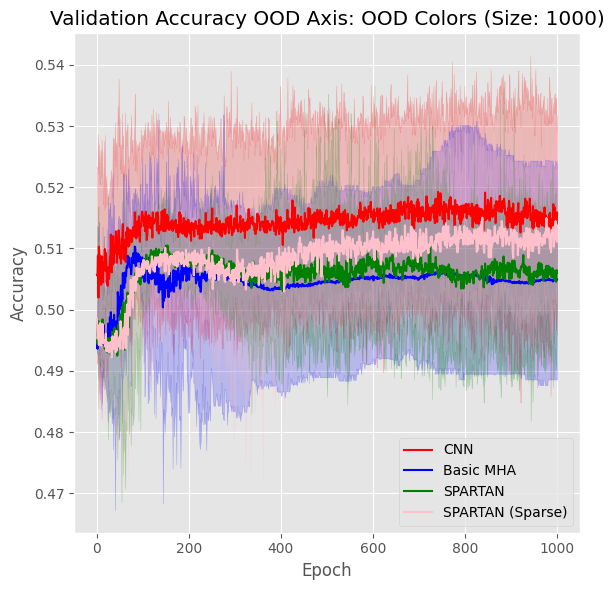

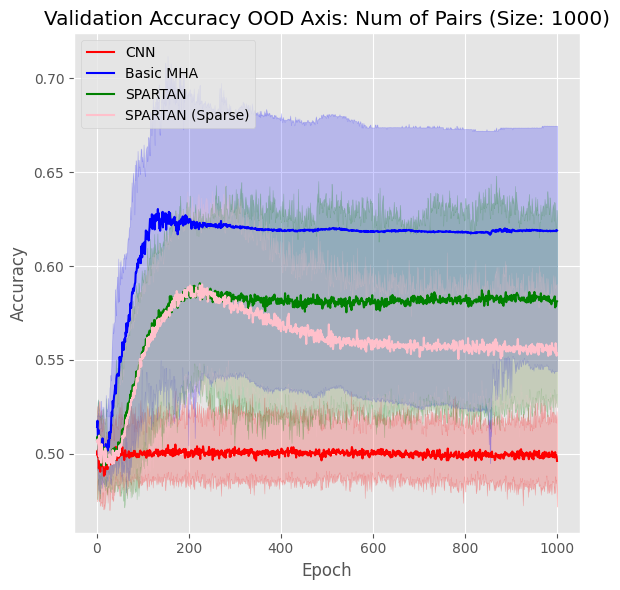

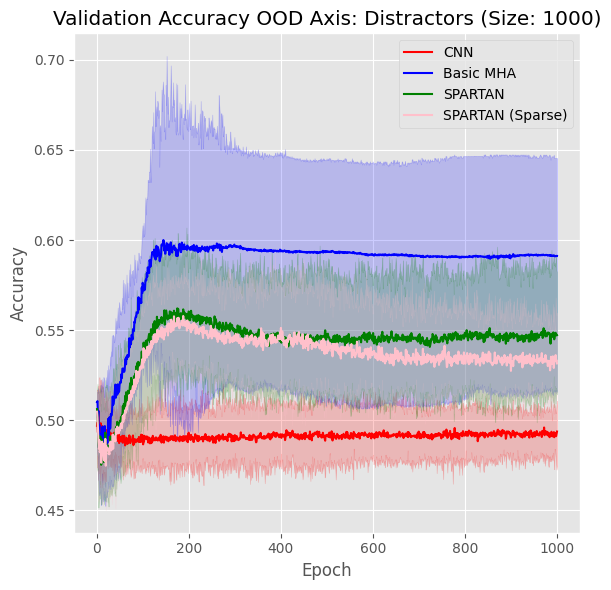

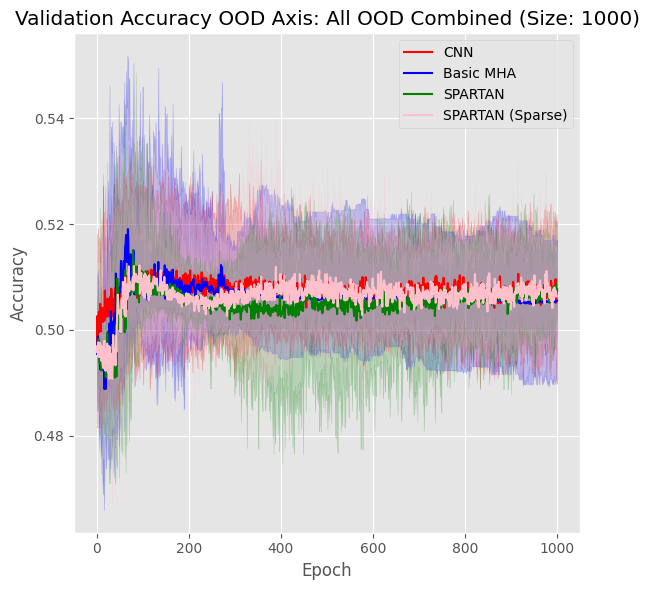

In [ ]:
plot_vals([
    'cnn_1000_03_Mar_2026__04h11m', 
    'transformer_1000_03_Mar_2026__04h29m',
    'spartan_1000_03_Mar_2026__04h38m', 
    'sparse_1000_03_Mar_2026__06h33m'
], 'id', 1000)
plot_vals([
    'cnn_1000_03_Mar_2026__04h11m', 
    'transformer_1000_03_Mar_2026__04h29m',
    'spartan_1000_03_Mar_2026__04h38m', 
    'sparse_1000_03_Mar_2026__06h33m'
], 'col', 1000)
plot_vals([
    'cnn_1000_03_Mar_2026__04h11m', 
    'transformer_1000_03_Mar_2026__04h29m',
    'spartan_1000_03_Mar_2026__04h38m', 
    'sparse_1000_03_Mar_2026__06h33m'
], 'pair', 1000)
plot_vals([
    'cnn_1000_03_Mar_2026__04h11m', 
    'transformer_1000_03_Mar_2026__04h29m',
    'spartan_1000_03_Mar_2026__04h38m', 
    'sparse_1000_03_Mar_2026__06h33m'
], 'dist', 1000)
plot_vals([
    'cnn_1000_03_Mar_2026__04h11m', 
    'transformer_1000_03_Mar_2026__04h29m',
    'spartan_1000_03_Mar_2026__04h38m', 
    'sparse_1000_03_Mar_2026__06h33m'
], 'comb', 1000)

C:\Users\garga\AppData\Local\Temp\ipykernel_23860\3305488618.py:57: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\garga\AppData\Local\Temp\ipykernel_23860\3305488618.py:57: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\garga\AppData\Local\Temp\ipykernel_23860\3305488618.py:57: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\garga\AppData\Local\Temp\ipykernel_23860\3305488618.py:57: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\garga\AppData\Local\Temp\ipykernel_23860\3305488618.py:57: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


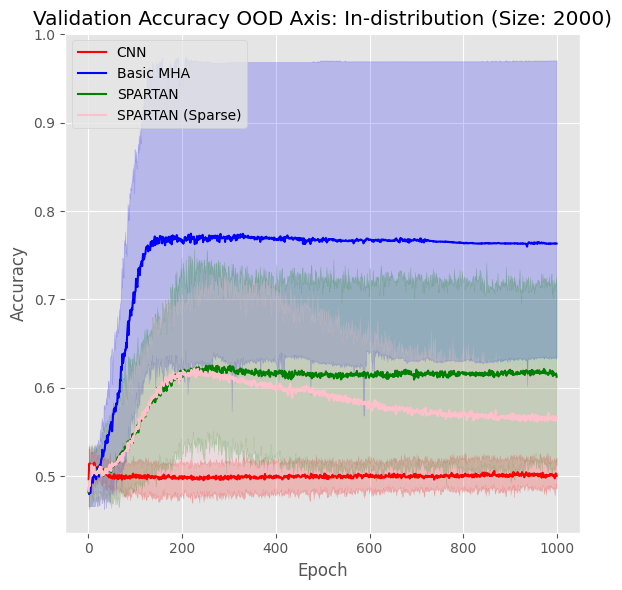

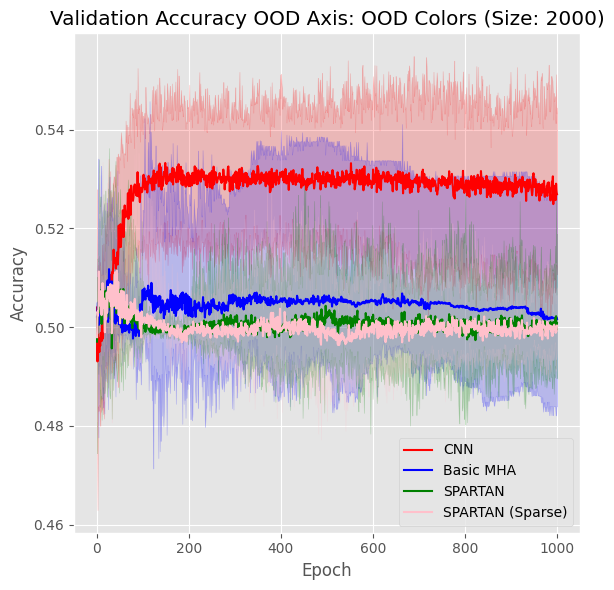

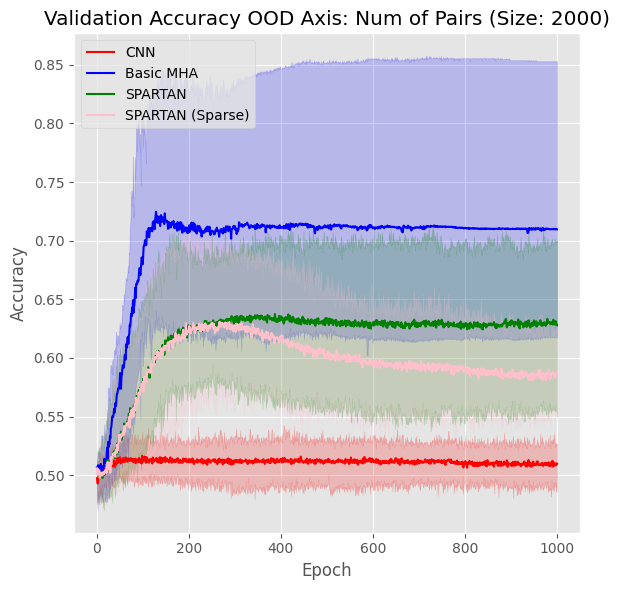

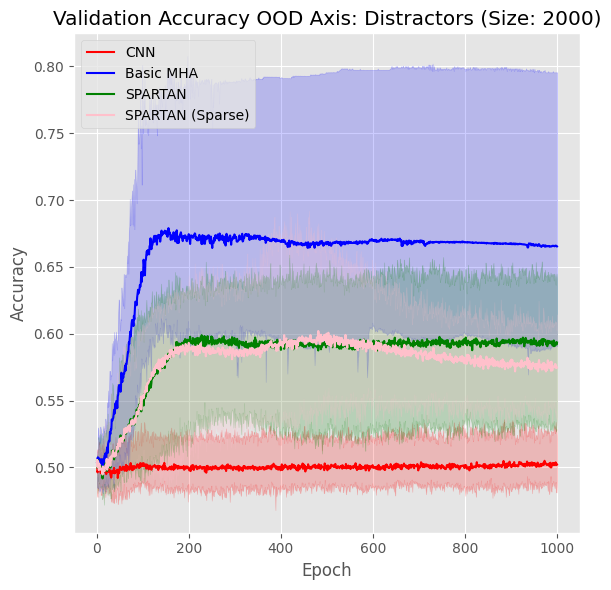

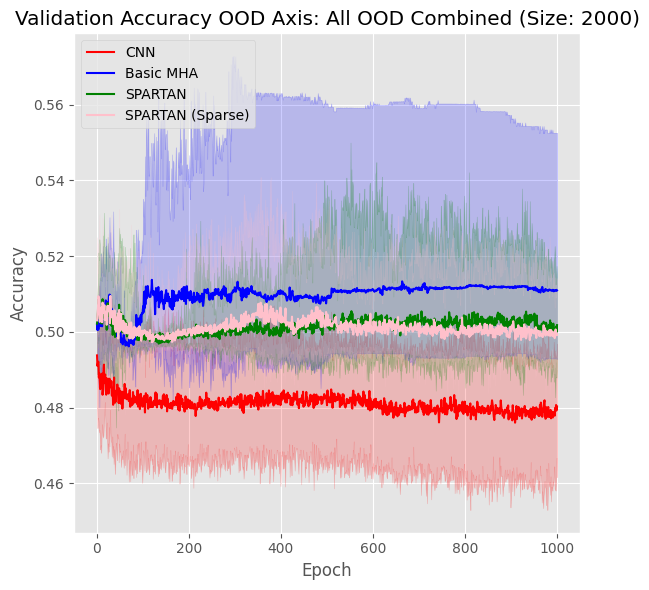

In [ ]:
plot_vals([
    'cnn_2000_03_Mar_2026__04h11m', 
    'transformer_2000_03_Mar_2026__04h29m',
    'spartan_2000_03_Mar_2026__04h38m', 
    'sparse_2000_03_Mar_2026__06h40m'
], 'id', 2000)
plot_vals([
    'cnn_2000_03_Mar_2026__04h11m', 
    'transformer_2000_03_Mar_2026__04h29m',
    'spartan_2000_03_Mar_2026__04h38m', 
    'sparse_2000_03_Mar_2026__06h40m'
], 'col', 2000)
plot_vals([
    'cnn_2000_03_Mar_2026__04h11m', 
    'transformer_2000_03_Mar_2026__04h29m',
    'spartan_2000_03_Mar_2026__04h38m', 
    'sparse_2000_03_Mar_2026__06h40m'
], 'pair', 2000)
plot_vals([
    'cnn_2000_03_Mar_2026__04h11m', 
    'transformer_2000_03_Mar_2026__04h29m',
    'spartan_2000_03_Mar_2026__04h38m', 
    'sparse_2000_03_Mar_2026__06h40m'
], 'dist', 2000)
plot_vals([
    'cnn_2000_03_Mar_2026__04h11m', 
    'transformer_2000_03_Mar_2026__04h29m',
    'spartan_2000_03_Mar_2026__04h38m', 
    'sparse_2000_03_Mar_2026__06h40m'
], 'comb', 2000)

C:\Users\garga\AppData\Local\Temp\ipykernel_23860\3305488618.py:57: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\garga\AppData\Local\Temp\ipykernel_23860\3305488618.py:57: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\garga\AppData\Local\Temp\ipykernel_23860\3305488618.py:57: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\garga\AppData\Local\Temp\ipykernel_23860\3305488618.py:57: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\garga\AppData\Local\Temp\ipykernel_23860\3305488618.py:57: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


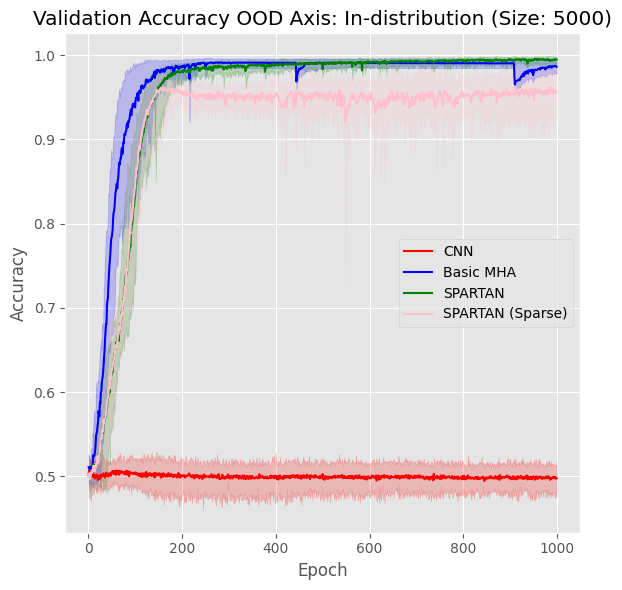

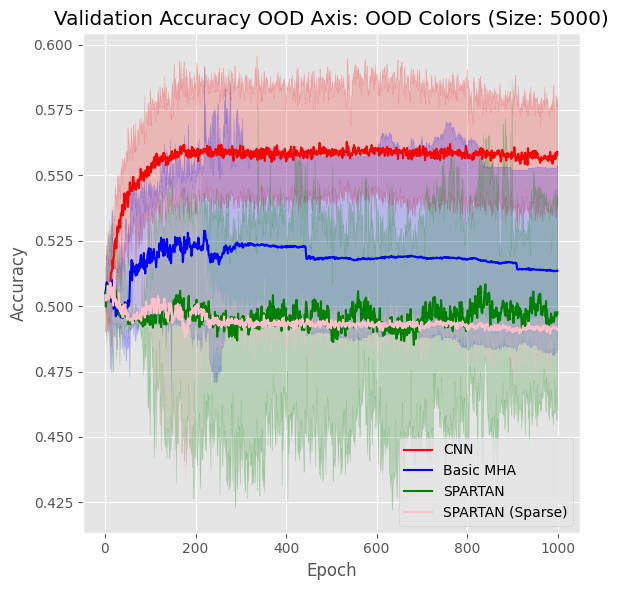

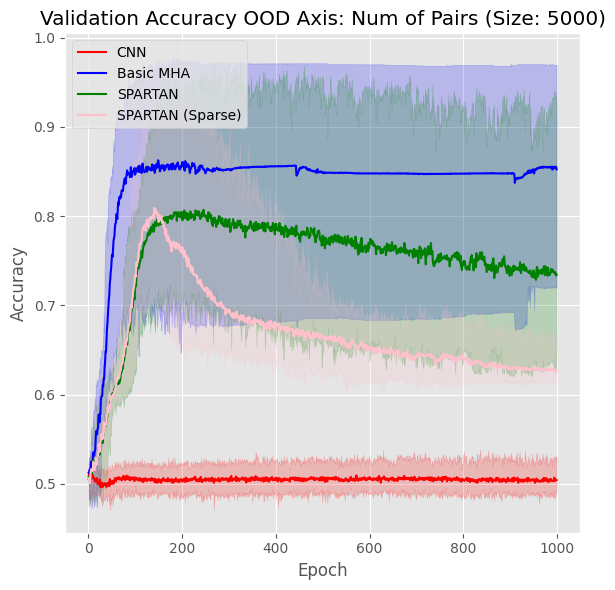

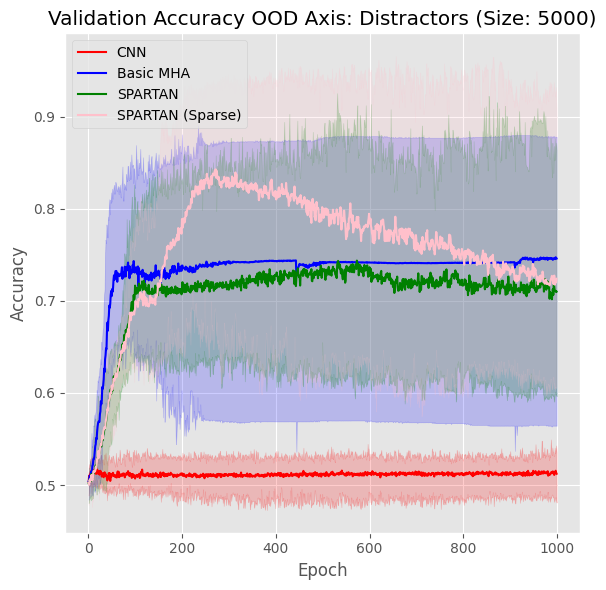

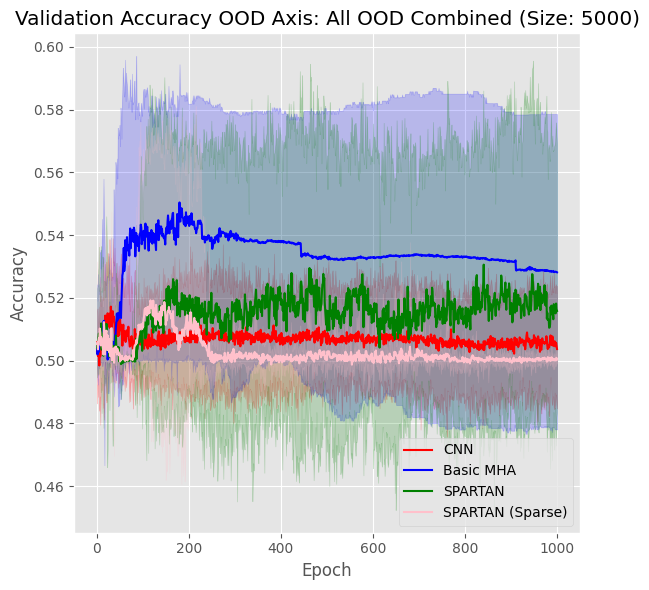

In [ ]:
plot_vals([
    'cnn_5000_03_Mar_2026__04h11m', 
    'transformer_5000_03_Mar_2026__04h29m',
    'spartan_5000_03_Mar_2026__04h38m', 
    'sparse_5000_03_Mar_2026__07h39m'
], 'id', 5000)
plot_vals([
    'cnn_5000_03_Mar_2026__04h11m', 
    'transformer_5000_03_Mar_2026__04h29m',
    'spartan_5000_03_Mar_2026__04h38m', 
    'sparse_5000_03_Mar_2026__07h39m'
], 'col', 5000)
plot_vals([
    'cnn_5000_03_Mar_2026__04h11m', 
    'transformer_5000_03_Mar_2026__04h29m',
    'spartan_5000_03_Mar_2026__04h38m', 
    'sparse_5000_03_Mar_2026__07h39m'
], 'pair', 5000)
plot_vals([
    'cnn_5000_03_Mar_2026__04h11m', 
    'transformer_5000_03_Mar_2026__04h29m',
    'spartan_5000_03_Mar_2026__04h38m', 
    'sparse_5000_03_Mar_2026__07h39m'
], 'dist', 5000)
plot_vals([
    'cnn_5000_03_Mar_2026__04h11m', 
    'transformer_5000_03_Mar_2026__04h29m',
    'spartan_5000_03_Mar_2026__04h38m', 
    'sparse_5000_03_Mar_2026__07h39m'
], 'comb', 5000)

In [ ]:
plot_vals([
    'cnn_5000_03_Mar_2026__04h11m', 
    'transformer_5000_03_Mar_2026__04h29m',
    'spartan_5000_03_Mar_2026__04h38m', 
    'sparse_5000_03_Mar_2026__07h39m'
], 'comb', 5000)

In [ ]:
draw_table([
    ['cnn_500_03_Mar_2026__04h11m', 'transformer_500_03_Mar_2026__04h29m', 'spartan_500_03_Mar_2026__04h38m', 'sparse_500_03_Mar_2026__05h42m'], 
    ['cnn_1000_03_Mar_2026__04h11m', 'transformer_1000_03_Mar_2026__04h29m', 'spartan_1000_03_Mar_2026__04h38m', 'sparse_1000_03_Mar_2026__06h33m'],
    ['cnn_2000_03_Mar_2026__04h11m', 'transformer_2000_03_Mar_2026__04h29m', 'spartan_2000_03_Mar_2026__04h38m', 'sparse_2000_03_Mar_2026__06h40m'], 
    ['cnn_5000_03_Mar_2026__04h11m', 'transformer_5000_03_Mar_2026__04h29m', 'spartan_5000_03_Mar_2026__04h38m', 'sparse_5000_03_Mar_2026__07h39m']
], 'test_id', [500, 1000, 2000, 5000])

DataSize,CNN,Basic MHA,SPARTAN,SPARSE
500,0.4978 ± 0.0062,0.5439 ± 0.0182,0.5281 ± 0.0135,0.5220 ± 0.0103
1000,0.5028 ± 0.0034,0.6268 ± 0.0446,0.5825 ± 0.0349,0.5570 ± 0.0206
2000,0.4963 ± 0.0053,0.7643 ± 0.1035,0.6231 ± 0.0666,0.5815 ± 0.0293
5000,0.4979 ± 0.0047,0.9876 ± 0.0170,0.9962 ± 0.0027,0.9569 ± 0.0196


In [ ]:
draw_table([
    ['cnn_500_03_Mar_2026__04h11m', 'transformer_500_03_Mar_2026__04h29m', 'spartan_500_03_Mar_2026__04h38m', 'sparse_500_03_Mar_2026__05h42m'], 
    ['cnn_1000_03_Mar_2026__04h11m', 'transformer_1000_03_Mar_2026__04h29m', 'spartan_1000_03_Mar_2026__04h38m', 'sparse_1000_03_Mar_2026__06h33m'],
    ['cnn_2000_03_Mar_2026__04h11m', 'transformer_2000_03_Mar_2026__04h29m', 'spartan_2000_03_Mar_2026__04h38m', 'sparse_2000_03_Mar_2026__06h40m'], 
    ['cnn_5000_03_Mar_2026__04h11m', 'transformer_5000_03_Mar_2026__04h29m', 'spartan_5000_03_Mar_2026__04h38m', 'sparse_5000_03_Mar_2026__07h39m']
], 'test_col', [500, 1000, 2000, 5000])

DataSize,CNN,Basic MHA,SPARTAN,SPARSE
500,0.5186 ± 0.0047,0.5059 ± 0.0066,0.5066 ± 0.0045,0.5094 ± 0.0040
1000,0.5210 ± 0.0033,0.4995 ± 0.0037,0.4972 ± 0.0077,0.4974 ± 0.0039
2000,0.5461 ± 0.0062,0.5058 ± 0.0129,0.5005 ± 0.0086,0.4976 ± 0.0034
5000,0.5534 ± 0.0084,0.5127 ± 0.0253,0.4993 ± 0.0244,0.5008 ± 0.0064


In [ ]:
draw_table([
    ['cnn_500_03_Mar_2026__04h11m', 'transformer_500_03_Mar_2026__04h29m', 'spartan_500_03_Mar_2026__04h38m', 'sparse_500_03_Mar_2026__05h42m'], 
    ['cnn_1000_03_Mar_2026__04h11m', 'transformer_1000_03_Mar_2026__04h29m', 'spartan_1000_03_Mar_2026__04h38m', 'sparse_1000_03_Mar_2026__06h33m'],
    ['cnn_2000_03_Mar_2026__04h11m', 'transformer_2000_03_Mar_2026__04h29m', 'spartan_2000_03_Mar_2026__04h38m', 'sparse_2000_03_Mar_2026__06h40m'], 
    ['cnn_5000_03_Mar_2026__04h11m', 'transformer_5000_03_Mar_2026__04h29m', 'spartan_5000_03_Mar_2026__04h38m', 'sparse_5000_03_Mar_2026__07h39m']
], 'test_pair', [500, 1000, 2000, 5000])

DataSize,CNN,Basic MHA,SPARTAN,SPARSE
500,0.5146 ± 0.0035,0.5492 ± 0.0194,0.5292 ± 0.0138,0.5274 ± 0.0103
1000,0.4981 ± 0.0040,0.6121 ± 0.0420,0.5692 ± 0.0320,0.5480 ± 0.0152
2000,0.5040 ± 0.0045,0.7062 ± 0.0850,0.6140 ± 0.0564,0.5766 ± 0.0258
5000,0.4980 ± 0.0057,0.8457 ± 0.0801,0.7315 ± 0.0867,0.6368 ± 0.0106


In [ ]:
draw_table([
    ['cnn_500_03_Mar_2026__04h11m', 'transformer_500_03_Mar_2026__04h29m', 'spartan_500_03_Mar_2026__04h38m', 'sparse_500_03_Mar_2026__05h42m'], 
    ['cnn_1000_03_Mar_2026__04h11m', 'transformer_1000_03_Mar_2026__04h29m', 'spartan_1000_03_Mar_2026__04h38m', 'sparse_1000_03_Mar_2026__06h33m'],
    ['cnn_2000_03_Mar_2026__04h11m', 'transformer_2000_03_Mar_2026__04h29m', 'spartan_2000_03_Mar_2026__04h38m', 'sparse_2000_03_Mar_2026__06h40m'], 
    ['cnn_5000_03_Mar_2026__04h11m', 'transformer_5000_03_Mar_2026__04h29m', 'spartan_5000_03_Mar_2026__04h38m', 'sparse_5000_03_Mar_2026__07h39m']
], 'test_dist', [500, 1000, 2000, 5000])

DataSize,CNN,Basic MHA,SPARTAN,SPARSE
500,0.4959 ± 0.0048,0.5404 ± 0.0211,0.5191 ± 0.0126,0.5160 ± 0.0090
1000,0.4987 ± 0.0061,0.6049 ± 0.0440,0.5594 ± 0.0239,0.5452 ± 0.0153
2000,0.5053 ± 0.0069,0.6868 ± 0.0644,0.6029 ± 0.0417,0.5854 ± 0.0270
5000,0.5013 ± 0.0044,0.7493 ± 0.0946,0.7198 ± 0.0920,0.7297 ± 0.1019


In [ ]:
draw_table([
    ['cnn_500_03_Mar_2026__04h11m', 'transformer_500_03_Mar_2026__04h29m', 'spartan_500_03_Mar_2026__04h38m', 'sparse_500_03_Mar_2026__05h42m'], 
    ['cnn_1000_03_Mar_2026__04h11m', 'transformer_1000_03_Mar_2026__04h29m', 'spartan_1000_03_Mar_2026__04h38m', 'sparse_1000_03_Mar_2026__06h33m'],
    ['cnn_2000_03_Mar_2026__04h11m', 'transformer_2000_03_Mar_2026__04h29m', 'spartan_2000_03_Mar_2026__04h38m', 'sparse_2000_03_Mar_2026__06h40m'], 
    ['cnn_5000_03_Mar_2026__04h11m', 'transformer_5000_03_Mar_2026__04h29m', 'spartan_5000_03_Mar_2026__04h38m', 'sparse_5000_03_Mar_2026__07h39m']
], 'test_comb', [500, 1000, 2000, 5000])

DataSize,CNN,Basic MHA,SPARTAN,SPARSE
500,0.4975 ± 0.0038,0.5003 ± 0.0061,0.5014 ± 0.0053,0.5035 ± 0.0048
1000,0.5012 ± 0.0053,0.4994 ± 0.0060,0.5016 ± 0.0033,0.5003 ± 0.0040
2000,0.4980 ± 0.0057,0.5065 ± 0.0156,0.5071 ± 0.0110,0.5022 ± 0.0052
5000,0.4940 ± 0.0071,0.5151 ± 0.0300,0.4987 ± 0.0265,0.4983 ± 0.0050


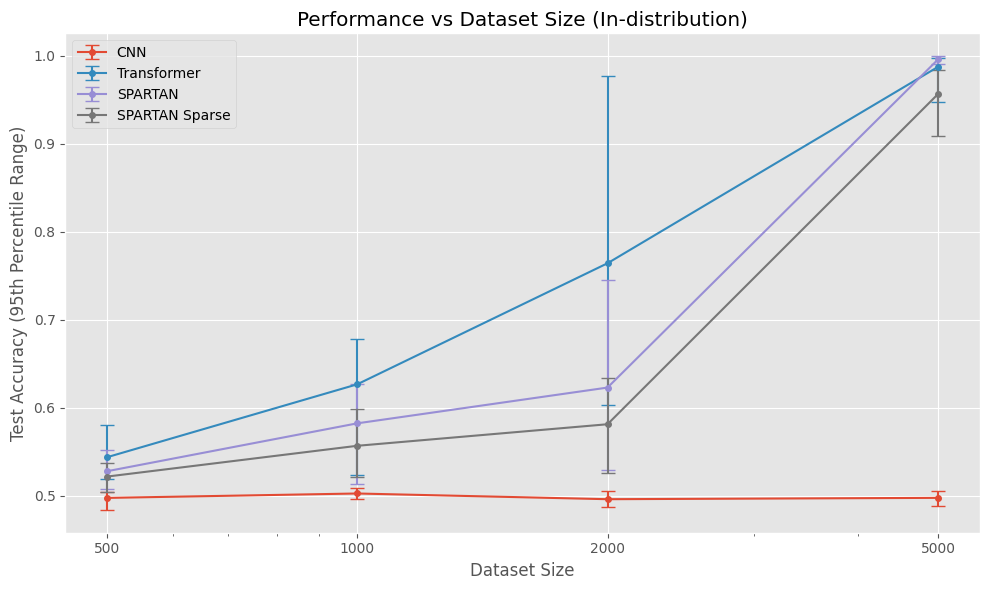

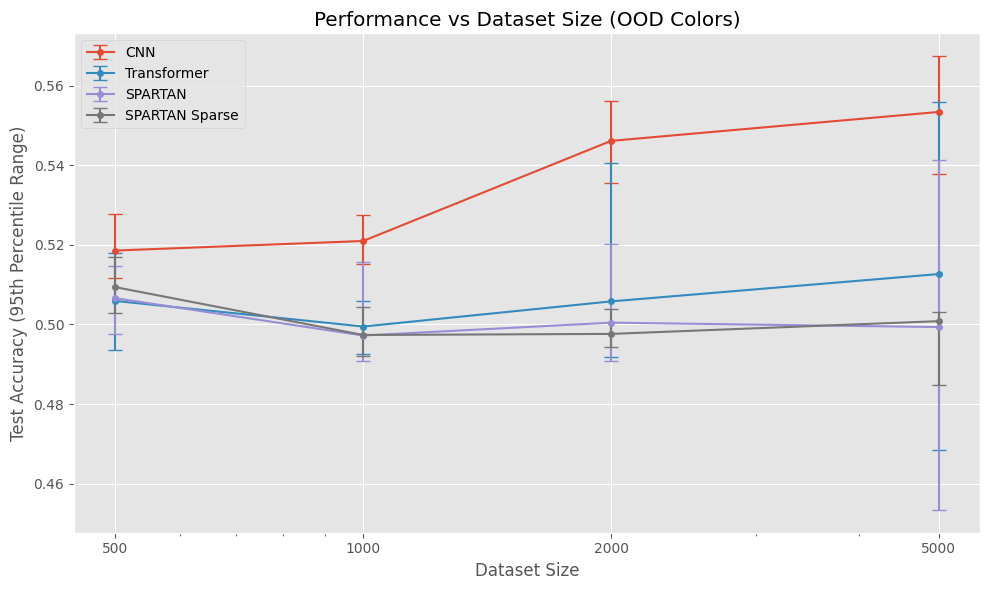

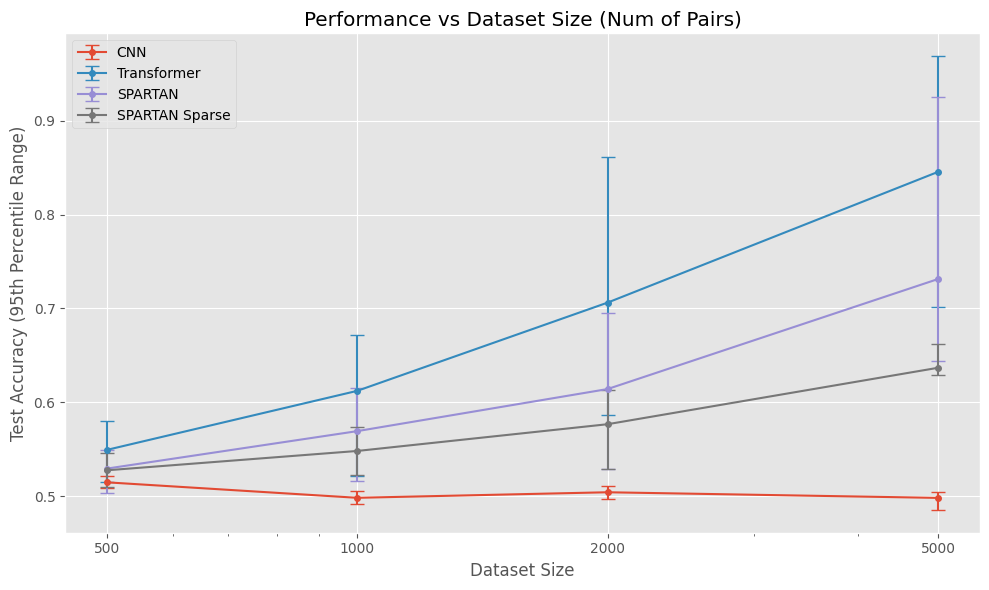

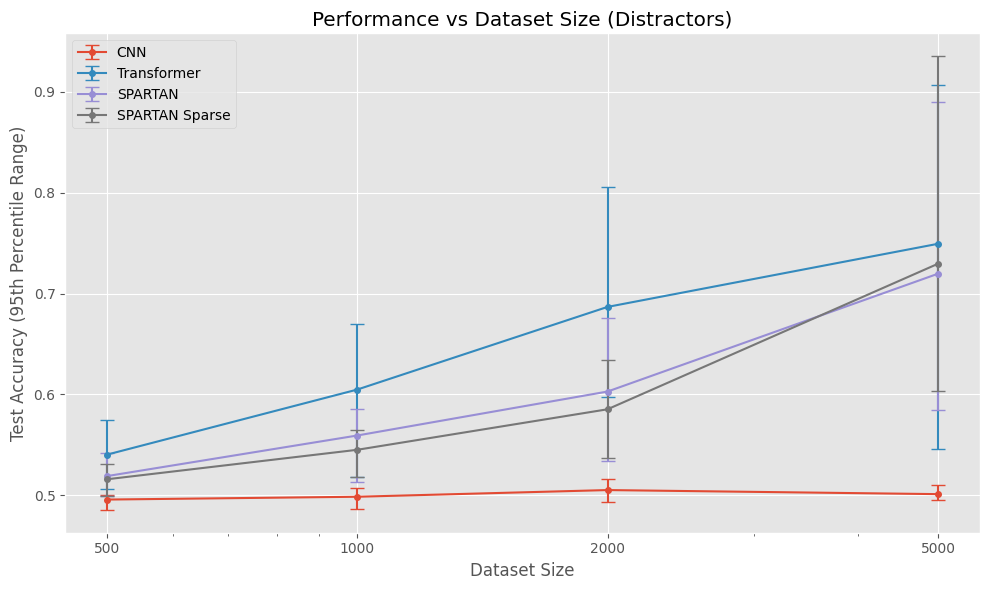

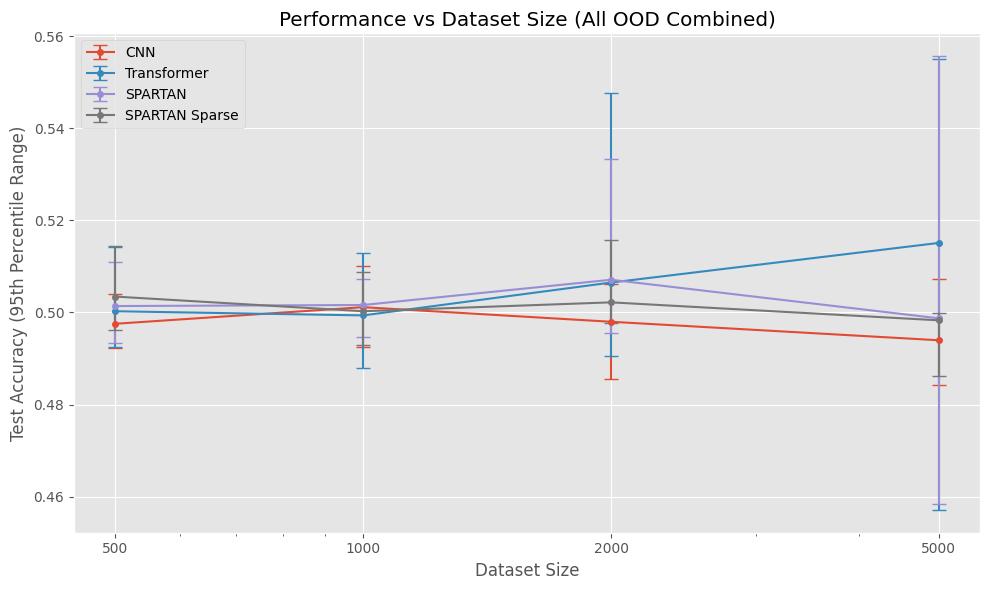

In [ ]:
plot_size_test([
    ['cnn_500_03_Mar_2026__04h11m', 'transformer_500_03_Mar_2026__04h29m', 'spartan_500_03_Mar_2026__04h38m', 'sparse_500_03_Mar_2026__05h42m'], 
    ['cnn_1000_03_Mar_2026__04h11m', 'transformer_1000_03_Mar_2026__04h29m', 'spartan_1000_03_Mar_2026__04h38m', 'sparse_1000_03_Mar_2026__06h33m'],
    ['cnn_2000_03_Mar_2026__04h11m', 'transformer_2000_03_Mar_2026__04h29m', 'spartan_2000_03_Mar_2026__04h38m', 'sparse_2000_03_Mar_2026__06h40m'], 
    ['cnn_5000_03_Mar_2026__04h11m', 'transformer_5000_03_Mar_2026__04h29m', 'spartan_5000_03_Mar_2026__04h38m', 'sparse_5000_03_Mar_2026__07h39m']
], 'test_id', [500, 1000, 2000, 5000])
plot_size_test([
    ['cnn_500_03_Mar_2026__04h11m', 'transformer_500_03_Mar_2026__04h29m', 'spartan_500_03_Mar_2026__04h38m', 'sparse_500_03_Mar_2026__05h42m'], 
    ['cnn_1000_03_Mar_2026__04h11m', 'transformer_1000_03_Mar_2026__04h29m', 'spartan_1000_03_Mar_2026__04h38m', 'sparse_1000_03_Mar_2026__06h33m'],
    ['cnn_2000_03_Mar_2026__04h11m', 'transformer_2000_03_Mar_2026__04h29m', 'spartan_2000_03_Mar_2026__04h38m', 'sparse_2000_03_Mar_2026__06h40m'], 
    ['cnn_5000_03_Mar_2026__04h11m', 'transformer_5000_03_Mar_2026__04h29m', 'spartan_5000_03_Mar_2026__04h38m', 'sparse_5000_03_Mar_2026__07h39m']
], 'test_col', [500, 1000, 2000, 5000])
plot_size_test([
    ['cnn_500_03_Mar_2026__04h11m', 'transformer_500_03_Mar_2026__04h29m', 'spartan_500_03_Mar_2026__04h38m', 'sparse_500_03_Mar_2026__05h42m'], 
    ['cnn_1000_03_Mar_2026__04h11m', 'transformer_1000_03_Mar_2026__04h29m', 'spartan_1000_03_Mar_2026__04h38m', 'sparse_1000_03_Mar_2026__06h33m'],
    ['cnn_2000_03_Mar_2026__04h11m', 'transformer_2000_03_Mar_2026__04h29m', 'spartan_2000_03_Mar_2026__04h38m', 'sparse_2000_03_Mar_2026__06h40m'], 
    ['cnn_5000_03_Mar_2026__04h11m', 'transformer_5000_03_Mar_2026__04h29m', 'spartan_5000_03_Mar_2026__04h38m', 'sparse_5000_03_Mar_2026__07h39m']
], 'test_pair', [500, 1000, 2000, 5000])
plot_size_test([
    ['cnn_500_03_Mar_2026__04h11m', 'transformer_500_03_Mar_2026__04h29m', 'spartan_500_03_Mar_2026__04h38m', 'sparse_500_03_Mar_2026__05h42m'], 
    ['cnn_1000_03_Mar_2026__04h11m', 'transformer_1000_03_Mar_2026__04h29m', 'spartan_1000_03_Mar_2026__04h38m', 'sparse_1000_03_Mar_2026__06h33m'],
    ['cnn_2000_03_Mar_2026__04h11m', 'transformer_2000_03_Mar_2026__04h29m', 'spartan_2000_03_Mar_2026__04h38m', 'sparse_2000_03_Mar_2026__06h40m'], 
    ['cnn_5000_03_Mar_2026__04h11m', 'transformer_5000_03_Mar_2026__04h29m', 'spartan_5000_03_Mar_2026__04h38m', 'sparse_5000_03_Mar_2026__07h39m']
], 'test_dist', [500, 1000, 2000, 5000])
plot_size_test([
    ['cnn_500_03_Mar_2026__04h11m', 'transformer_500_03_Mar_2026__04h29m', 'spartan_500_03_Mar_2026__04h38m', 'sparse_500_03_Mar_2026__05h42m'], 
    ['cnn_1000_03_Mar_2026__04h11m', 'transformer_1000_03_Mar_2026__04h29m', 'spartan_1000_03_Mar_2026__04h38m', 'sparse_1000_03_Mar_2026__06h33m'],
    ['cnn_2000_03_Mar_2026__04h11m', 'transformer_2000_03_Mar_2026__04h29m', 'spartan_2000_03_Mar_2026__04h38m', 'sparse_2000_03_Mar_2026__06h40m'], 
    ['cnn_5000_03_Mar_2026__04h11m', 'transformer_5000_03_Mar_2026__04h29m', 'spartan_5000_03_Mar_2026__04h38m', 'sparse_5000_03_Mar_2026__07h39m']
], 'test_comb', [500, 1000, 2000, 5000])

In [ ]:
draw_table_pairs('cnn')

DataSize,Train_2pairs,Train_3pairs,TestID_2pairs,TestID_3pairs,TestCOL_2pairs,TestCOL_3pairs,TestPA_2pairs,TestPA_3pairs,TestDIS_2pairs,TestDIS_3pairs,TestCOM_2pairs,TestCOM_3pairs
500,0.9753 ± 0.0024,0.9772 ± 0.0074,0.4718 ± 0.0026,0.4670 ± 0.0057,0.4999 ± 0.0012,0.5007 ± 0.0032,0.5031 ± 0.0038,0.4968 ± 0.0033,0.5033 ± 0.0042,0.5013 ± 0.0013,0.4978 ± 0.0021,0.4970 ± 0.0019
1000,0.9740 ± 0.0070,0.9873 ± 0.0029,0.4451 ± 0.0016,0.4289 ± 0.0010,0.5002 ± 0.0050,0.5046 ± 0.0006,0.5059 ± 0.0027,0.4977 ± 0.0018,0.4980 ± 0.0072,0.5003 ± 0.0022,0.5008 ± 0.0043,0.5038 ± 0.0018
2000,0.9473 ± 0.0131,0.9621 ± 0.0116,0.4134 ± 0.0034,0.4071 ± 0.0036,0.4994 ± 0.0010,0.5030 ± 0.0017,0.5034 ± 0.0071,0.5013 ± 0.0022,0.5013 ± 0.0015,0.5006 ± 0.0018,0.4971 ± 0.0006,0.4991 ± 0.0011
5000,0.5074 ± 0.0000,0.4973 ± 0.0002,0.4948 ± 0.0000,0.5004 ± 0.0000,0.4990 ± 0.0000,0.5024 ± 0.0000,0.4976 ± 0.0000,0.4982 ± 0.0000,0.5004 ± 0.0000,0.4998 ± 0.0000,0.4982 ± 0.0000,0.4964 ± 0.0000
10000,0.4962 ± 0.0009,0.5018 ± 0.0012,0.5052 ± 0.0000,0.4918 ± 0.0000,0.5060 ± 0.0000,0.5034 ± 0.0000,0.5000 ± 0.0000,0.4996 ± 0.0000,0.4938 ± 0.0000,0.5016 ± 0.0000,0.4994 ± 0.0000,0.5004 ± 0.0000


In [ ]:
draw_table_pairs('basic_mha')

DataSize,Train_2pairs,Train_3pairs,TestID_2pairs,TestID_3pairs,TestCOL_2pairs,TestCOL_3pairs,TestPA_2pairs,TestPA_3pairs,TestDIS_2pairs,TestDIS_3pairs,TestCOM_2pairs,TestCOM_3pairs
500,0.9935 ± 0.0051,0.9980 ± 0.0000,0.4751 ± 0.0024,0.4707 ± 0.0065,0.4940 ± 0.0033,0.5003 ± 0.0019,0.5059 ± 0.0038,0.4998 ± 0.0042,0.5006 ± 0.0027,0.5024 ± 0.0024,0.4960 ± 0.0032,0.5004 ± 0.0056
1000,0.9059 ± 0.1160,0.9827 ± 0.0161,0.4681 ± 0.0073,0.4422 ± 0.0012,0.5047 ± 0.0039,0.5039 ± 0.0030,0.5033 ± 0.0026,0.5072 ± 0.0013,0.5044 ± 0.0054,0.5009 ± 0.0071,0.5040 ± 0.0017,0.5051 ± 0.0026
2000,0.9601 ± 0.0488,0.9894 ± 0.0030,0.4543 ± 0.0265,0.4137 ± 0.0050,0.5006 ± 0.0069,0.5031 ± 0.0019,0.5093 ± 0.0118,0.5039 ± 0.0033,0.5225 ± 0.0122,0.5063 ± 0.0050,0.5007 ± 0.0027,0.5010 ± 0.0013
5000,1.0000 ± 0.0000,0.9800 ± 0.0059,0.9658 ± 0.0149,0.3619 ± 0.0088,0.5186 ± 0.0465,0.5027 ± 0.0005,0.6569 ± 0.0054,0.5067 ± 0.0018,0.9387 ± 0.0323,0.5093 ± 0.0048,0.5048 ± 0.0107,0.5005 ± 0.0021
10000,0.9909 ± 0.0129,0.9564 ± 0.0147,0.7861 ± 0.2944,0.3451 ± 0.0091,0.5260 ± 0.0217,0.5007 ± 0.0053,0.6156 ± 0.0772,0.5058 ± 0.0026,0.8078 ± 0.2115,0.5027 ± 0.0007,0.5032 ± 0.0074,0.4966 ± 0.0022


In [ ]:
draw_table_pairs('bern_sparse', spartan=True, sizes=[500, 1000, 2000, 5000])

DataSize,Train_2pairs,Train_3pairs,TestID_2pairs,TestID_3pairs,TestCOL_2pairs,TestCOL_3pairs,TestPA_2pairs,TestPA_3pairs,TestDIS_2pairs,TestDIS_3pairs,TestCOM_2pairs,TestCOM_3pairs
500,0.9701 ± 0.0285,0.9954 ± 0.0040,0.4792 ± 0.0032,0.4670 ± 0.0056,0.4987 ± 0.0036,0.5062 ± 0.0065,0.4997 ± 0.0068,0.5023 ± 0.0046,0.4979 ± 0.0024,0.5001 ± 0.0060,0.4952 ± 0.0027,0.4996 ± 0.0042
1000,0.9896 ± 0.0044,0.9828 ± 0.0005,0.4553 ± 0.0039,0.4408 ± 0.0024,0.5007 ± 0.0011,0.4967 ± 0.0035,0.5009 ± 0.0064,0.5028 ± 0.0021,0.5062 ± 0.0014,0.5019 ± 0.0073,0.5016 ± 0.0036,0.5011 ± 0.0064
2000,0.9775 ± 0.0060,0.9801 ± 0.0043,0.4381 ± 0.0046,0.4231 ± 0.0046,0.4991 ± 0.0032,0.5005 ± 0.0004,0.5125 ± 0.0062,0.4986 ± 0.0059,0.5099 ± 0.0085,0.5038 ± 0.0012,0.4966 ± 0.0049,0.5002 ± 0.0022
5000,0.9702 ± 0.0098,0.9522 ± 0.0053,0.7501 ± 0.0958,0.3664 ± 0.0048,0.5036 ± 0.0046,0.5023 ± 0.0026,0.5928 ± 0.0230,0.4995 ± 0.0023,0.7444 ± 0.0836,0.5071 ± 0.0016,0.5024 ± 0.0011,0.4993 ± 0.0022


In [ ]:
with open('../results/cnn_shapes_500.pl', 'rb') as f:
    results = dill.load(f)

In [ ]:
results[0]['test_a']

[{'test/loss_a': 2.3894426822662354, 'test/acc_a': 0.7002000212669373}]

In [ ]:
draw_table_shapes('cnn')

DataSize,Train,TestID,TestA,TestB
250,1.0000 ± 0.0000,0.5871 ± 0.0592,0.5493 ± 0.0303,0.5440 ± 0.0278
500,1.0000 ± 0.0000,0.7503 ± 0.1162,0.6388 ± 0.0818,0.6221 ± 0.0496
1000,1.0000 ± 0.0000,0.9591 ± 0.0034,0.7623 ± 0.0490,0.7883 ± 0.0238
2000,1.0000 ± 0.0000,0.9791 ± 0.0005,0.7871 ± 0.0429,0.7762 ± 0.0163
5000,1.0000 ± 0.0000,0.9815 ± 0.0019,0.7439 ± 0.0574,0.7654 ± 0.0418
10000,1.0000 ± 0.0000,0.9885 ± 0.0016,0.6782 ± 0.0229,0.6812 ± 0.0411
20000,1.0000 ± 0.0000,0.9950 ± 0.0006,0.5932 ± 0.0191,0.6153 ± 0.0119


In [ ]:
draw_table_shapes('basic')

DataSize,Train,TestID,TestA,TestB
250,1.0000 ± 0.0000,0.5075 ± 0.0033,0.5003 ± 0.0020,0.4901 ± 0.0073
500,1.0000 ± 0.0000,0.5090 ± 0.0045,0.5101 ± 0.0045,0.4991 ± 0.0089
1000,0.9857 ± 0.0203,0.5317 ± 0.0187,0.5154 ± 0.0137,0.5169 ± 0.0082
2000,1.0000 ± 0.0000,0.8560 ± 0.0328,0.5197 ± 0.0197,0.7783 ± 0.0638
5000,1.0000 ± 0.0000,0.9161 ± 0.0400,0.6766 ± 0.1088,0.5830 ± 0.0627
10000,0.9723 ± 0.0238,0.9563 ± 0.0197,0.6901 ± 0.1609,0.5674 ± 0.0502
20000,0.9838 ± 0.0080,0.9466 ± 0.0465,0.5494 ± 0.0148,0.6276 ± 0.0871


In [ ]:
draw_table_shapes('cnn', grid=5)

DataSize,Train,TestID,TestA,TestB
250,1.0000 ± 0.0000,0.5221 ± 0.0049,0.5128 ± 0.0061,0.5002 ± 0.0040
500,1.0000 ± 0.0000,0.5450 ± 0.0063,0.5300 ± 0.0084,0.5131 ± 0.0083
1000,1.0000 ± 0.0000,0.6033 ± 0.0214,0.5456 ± 0.0114,0.5594 ± 0.0175
2000,1.0000 ± 0.0000,0.7780 ± 0.0346,0.6364 ± 0.0410,0.6183 ± 0.0438
5000,1.0000 ± 0.0000,0.9146 ± 0.0212,0.5934 ± 0.0374,0.6516 ± 0.0771
10000,1.0000 ± 0.0000,0.9584 ± 0.0048,0.5873 ± 0.0106,0.5974 ± 0.0213
20000,1.0000 ± 0.0000,0.9742 ± 0.0022,0.5722 ± 0.0029,0.5792 ± 0.0037
40000,0.9986 ± 0.0010,0.9771 ± 0.0030,0.5681 ± 0.0022,0.5713 ± 0.0019


In [ ]:
draw_table_shapes('cnn', grid=8)

DataSize,Train,TestID,TestA,TestB
250,1.0000 ± 0.0000,0.5035 ± 0.0036,0.5018 ± 0.0020,0.5139 ± 0.0067
500,1.0000 ± 0.0000,0.4966 ± 0.0026,0.5026 ± 0.0066,0.5089 ± 0.0023
1000,1.0000 ± 0.0000,0.5036 ± 0.0054,0.5025 ± 0.0068,0.5087 ± 0.0041
2000,1.0000 ± 0.0000,0.5234 ± 0.0122,0.5070 ± 0.0032,0.5170 ± 0.0098
5000,1.0000 ± 0.0000,0.5947 ± 0.0495,0.5473 ± 0.0288,0.5536 ± 0.0297
10000,0.8751 ± 0.2155,0.6856 ± 0.1215,0.6065 ± 0.0656,0.6066 ± 0.0789
20000,0.9874 ± 0.0215,0.8264 ± 0.0700,0.6545 ± 0.0344,0.6557 ± 0.0231
40000,0.9987 ± 0.0012,0.8965 ± 0.0055,0.6637 ± 0.0178,0.6672 ± 0.0035


In [ ]:
draw_table_shapes('trans', grid=5)

DataSize,Train,TestID,TestA,TestB
250,1.0000 ± 0.0000,0.5094 ± 0.0101,0.5083 ± 0.0084,0.5009 ± 0.0036
500,1.0000 ± 0.0000,0.5171 ± 0.0086,0.5022 ± 0.0103,0.5080 ± 0.0076
1000,1.0000 ± 0.0000,0.6100 ± 0.1325,0.5538 ± 0.0622,0.5369 ± 0.0343
2000,1.0000 ± 0.0000,0.8831 ± 0.0130,0.5016 ± 0.0038,0.8686 ± 0.0225
5000,1.0000 ± 0.0000,0.9041 ± 0.0464,0.5165 ± 0.0285,0.7995 ± 0.1337
10000,0.9931 ± 0.0069,0.9790 ± 0.0012,0.5692 ± 0.0059,0.5672 ± 0.0036
20000,0.9918 ± 0.0056,0.9812 ± 0.0015,0.5734 ± 0.0102,0.5666 ± 0.0024
40000,0.9916 ± 0.0041,0.9822 ± 0.0036,0.5666 ± 0.0008,0.5679 ± 0.0005


In [ ]:
draw_table_shapes('trans', grid=8)

DataSize,Train,TestID,TestA,TestB
250,0.9775 ± 0.0257,0.5023 ± 0.0043,0.4993 ± 0.0057,0.5016 ± 0.0039
500,1.0000 ± 0.0000,0.5010 ± 0.0061,0.4990 ± 0.0025,0.5023 ± 0.0056
1000,1.0000 ± 0.0000,0.5023 ± 0.0064,0.5053 ± 0.0014,0.4950 ± 0.0040
2000,0.9989 ± 0.0019,0.7034 ± 0.1989,0.5023 ± 0.0036,0.7050 ± 0.2035
5000,1.0000 ± 0.0000,0.6047 ± 0.1784,0.5980 ± 0.1786,0.5029 ± 0.0119
10000,0.9978 ± 0.0016,0.9475 ± 0.0417,0.7403 ± 0.1712,0.5247 ± 0.0242
20000,0.9924 ± 0.0093,0.9572 ± 0.0353,0.5249 ± 0.0249,0.7429 ± 0.1849
40000,0.9912 ± 0.0060,0.9522 ± 0.0406,0.7325 ± 0.1791,0.5235 ± 0.0261


In [ ]:
draw_table_shapes('sparse', spartan=True, grid=5)

DataSize,Train,TestID,TestA,TestB
250,1.0000 ± 0.0000,0.5034 ± 0.0011,0.4995 ± 0.0062,0.4923 ± 0.0058
500,1.0000 ± 0.0000,0.5300 ± 0.0169,0.5078 ± 0.0169,0.5153 ± 0.0263
1000,0.9998 ± 0.0004,0.6930 ± 0.1927,0.5661 ± 0.0745,0.5808 ± 0.0773
2000,0.9979 ± 0.0036,0.8787 ± 0.0174,0.5115 ± 0.0071,0.8615 ± 0.0215
5000,0.9977 ± 0.0034,0.9378 ± 0.0420,0.5528 ± 0.0291,0.6944 ± 0.1183
10000,0.9946 ± 0.0036,0.9778 ± 0.0023,0.5824 ± 0.0038,0.5792 ± 0.0040
20000,0.9881 ± 0.0010,0.9827 ± 0.0006,0.5754 ± 0.0002,0.5785 ± 0.0006
40000,0.9860 ± 0.0003,0.9854 ± 0.0006,0.5761 ± 0.0004,0.5785 ± 0.0010


In [ ]:
draw_table_shapes('sparse', spartan=True, grid=8)

DataSize,Train,TestID,TestA,TestB
250,1.0000 ± 0.0000,0.4999 ± 0.0017,0.4896 ± 0.0052,0.5018 ± 0.0034
500,0.9932 ± 0.0118,0.5010 ± 0.0052,0.4967 ± 0.0068,0.5007 ± 0.0053
1000,0.9946 ± 0.0093,0.5001 ± 0.0088,0.4955 ± 0.0048,0.5018 ± 0.0083
2000,0.9993 ± 0.0013,0.7055 ± 0.2084,0.6035 ± 0.1794,0.6071 ± 0.1797
5000,0.9955 ± 0.0029,0.5932 ± 0.1662,0.5975 ± 0.1628,0.5020 ± 0.0086
10000,0.9953 ± 0.0054,0.9280 ± 0.0337,0.7249 ± 0.1830,0.6318 ± 0.1708
20000,0.9671 ± 0.0154,0.9233 ± 0.0059,0.6119 ± 0.1779,0.8243 ± 0.1834
40000,0.9826 ± 0.0195,0.9781 ± 0.0272,0.6554 ± 0.1598,0.5464 ± 0.0228


### Multi-layer transformer

In [ ]:
draw_table_pairs('transformer', oh=True, layers=4)

DataSize,500,1000,2000,5000,10000,20000
Train_2pairs,1.0000 ± 0.0000,0.8818 ± 0.1671,0.9559 ± 0.0624,1.0000 ± 0.0000,0.9934 ± 0.0093,0.9999 ± 0.0001
Train_3pairs,0.8874 ± 0.0996,0.9427 ± 0.0597,0.9062 ± 0.1326,0.8922 ± 0.1513,0.9995 ± 0.0007,0.9385 ± 0.0745
TestID_2pairs,0.4999 ± 0.0077,0.5077 ± 0.0069,0.5117 ± 0.0105,0.6679 ± 0.1234,0.7671 ± 0.1868,0.8742 ± 0.0507
TestID_3pairs,0.5031 ± 0.0093,0.4999 ± 0.0016,0.5003 ± 0.0070,0.5027 ± 0.0055,0.4963 ± 0.0043,0.5017 ± 0.0051
TestCOL_2pairs,0.4974 ± 0.0046,0.5016 ± 0.0017,0.5039 ± 0.0012,0.5137 ± 0.0249,0.5081 ± 0.0053,0.6813 ± 0.1306
TestCOL_3pairs,0.4987 ± 0.0012,0.5007 ± 0.0010,0.4985 ± 0.0015,0.4957 ± 0.0029,0.4993 ± 0.0032,0.4997 ± 0.0035
TestPA_2pairs,0.5043 ± 0.0063,0.4984 ± 0.0051,0.5000 ± 0.0071,0.5545 ± 0.0407,0.5873 ± 0.0614,0.6272 ± 0.0225
TestPA_3pairs,0.5005 ± 0.0046,0.4985 ± 0.0027,0.5017 ± 0.0022,0.5001 ± 0.0047,0.5024 ± 0.0020,0.4967 ± 0.0024
TestDIS_2pairs,0.5041 ± 0.0028,0.5015 ± 0.0070,0.5017 ± 0.0062,0.6119 ± 0.0852,0.6619 ± 0.1034,0.7201 ± 0.0798
TestDIS_3pairs,0.4965 ± 0.0025,0.4999 ± 0.0035,0.5009 ± 0.0033,0.4991 ± 0.0048,0.5016 ± 0.0026,0.4979 ± 0.0028


In [ ]:
draw_table_pairs('transformer', oh=True, layers=8)

DataSize,500,1000,2000,5000,10000,20000
Train_2pairs,0.8333 ± 0.2357,0.8314 ± 0.2385,0.8187 ± 0.2241,0.9555 ± 0.0599,0.8356 ± 0.1169,0.7229 ± 0.1602
Train_3pairs,0.8333 ± 0.2357,1.0000 ± 0.0000,1.0000 ± 0.0000,0.8609 ± 0.1968,0.9177 ± 0.1163,0.9998 ± 0.0003
TestID_2pairs,0.5037 ± 0.0036,0.4983 ± 0.0036,0.5353 ± 0.0447,0.6723 ± 0.1851,0.7753 ± 0.1526,0.7713 ± 0.1940
TestID_3pairs,0.5006 ± 0.0026,0.5027 ± 0.0057,0.4995 ± 0.0073,0.4991 ± 0.0046,0.5045 ± 0.0020,0.4919 ± 0.0063
TestCOL_2pairs,0.5005 ± 0.0009,0.4964 ± 0.0032,0.5028 ± 0.0027,0.4691 ± 0.0425,0.5461 ± 0.0538,0.5638 ± 0.0848
TestCOL_3pairs,0.5006 ± 0.0006,0.5004 ± 0.0029,0.4993 ± 0.0018,0.4946 ± 0.0019,0.4985 ± 0.0004,0.4996 ± 0.0013
TestPA_2pairs,0.5002 ± 0.0006,0.5032 ± 0.0037,0.5131 ± 0.0135,0.5592 ± 0.0607,0.5936 ± 0.0504,0.5898 ± 0.0643
TestPA_3pairs,0.4999 ± 0.0031,0.5003 ± 0.0039,0.4983 ± 0.0034,0.4956 ± 0.0033,0.5012 ± 0.0019,0.4999 ± 0.0017
TestDIS_2pairs,0.5033 ± 0.0024,0.5057 ± 0.0044,0.5181 ± 0.0248,0.5913 ± 0.0878,0.6499 ± 0.0838,0.6789 ± 0.1374
TestDIS_3pairs,0.4996 ± 0.0003,0.5016 ± 0.0016,0.5005 ± 0.0042,0.5038 ± 0.0051,0.5018 ± 0.0010,0.4958 ± 0.0038


In [ ]:
draw_table_pairs('transformer', oh=False, layers=4)

DataSize,500,1000,2000,5000,10000,20000
Train_2pairs,1.0000 ± 0.0000,0.8525 ± 0.2044,0.9230 ± 0.0713,0.9388 ± 0.0218,0.9234 ± 0.0464,0.9976 ± 0.0033
Train_3pairs,1.0000 ± 0.0000,0.8548 ± 0.1196,0.9635 ± 0.0516,0.9480 ± 0.0370,0.7732 ± 0.1723,0.5502 ± 0.0328
TestID_2pairs,0.5025 ± 0.0076,0.5015 ± 0.0001,0.5139 ± 0.0119,0.5960 ± 0.0176,0.6166 ± 0.1614,0.9905 ± 0.0111
TestID_3pairs,0.5026 ± 0.0056,0.5057 ± 0.0065,0.4953 ± 0.0035,0.5036 ± 0.0090,0.5009 ± 0.0074,0.5001 ± 0.0012
TestCOL_2pairs,0.5027 ± 0.0060,0.4979 ± 0.0024,0.4987 ± 0.0021,0.5265 ± 0.0232,0.5051 ± 0.0083,0.6070 ± 0.0580
TestCOL_3pairs,0.5021 ± 0.0012,0.5016 ± 0.0024,0.5027 ± 0.0045,0.5015 ± 0.0031,0.4999 ± 0.0019,0.4994 ± 0.0004
TestPA_2pairs,0.4967 ± 0.0034,0.4973 ± 0.0010,0.4989 ± 0.0030,0.5393 ± 0.0100,0.5406 ± 0.0548,0.6663 ± 0.0016
TestPA_3pairs,0.5037 ± 0.0027,0.4969 ± 0.0019,0.5019 ± 0.0016,0.4999 ± 0.0038,0.4995 ± 0.0014,0.5039 ± 0.0037
TestDIS_2pairs,0.5021 ± 0.0025,0.4994 ± 0.0028,0.5062 ± 0.0062,0.5939 ± 0.0282,0.6182 ± 0.1619,0.9783 ± 0.0139
TestDIS_3pairs,0.4961 ± 0.0050,0.5017 ± 0.0025,0.4929 ± 0.0024,0.4975 ± 0.0045,0.4996 ± 0.0022,0.4992 ± 0.0003


In [ ]:
draw_table_pairs('transformer', oh=False, layers=8)

DataSize,500,1000,2000,5000,10000,20000
Train_2pairs,0.5221 ± 0.0217,0.7266 ± 0.2074,0.8592 ± 0.1595,0.5313 ± 0.0291,0.9965 ± 0.0050,0.9725 ± 0.0374
Train_3pairs,0.6745 ± 0.1380,0.6670 ± 0.2355,0.6839 ± 0.1969,0.8690 ± 0.1730,0.9594 ± 0.0459,0.9696 ± 0.0430
TestID_2pairs,0.4999 ± 0.0001,0.5021 ± 0.0015,0.5099 ± 0.0048,0.5034 ± 0.0075,0.8246 ± 0.2267,0.9663 ± 0.0401
TestID_3pairs,0.5039 ± 0.0028,0.4998 ± 0.0003,0.4929 ± 0.0063,0.5011 ± 0.0077,0.5055 ± 0.0047,0.4998 ± 0.0041
TestCOL_2pairs,0.4991 ± 0.0013,0.5021 ± 0.0019,0.5007 ± 0.0059,0.5020 ± 0.0033,0.5587 ± 0.0389,0.5939 ± 0.0098
TestCOL_3pairs,0.5004 ± 0.0020,0.5012 ± 0.0017,0.5002 ± 0.0017,0.5036 ± 0.0009,0.5007 ± 0.0019,0.4957 ± 0.0038
TestPA_2pairs,0.5003 ± 0.0005,0.4986 ± 0.0012,0.5013 ± 0.0042,0.5015 ± 0.0039,0.6089 ± 0.0725,0.6589 ± 0.0140
TestPA_3pairs,0.5013 ± 0.0032,0.5001 ± 0.0001,0.4984 ± 0.0026,0.5011 ± 0.0020,0.4958 ± 0.0045,0.5043 ± 0.0036
TestDIS_2pairs,0.4985 ± 0.0014,0.5027 ± 0.0031,0.4985 ± 0.0013,0.5013 ± 0.0019,0.8261 ± 0.2203,0.9565 ± 0.0454
TestDIS_3pairs,0.4985 ± 0.0025,0.4981 ± 0.0027,0.5005 ± 0.0019,0.4987 ± 0.0047,0.4996 ± 0.0040,0.4989 ± 0.0021


## Shapes

### Exploration using new dataset with no random trues

In [ ]:
draw_table_shapes('cnn', grid=5)

DataSize,Train,TestID,TestA,TestB
500,1.0000 ± 0.0000,0.5985 ± 0.0226,0.5719 ± 0.0053,0.5382 ± 0.0185
1000,1.0000 ± 0.0000,0.7246 ± 0.0492,0.6520 ± 0.0525,0.5833 ± 0.0316
2000,1.0000 ± 0.0000,0.8955 ± 0.0281,0.7001 ± 0.1024,0.6884 ± 0.1105
5000,1.0000 ± 0.0000,0.9906 ± 0.0075,0.7503 ± 0.1545,0.7077 ± 0.1689
10000,1.0000 ± 0.0000,0.9997 ± 0.0002,0.7542 ± 0.1913,0.7340 ± 0.2032
20000,1.0000 ± 0.0000,0.9999 ± 0.0002,0.7737 ± 0.1881,0.7138 ± 0.2041
40000,1.0000 ± 0.0000,1.0000 ± 0.0000,0.7181 ± 0.1573,0.7927 ± 0.1327


In [ ]:
draw_table_shapes('cnn', grid=8)

DataSize,Train,TestID,TestA,TestB
500,1.0000 ± 0.0000,0.4946 ± 0.0048,0.4927 ± 0.0038,0.5085 ± 0.0040
1000,1.0000 ± 0.0000,0.5062 ± 0.0037,0.5067 ± 0.0043,0.5054 ± 0.0013
2000,1.0000 ± 0.0000,0.5184 ± 0.0156,0.5160 ± 0.0077,0.5146 ± 0.0078
5000,0.9997 ± 0.0003,0.6364 ± 0.0558,0.5512 ± 0.0311,0.6018 ± 0.0442
10000,1.0000 ± 0.0000,0.8647 ± 0.0691,0.7647 ± 0.0445,0.7345 ± 0.0950
20000,0.8749 ± 0.2167,0.8414 ± 0.1976,0.7519 ± 0.1500,0.7553 ± 0.1525
40000,1.0000 ± 0.0000,0.9699 ± 0.0032,0.8679 ± 0.0045,0.8699 ± 0.0054


In [ ]:
draw_table_shapes('trans', grid=5, pool='false')

DataSize,Train,TestID,TestA,TestB
500,1.0000 ± 0.0000,0.4973 ± 0.0061,0.5041 ± 0.0037,0.5035 ± 0.0034
1000,1.0000 ± 0.0000,0.5089 ± 0.0085,0.5006 ± 0.0064,0.5075 ± 0.0067
2000,1.0000 ± 0.0000,0.5113 ± 0.0052,0.5069 ± 0.0065,0.5043 ± 0.0046
5000,1.0000 ± 0.0000,0.8988 ± 0.1754,0.7711 ± 0.2308,0.6259 ± 0.2160
10000,1.0000 ± 0.0000,1.0000 ± 0.0000,1.0000 ± 0.0000,0.5000 ± 0.0000
20000,1.0000 ± 0.0000,1.0000 ± 0.0000,0.8750 ± 0.2165,0.6250 ± 0.2165
40000,1.0000 ± 0.0000,1.0000 ± 0.0000,0.8054 ± 0.2069,0.6424 ± 0.1822


In [ ]:
draw_table_shapes('trans', grid=8, pool='false')

DataSize,Train,TestID,TestA,TestB
500,1.0000 ± 0.0000,0.5033 ± 0.0038,0.4882 ± 0.0069,0.5072 ± 0.0043
1000,1.0000 ± 0.0000,0.4999 ± 0.0019,0.4887 ± 0.0029,0.5032 ± 0.0066
2000,1.0000 ± 0.0000,0.5079 ± 0.0063,0.4946 ± 0.0058,0.5048 ± 0.0025
5000,0.9882 ± 0.0131,0.5996 ± 0.1644,0.5911 ± 0.1675,0.5034 ± 0.0025
10000,0.9722 ± 0.0202,0.7680 ± 0.1575,0.6226 ± 0.1511,0.6336 ± 0.1667
20000,0.9594 ± 0.0245,0.9501 ± 0.0218,0.6649 ± 0.1567,0.7130 ± 0.1533
40000,0.9639 ± 0.0255,0.9607 ± 0.0254,0.6195 ± 0.0795,0.7312 ± 0.1166


### Exploration of transformers with token pooling and new sparse method

In [ ]:
draw_table_shapes('ts', grid=5)

DataSize,Train,TestID,TestA,TestB
250,0.9932 ± 0.0097,0.4989 ± 0.0036,0.4986 ± 0.0034,0.5041 ± 0.0045
500,0.9766 ± 0.0362,0.4980 ± 0.0034,0.5020 ± 0.0030,0.5032 ± 0.0065
1000,0.9270 ± 0.0351,0.5079 ± 0.0041,0.5023 ± 0.0011,0.4956 ± 0.0053
2000,0.8821 ± 0.0649,0.5016 ± 0.0058,0.5016 ± 0.0025,0.4934 ± 0.0046
5000,0.8307 ± 0.0299,0.5022 ± 0.0024,0.5056 ± 0.0080,0.4996 ± 0.0055
10000,0.8890 ± 0.1190,0.7519 ± 0.2482,0.7514 ± 0.2486,0.4985 ± 0.0021
20000,0.6925 ± 0.0573,0.5237 ± 0.0158,0.5184 ± 0.0107,0.5083 ± 0.0051


In [ ]:
draw_table_shapes('ts', grid=8)

DataSize,Train,TestID,TestA,TestB
250,0.9814 ± 0.0186,0.5076 ± 0.0050,0.4922 ± 0.0069,0.5016 ± 0.0083
500,0.9478 ± 0.0058,0.4998 ± 0.0049,0.4982 ± 0.0082,0.4984 ± 0.0080
1000,0.8948 ± 0.0274,0.4940 ± 0.0095,0.4950 ± 0.0069,0.5026 ± 0.0034
2000,0.9258 ± 0.0458,0.5002 ± 0.0065,0.5011 ± 0.0060,0.4975 ± 0.0061
5000,0.7850 ± 0.0125,0.5058 ± 0.0062,0.4914 ± 0.0034,0.5028 ± 0.0063
10000,0.7207 ± 0.0499,0.5037 ± 0.0054,0.4948 ± 0.0098,0.5031 ± 0.0062
20000,0.6380 ± 0.0350,0.5012 ± 0.0090,0.5051 ± 0.0034,0.5060 ± 0.0082


In [ ]:
draw_table_shapes('spartan', spartan=True, grid=5, sparse=True)

DataSize,Train,TestID,TestA,TestB
250,1.0000 ± 0.0000,0.5400 ± 0.0382,0.5021 ± 0.0039,0.5334 ± 0.0298
500,1.0000 ± 0.0000,0.5097 ± 0.0023,0.5029 ± 0.0049,0.5128 ± 0.0071
1000,1.0000 ± 0.0000,0.6319 ± 0.2125,0.5093 ± 0.0044,0.6267 ± 0.2155
2000,1.0000 ± 0.0000,1.0000 ± 0.0000,0.9201 ± 0.1384,0.5801 ± 0.1184
5000,1.0000 ± 0.0000,1.0000 ± 0.0000,0.8552 ± 0.1507,0.6642 ± 0.1558
10000,1.0000 ± 0.0000,1.0000 ± 0.0000,0.9334 ± 0.1154,0.5787 ± 0.1160
20000,1.0000 ± 0.0000,1.0000 ± 0.0000,0.6384 ± 0.2089,0.8362 ± 0.1993


In [ ]:
draw_table_shapes('spartan', spartan=True, grid=8, sparse=True)

DataSize,Train,TestID,TestA,TestB
250,1.0000 ± 0.0000,0.5047 ± 0.0045,0.4945 ± 0.0061,0.4964 ± 0.0047
500,0.9766 ± 0.0406,0.4974 ± 0.0045,0.4936 ± 0.0073,0.5013 ± 0.0071
1000,1.0000 ± 0.0000,0.5070 ± 0.0073,0.5006 ± 0.0074,0.5054 ± 0.0026
2000,1.0000 ± 0.0000,0.5079 ± 0.0015,0.4958 ± 0.0048,0.4970 ± 0.0097
5000,1.0000 ± 0.0000,0.7567 ± 0.2434,0.6592 ± 0.2065,0.5527 ± 0.0828
10000,1.0000 ± 0.0000,1.0000 ± 0.0000,0.9334 ± 0.1153,0.5804 ± 0.1190
20000,1.0000 ± 0.0000,1.0000 ± 0.0000,0.8121 ± 0.2041,0.6998 ± 0.2041


In [ ]:
draw_table_shapes('spartan', spartan=True, grid=5, sparse=True, pool=True)

DataSize,Train,TestID,TestA,TestB
250,0.9912 ± 0.0131,0.5759 ± 0.1211,0.5024 ± 0.0054,0.5817 ± 0.1256
500,0.9819 ± 0.0174,0.5036 ± 0.0064,0.5002 ± 0.0054,0.5056 ± 0.0065
1000,0.8511 ± 0.1943,0.6297 ± 0.2139,0.6283 ± 0.2146,0.5099 ± 0.0019
2000,0.9388 ± 0.0758,0.7516 ± 0.2475,0.6594 ± 0.2037,0.5560 ± 0.0788
5000,0.9284 ± 0.1241,0.9263 ± 0.1277,0.8033 ± 0.2078,0.6302 ± 0.2136
10000,0.9495 ± 0.0691,0.9238 ± 0.0815,0.6983 ± 0.1833,0.5859 ± 0.0654
20000,0.7996 ± 0.2115,0.7999 ± 0.2093,0.5931 ± 0.0703,0.5935 ± 0.1274


In [ ]:
draw_table_shapes('spartan', spartan=True, grid=8, sparse=True, pool=True)

DataSize,Train,TestID,TestA,TestB
250,0.9521 ± 0.0551,0.4996 ± 0.0017,0.4893 ± 0.0073,0.4981 ± 0.0029
500,0.9365 ± 0.0482,0.5056 ± 0.0070,0.4958 ± 0.0037,0.5000 ± 0.0049
1000,0.9685 ± 0.0322,0.7492 ± 0.2508,0.5058 ± 0.0067,0.7498 ± 0.2503
2000,0.8047 ± 0.0492,0.5092 ± 0.0049,0.5024 ± 0.0095,0.5045 ± 0.0017
5000,0.7999 ± 0.1158,0.6253 ± 0.2164,0.4957 ± 0.0111,0.6286 ± 0.2145
10000,0.8463 ± 0.1552,0.7996 ± 0.2129,0.5672 ± 0.0595,0.6989 ± 0.1868
20000,0.7333 ± 0.1659,0.6766 ± 0.2089,0.6847 ± 0.2071,0.5016 ± 0.0086


### Exploration different alpha levels and only residuals

In [ ]:
draw_table_shapes('spartan', zeros=True, grid=5, spartan=True)

DataSize,Train,TestID,TestA,TestB
500,1.0000 ± 0.0000,0.4994 ± 0.0026,0.5144 ± 0.0017,0.5078 ± 0.0018
1000,1.0000 ± 0.0000,0.5072 ± 0.0055,0.5102 ± 0.0027,0.5099 ± 0.0047
2000,0.9867 ± 0.0230,0.5124 ± 0.0029,0.5001 ± 0.0061,0.5081 ± 0.0013
5000,0.9954 ± 0.0080,0.8827 ± 0.2031,0.6327 ± 0.2121,0.7576 ± 0.2424
10000,1.0000 ± 0.0000,1.0000 ± 0.0000,0.7559 ± 0.2441,0.7559 ± 0.2441
20000,1.0000 ± 0.0000,1.0000 ± 0.0000,0.5117 ± 0.0000,1.0000 ± 0.0000


In [ ]:
draw_table_shapes('spartan', zeros=True, grid=8, spartan=True)

DataSize,Train,TestID,TestA,TestB
500,0.9995 ± 0.0008,0.5012 ± 0.0074,0.4954 ± 0.0066,0.5055 ± 0.0045
1000,0.9993 ± 0.0013,0.5086 ± 0.0069,0.4893 ± 0.0024,0.5016 ± 0.0020
2000,1.0000 ± 0.0000,0.5041 ± 0.0051,0.4993 ± 0.0037,0.5042 ± 0.0056
5000,0.9938 ± 0.0066,0.6266 ± 0.1385,0.5373 ± 0.0524,0.5946 ± 0.1528
10000,0.9993 ± 0.0012,0.9099 ± 0.0371,0.6416 ± 0.1671,0.7279 ± 0.1554
20000,0.9201 ± 0.1028,0.8220 ± 0.1661,0.7262 ± 0.1988,0.5922 ± 0.1302


In [ ]:
draw_table_shapes('spartan', grid=5, spartan=True, alpha=0.05)

DataSize,Train,TestID,TestA,TestB
500,1.0000 ± 0.0000,0.4985 ± 0.0056,0.5153 ± 0.0042,0.5073 ± 0.0068
1000,1.0000 ± 0.0000,0.4977 ± 0.0066,0.5102 ± 0.0035,0.5027 ± 0.0045
2000,0.9928 ± 0.0072,0.5071 ± 0.0011,0.5098 ± 0.0048,0.5001 ± 0.0045
5000,0.9994 ± 0.0008,0.6524 ± 0.2014,0.6447 ± 0.2053,0.5151 ± 0.0159
10000,1.0000 ± 0.0000,1.0000 ± 0.0000,1.0000 ± 0.0000,0.5117 ± 0.0000
20000,0.9991 ± 0.0016,0.9996 ± 0.0007,0.8774 ± 0.2111,0.6341 ± 0.2113


In [ ]:
draw_table_shapes('spartan', grid=8, spartan=True, alpha=0.02)

DataSize,Train,TestID,TestA,TestB
500,0.9976 ± 0.0042,0.5005 ± 0.0022,0.4963 ± 0.0047,0.4952 ± 0.0042
1000,1.0000 ± 0.0000,0.5010 ± 0.0061,0.5018 ± 0.0044,0.5009 ± 0.0020
2000,0.9890 ± 0.0070,0.5073 ± 0.0032,0.5060 ± 0.0062,0.5004 ± 0.0029
5000,0.9336 ± 0.0362,0.5587 ± 0.0734,0.5471 ± 0.0753,0.5208 ± 0.0229
10000,0.9420 ± 0.0148,0.8655 ± 0.0542,0.5766 ± 0.1137,0.7933 ± 0.1707
20000,0.9495 ± 0.0199,0.9299 ± 0.0183,0.6466 ± 0.1669,0.7466 ± 0.1834


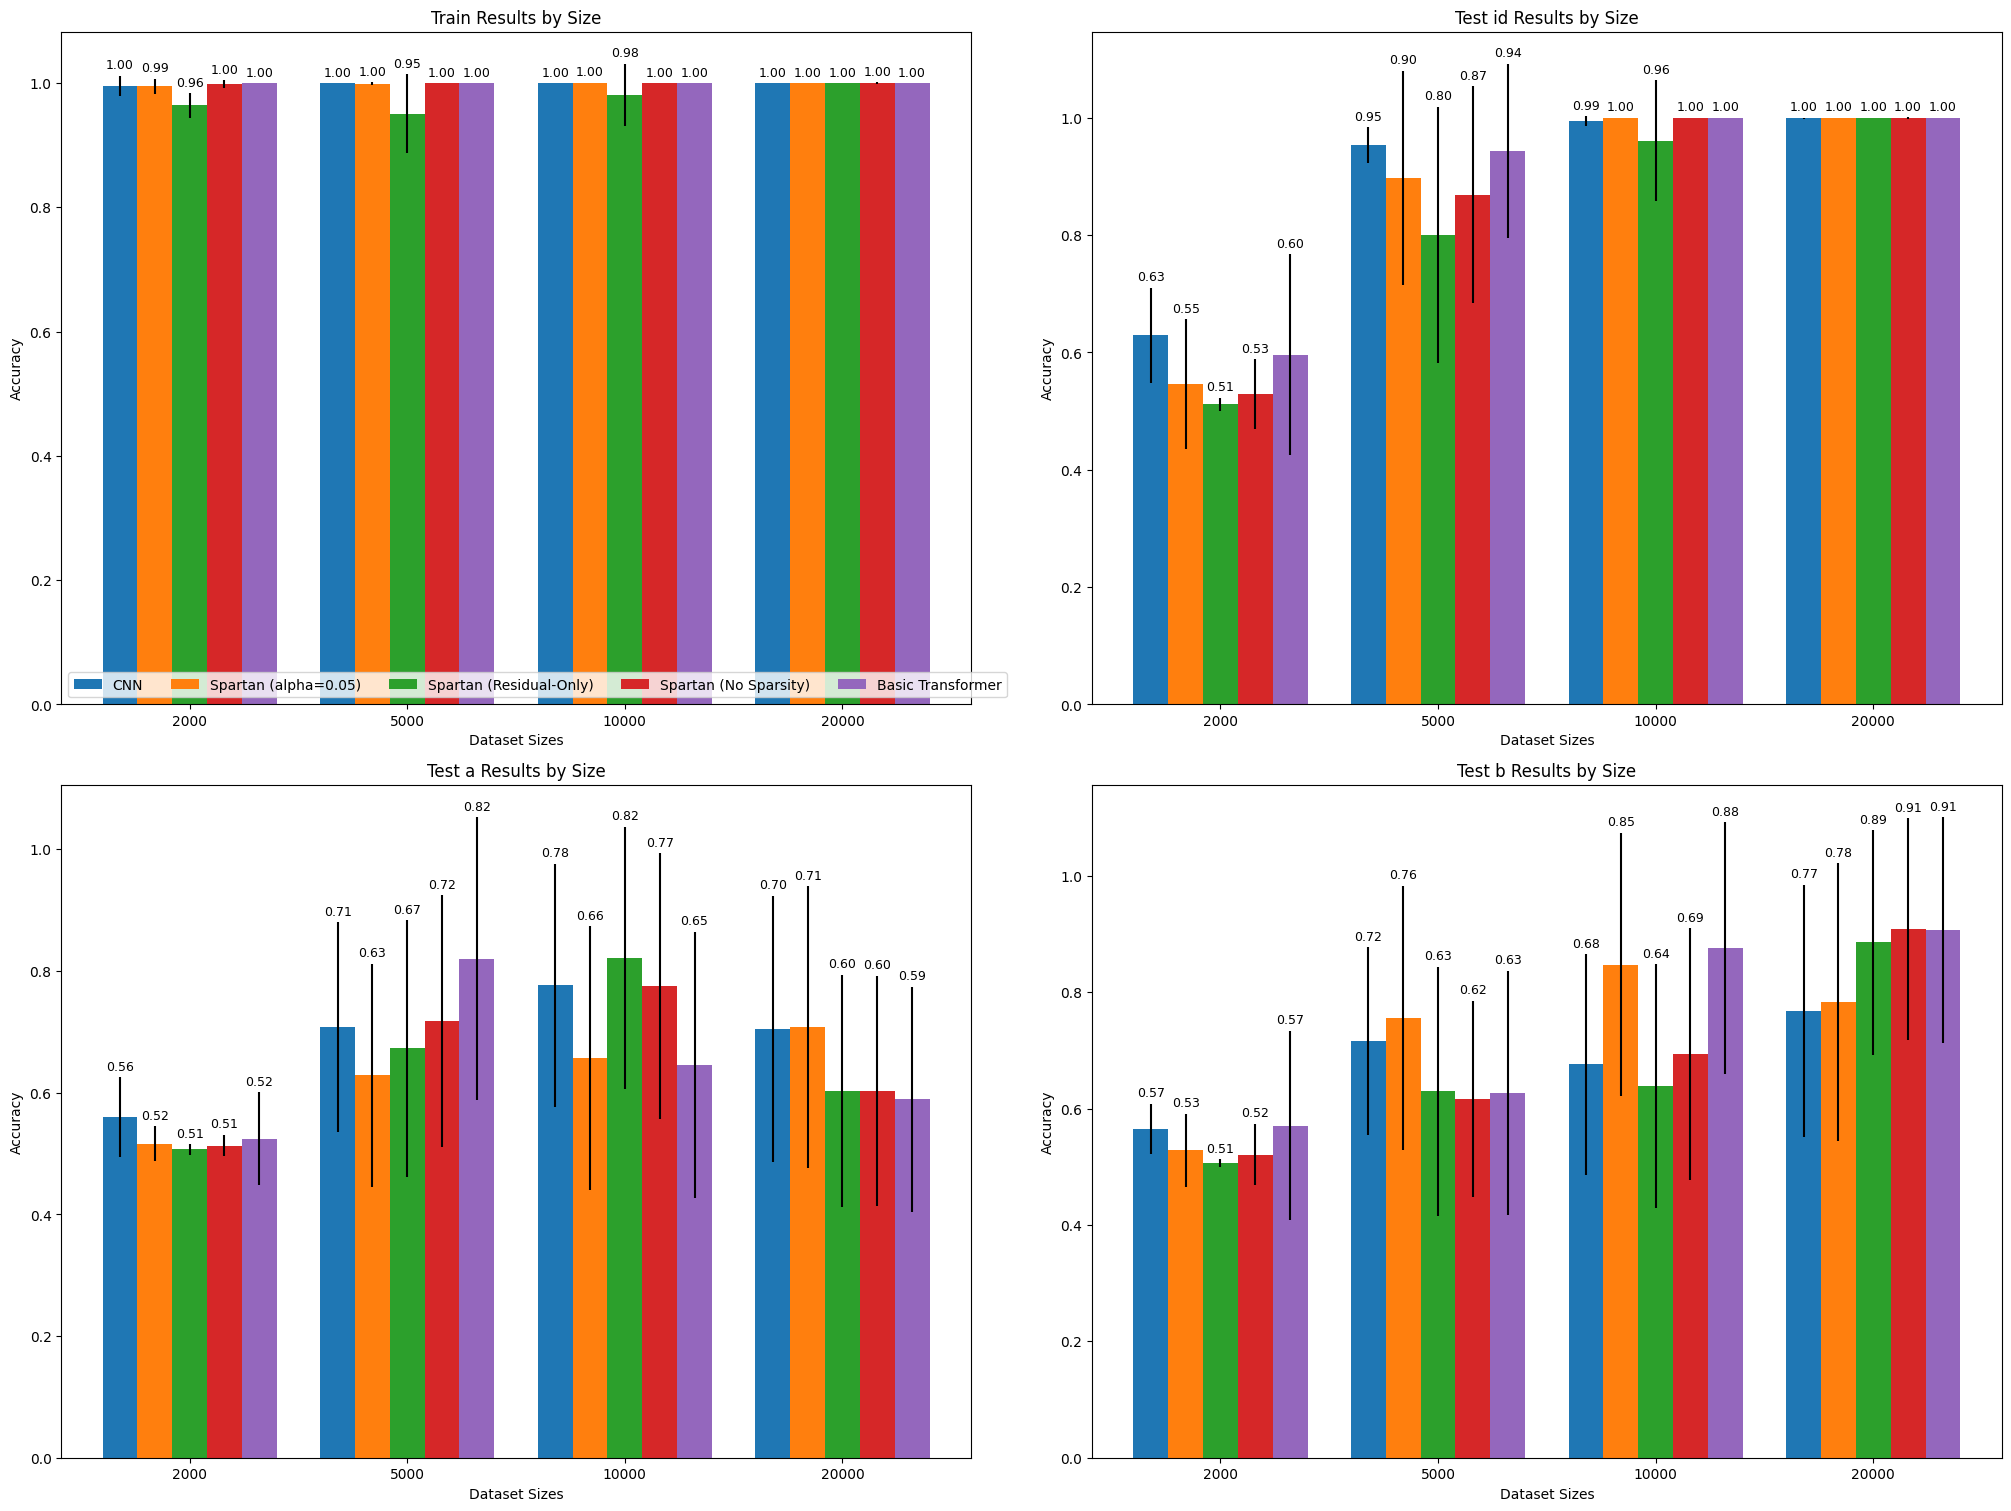

In [22]:
draw_chart_shapes(
    [{'model_name' : 'cnn_shapes', 'name' : 'CNN'}, 
     {'model_name' : 'spartan_shapes', 'name' : 'Spartan (alpha=0.05)',
      'alpha' : 0.05,
      'spartan' : True,
      'sparse' : True,
      }, 
      {'model_name' : 'spartan_zeros_shapes', 'name': 'Spartan (Residual-Only)', 
      'spartan' : True},
      {'model_name' : 'spartan_shapes', 'name': 'Spartan (No Sparsity)', 
      'spartan' : True},
      {'model_name' : 'trans_shapes', 'name': 'Basic Transformer'}
      ],
    grid=5
);

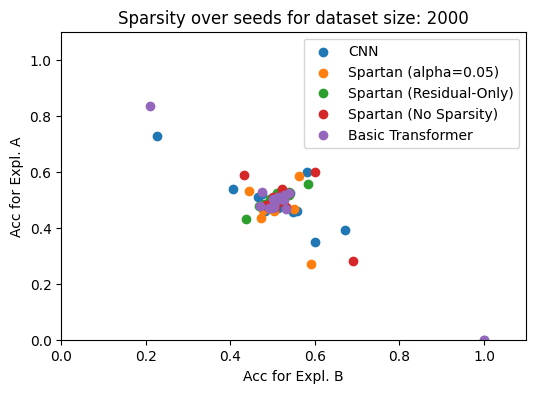

In [35]:
draw_2d_sparse(
    [{'model_name' : 'cnn_shapes', 'name' : 'CNN'}, 
     {'model_name' : 'spartan_shapes', 'name' : 'Spartan (alpha=0.05)',
      'alpha' : 0.05,
      'spartan' : True,
      'sparse' : True,
      }, 
      {'model_name' : 'spartan_zeros_shapes', 'name': 'Spartan (Residual-Only)', 
      'spartan' : True},
      {'model_name' : 'spartan_shapes', 'name': 'Spartan (No Sparsity)', 
      'spartan' : True},
      {'model_name' : 'trans_shapes', 'name': 'Basic Transformer'}
      ],method='acc', size=2000);

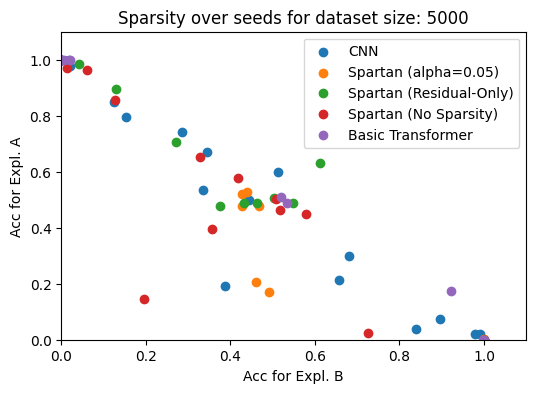

In [36]:
draw_2d_sparse(
    [{'model_name' : 'cnn_shapes', 'name' : 'CNN'}, 
     {'model_name' : 'spartan_shapes', 'name' : 'Spartan (alpha=0.05)',
      'alpha' : 0.05,
      'spartan' : True,
      'sparse' : True,
      }, 
      {'model_name' : 'spartan_zeros_shapes', 'name': 'Spartan (Residual-Only)', 
      'spartan' : True},
      {'model_name' : 'spartan_shapes', 'name': 'Spartan (No Sparsity)', 
      'spartan' : True},
      {'model_name' : 'trans_shapes', 'name': 'Basic Transformer'}
      ],method='acc', size=5000);

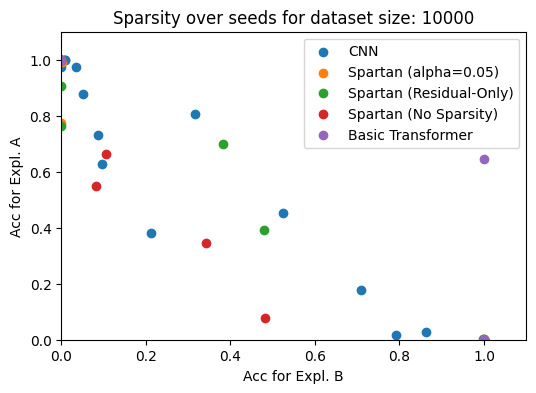

In [37]:
draw_2d_sparse(
    [{'model_name' : 'cnn_shapes', 'name' : 'CNN'}, 
     {'model_name' : 'spartan_shapes', 'name' : 'Spartan (alpha=0.05)',
      'alpha' : 0.05,
      'spartan' : True,
      'sparse' : True,
      }, 
      {'model_name' : 'spartan_zeros_shapes', 'name': 'Spartan (Residual-Only)', 
      'spartan' : True},
      {'model_name' : 'spartan_shapes', 'name': 'Spartan (No Sparsity)', 
      'spartan' : True},
      {'model_name' : 'trans_shapes', 'name': 'Basic Transformer'}
      ],method='acc', size=10000);

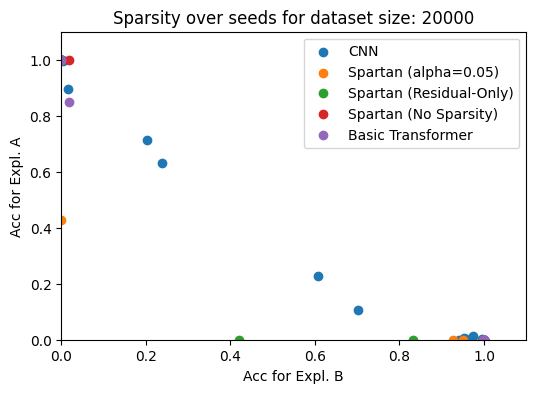

In [38]:
draw_2d_sparse(
    [{'model_name' : 'cnn_shapes', 'name' : 'CNN'}, 
     {'model_name' : 'spartan_shapes', 'name' : 'Spartan (alpha=0.05)',
      'alpha' : 0.05,
      'spartan' : True,
      'sparse' : True,
      }, 
      {'model_name' : 'spartan_zeros_shapes', 'name': 'Spartan (Residual-Only)', 
      'spartan' : True},
      {'model_name' : 'spartan_shapes', 'name': 'Spartan (No Sparsity)', 
      'spartan' : True},
      {'model_name' : 'trans_shapes', 'name': 'Basic Transformer'}
      ],method='acc', size=20000);

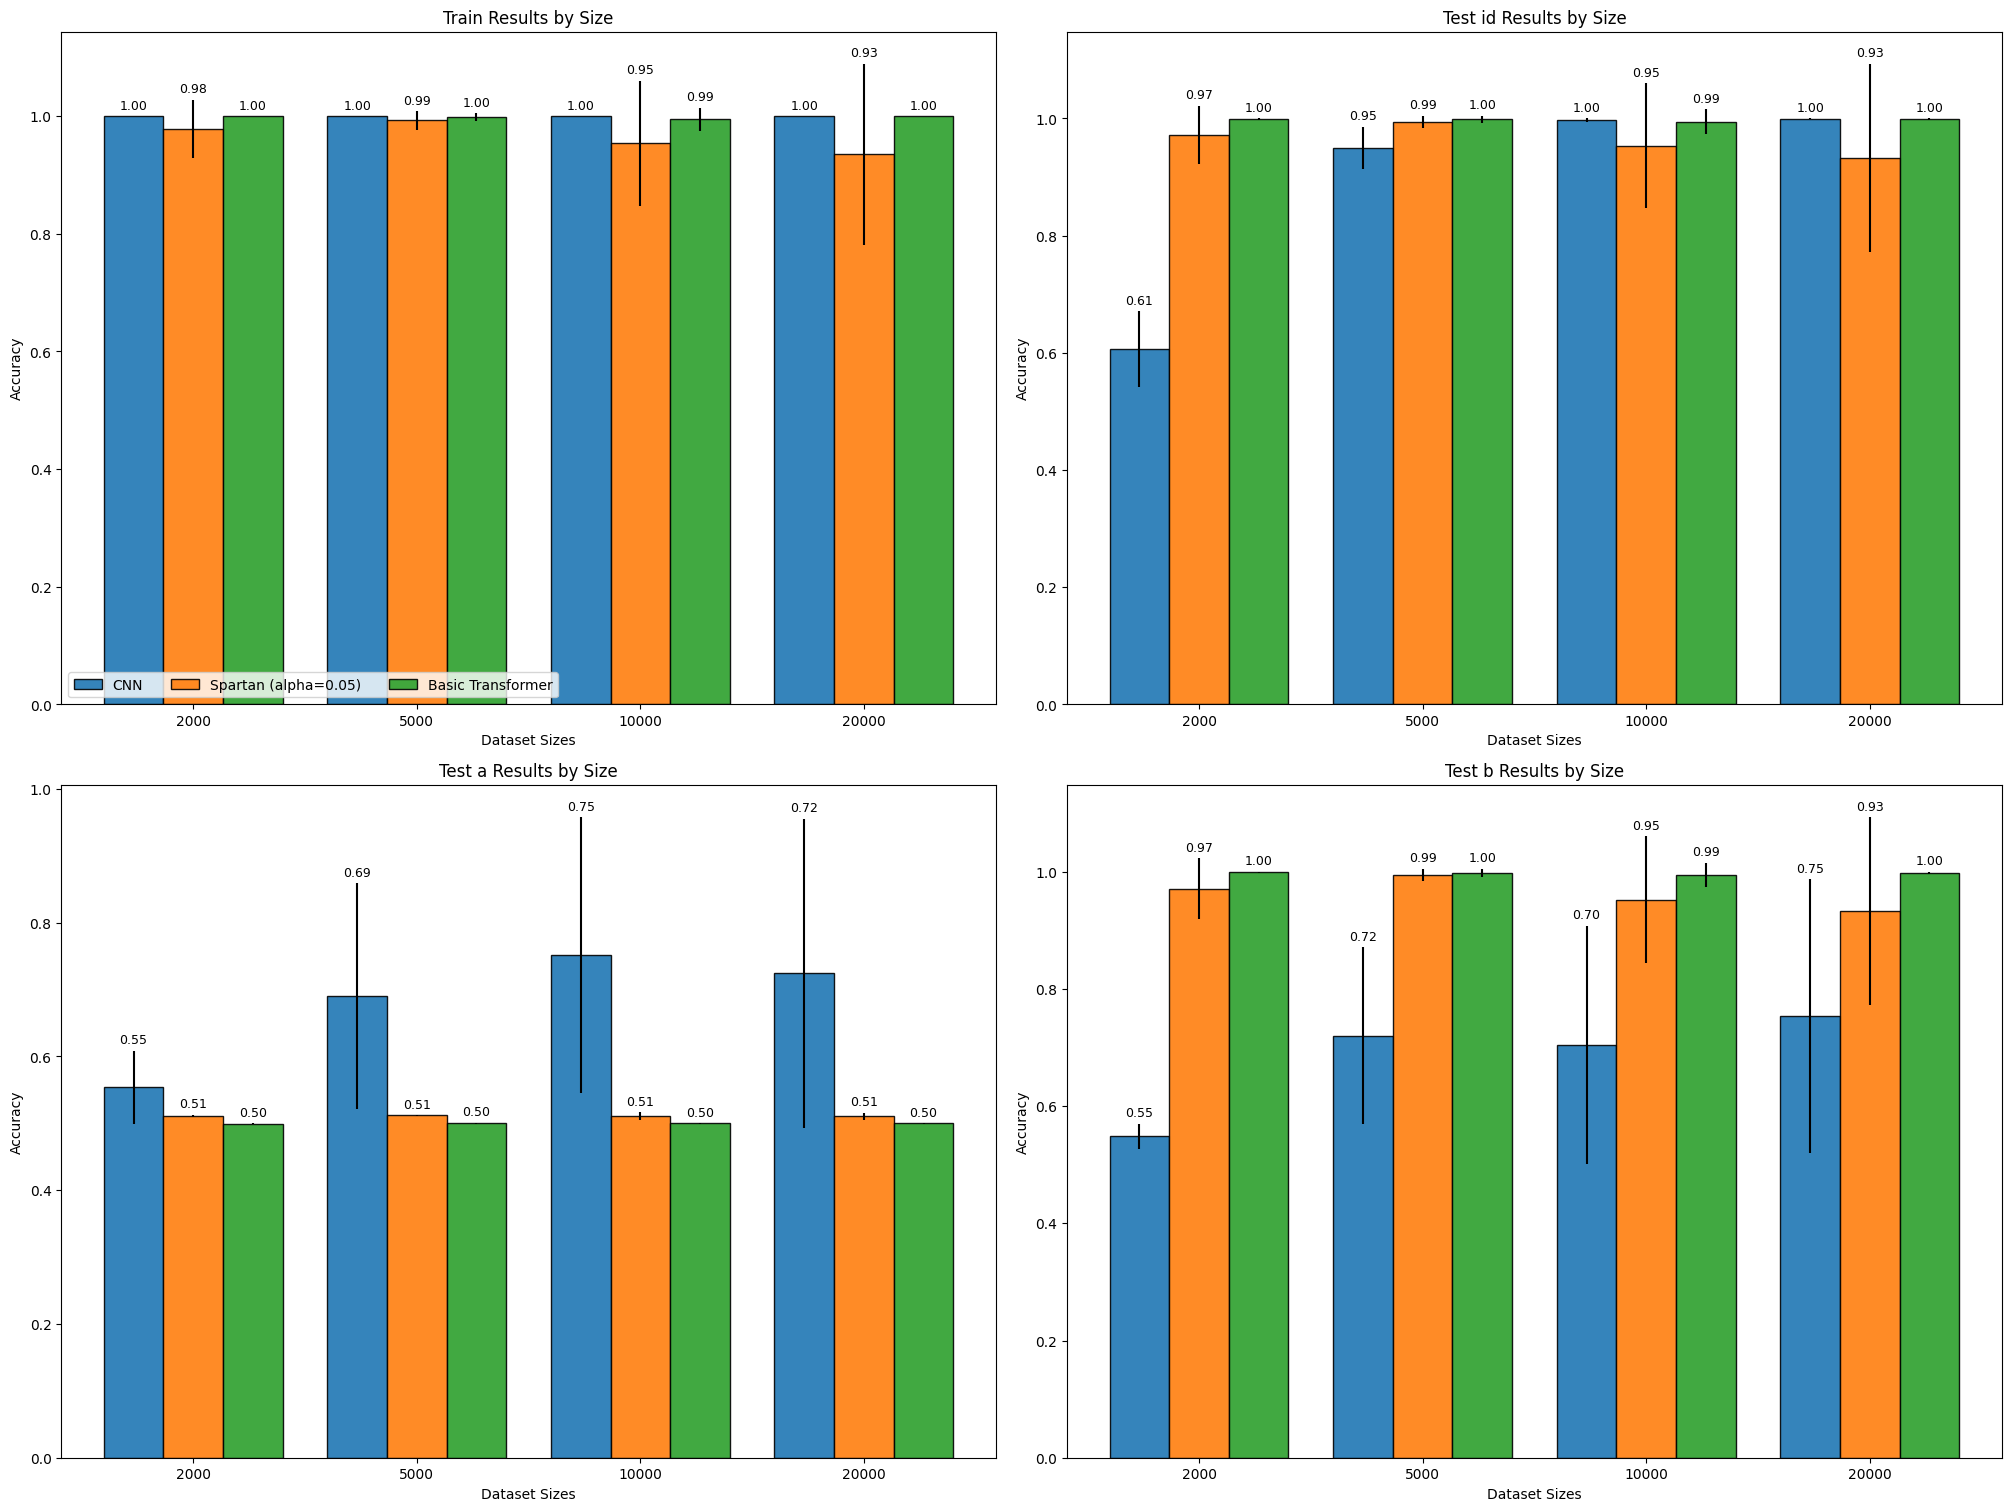

In [13]:
draw_chart_shapes(
    [{'model_name' : 'cnn_shapes', 'name' : 'CNN'}, 
      {'model_name' : 'spartan_shapes', 'name': 'Spartan (alpha=0.05)', 
      'spartan' : True},
      {'model_name' : 'trans_shapes', 'name': 'Basic Transformer'}
      ],
    grid=5
);

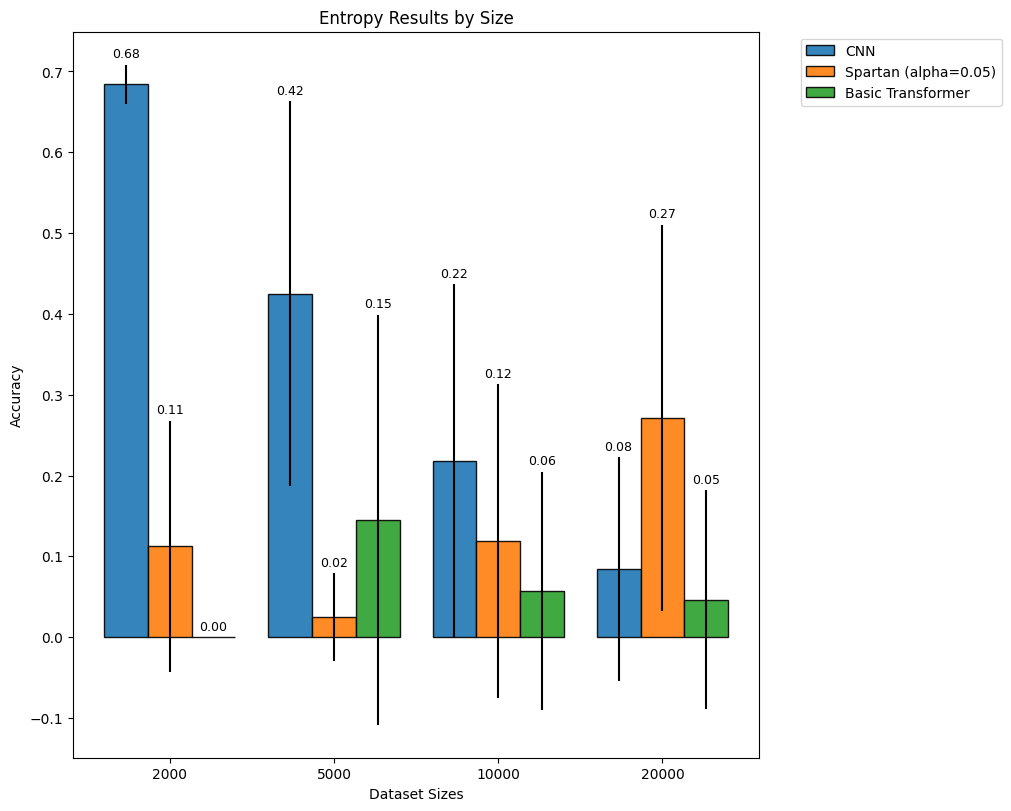

In [22]:
draw_entropy(
    [{'model_name' : 'cnn_shapes', 'name' : 'CNN'}, 
      {'model_name' : 'spartan_shapes', 'name': 'Spartan (alpha=0.05)', 
      'spartan' : True, },
      {'model_name' : 'trans_shapes', 'name': 'Basic Transformer'}
      ],
      grid=5, 
      sizes=[2000, 5000, 10000, 20000]
);

In [21]:
def draw_entropy_box(
        configs,
        grid=5, 
        sizes=list([2000, 5000, 10000, 20000]),
        figsize=(10, 8),
        tolerance=1e-5
    ):
    
    full_data = {}
    fig, ax = plt.subplots(1, 1, layout='constrained', figsize=figsize)

    for config in configs:
        full_data[config['name']] = {}
        for size in sizes:
            full_data[config['name']][size] = get_anti(config, size, grid)
        
    model_names = list(full_data.keys())
    num_models = len(model_names)
    
    total_group_width = 0.8 
    bar_width = total_group_width / num_models
    x = np.arange(len(sizes)) 

    df = {'Dataset' : [], 'Model' : [], 'Entropy' : []}
    
    # compute antis 
    def compute_ent(data):
        ent_res = []
        for seed in data.keys():
            acc_a = data[seed]["anti_results"][f"acc_a"]
            acc_b = data[seed]["anti_results"][f"acc_b"]

            tot = acc_a + acc_b
            if tot < tolerance:
                continue
            norm_a = acc_a / tot
            norm_b = acc_b / tot
            probs = np.array([norm_a, norm_b], dtype=float)
            nonzero_probs = probs[probs > 0]
            ent = -np.sum(nonzero_probs * np.log(nonzero_probs))
            ent_res.append(ent)

        return ent_res

    for model in model_names:
        for size in sizes:
            ent_res = compute_ent(full_data[model][size])
            for ent in ent_res:
                df['Dataset'].append(size)
                df['Model'].append(model)
                df['Entropy'].append(ent)
    
    df = pd.DataFrame.from_dict(df)
    sns.boxplot(x='Dataset', y='Entropy', hue='Model', ax=ax, gap=0.1, data=df)
    ax.grid()
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        
    return fig, ax

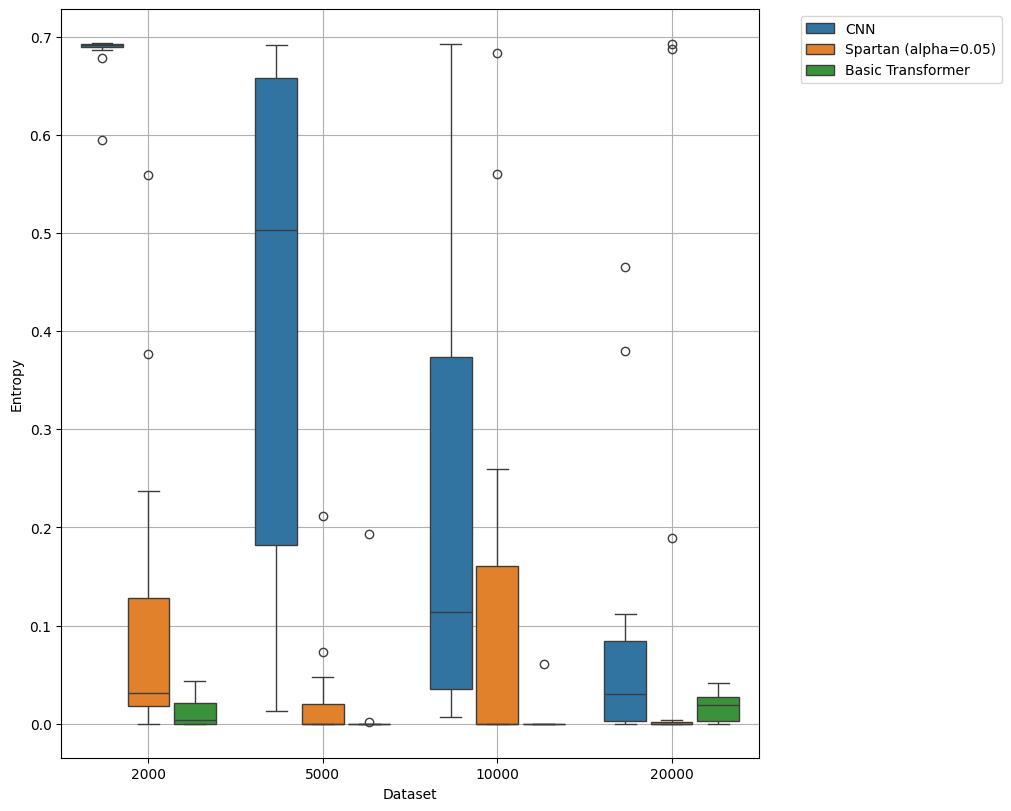

In [16]:
draw_entropy_box(
    [{'model_name' : 'cnn_shapes', 'name' : 'CNN'}, 
      {'model_name' : 'spartan_shapes', 'name': 'Spartan (alpha=0.05)', 
      'spartan' : True},
      {'model_name' : 'trans_shapes', 'name': 'Basic Transformer'}
      ],
      grid=5, 
      sizes=[2000, 5000, 10000, 20000]
);

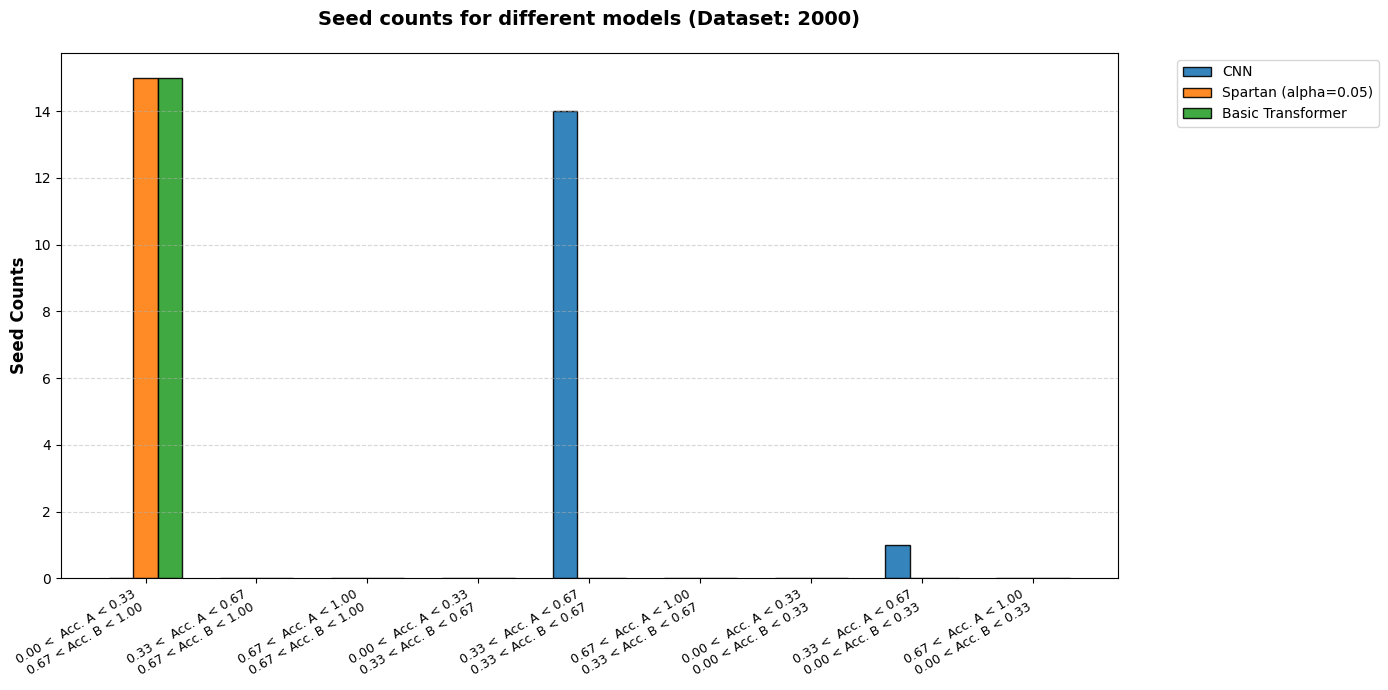

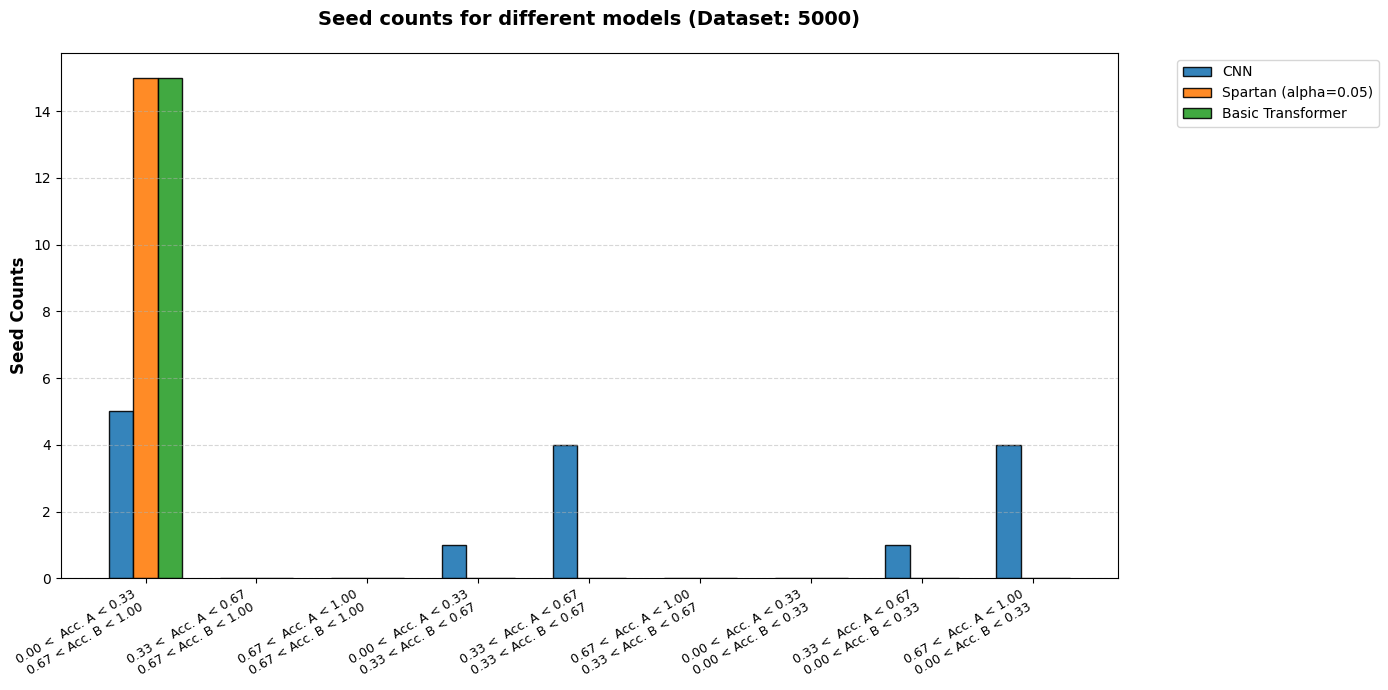

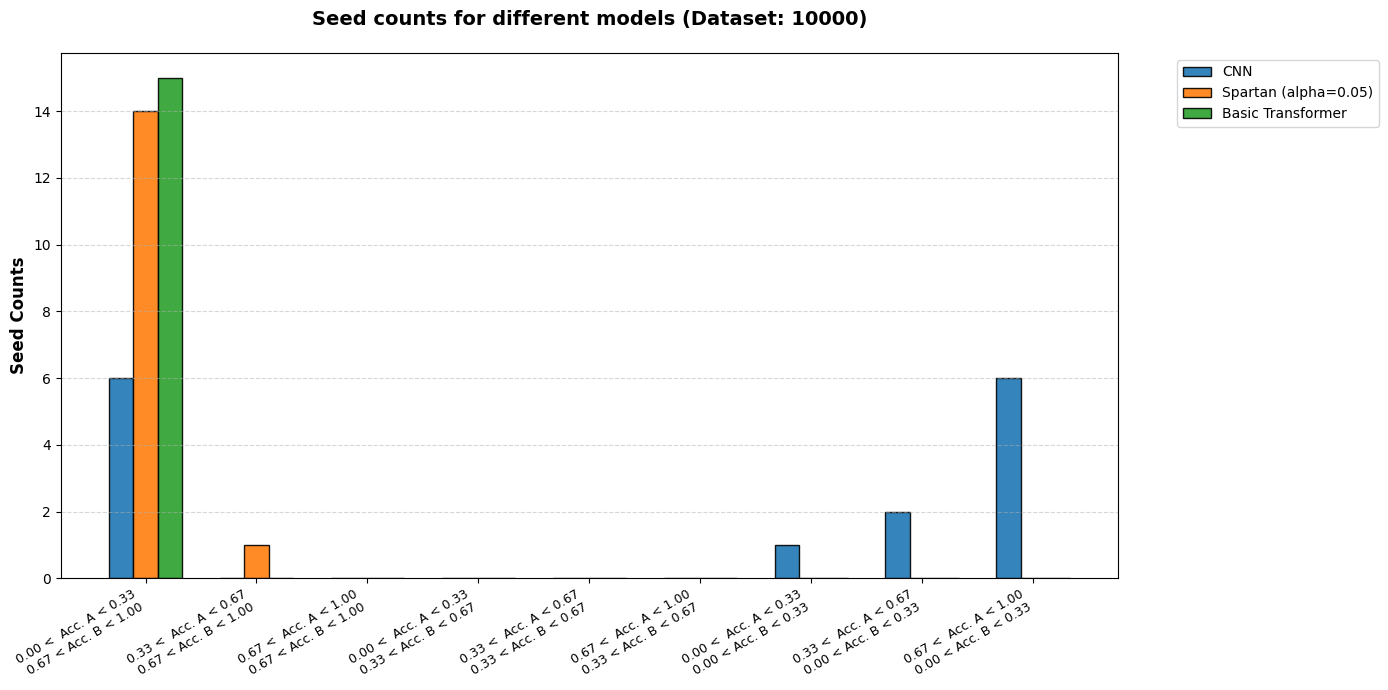

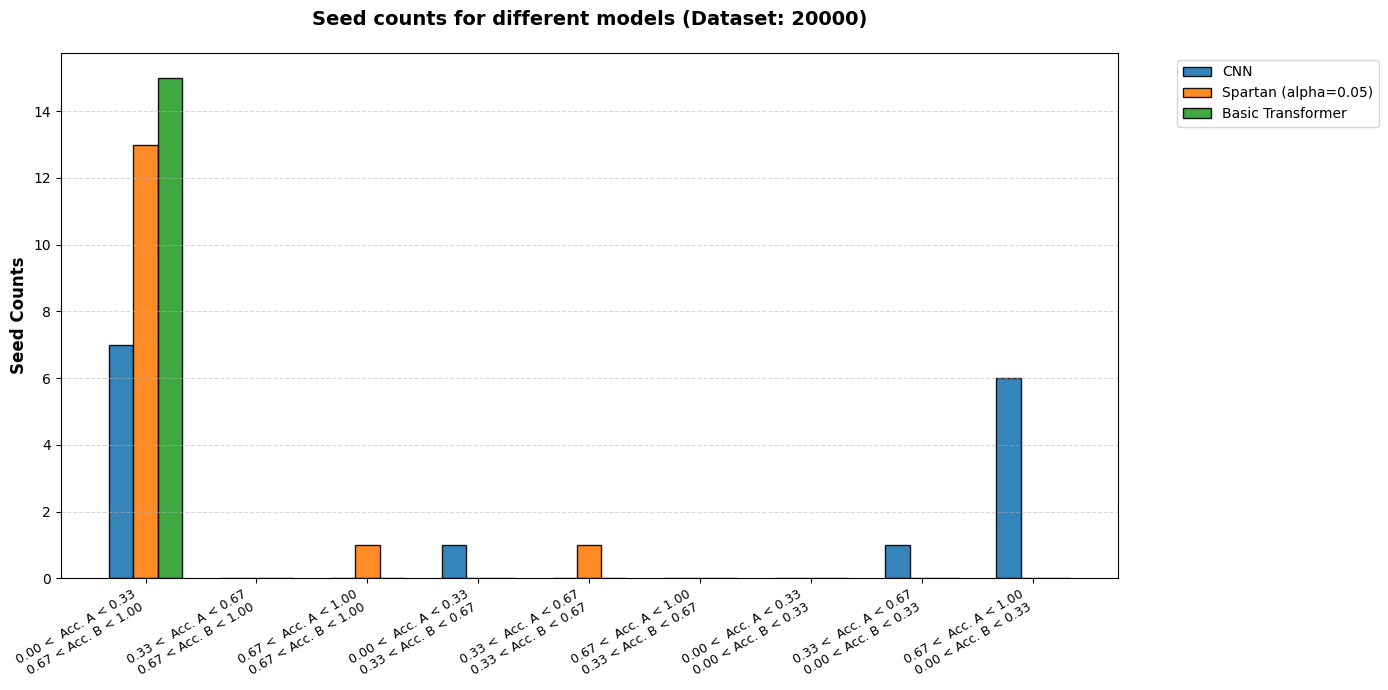

In [17]:
draw_hist_sparse(
    [{'model_name' : 'cnn_shapes', 'name' : 'CNN'}, 
      {'model_name' : 'spartan_shapes', 'name': 'Spartan (alpha=0.05)', 
      'spartan' : True},
      {'model_name' : 'trans_shapes', 'name': 'Basic Transformer'}
      ],
      grid=5,
      size=2000,
);

draw_hist_sparse(
    [{'model_name' : 'cnn_shapes', 'name' : 'CNN'}, 
      {'model_name' : 'spartan_shapes', 'name': 'Spartan (alpha=0.05)', 
      'spartan' : True},
      {'model_name' : 'trans_shapes', 'name': 'Basic Transformer'}
      ],
      grid=5,
      size=5000,
);

draw_hist_sparse(
    [{'model_name' : 'cnn_shapes', 'name' : 'CNN'}, 
      {'model_name' : 'spartan_shapes', 'name': 'Spartan (alpha=0.05)', 
      'spartan' : True},
      {'model_name' : 'trans_shapes', 'name': 'Basic Transformer'}
      ],
      grid=5,
      size=10000,
);

draw_hist_sparse(
    [{'model_name' : 'cnn_shapes', 'name' : 'CNN'}, 
      {'model_name' : 'spartan_shapes', 'name': 'Spartan (alpha=0.05)', 
      'spartan' : True},
      {'model_name' : 'trans_shapes', 'name': 'Basic Transformer'}
      ],
      grid=5,
      size=20000,
);

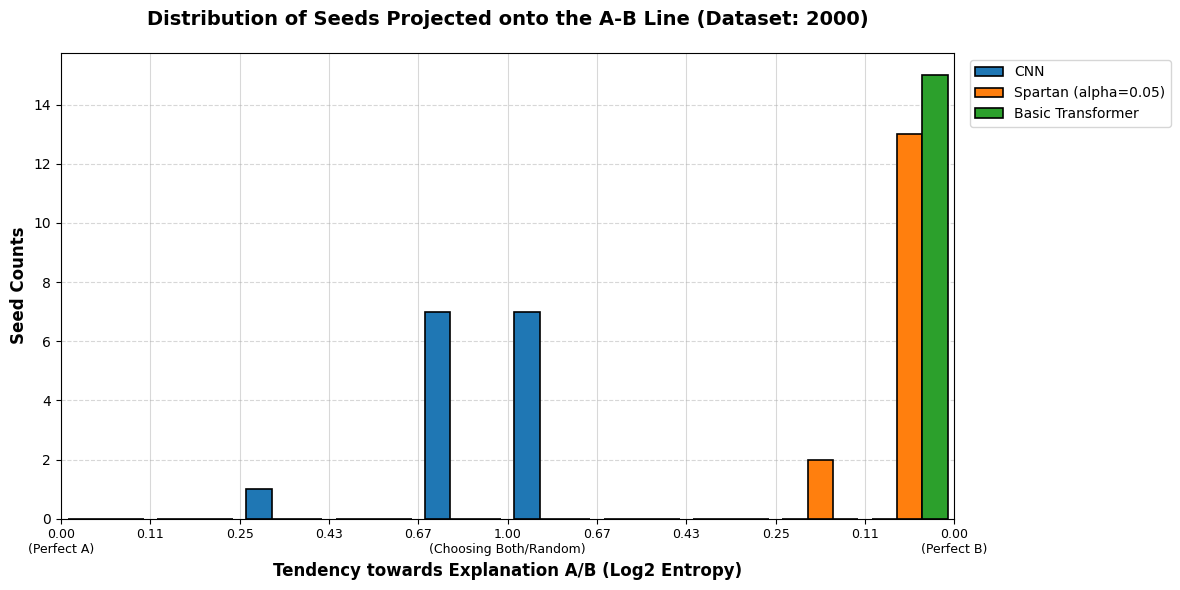

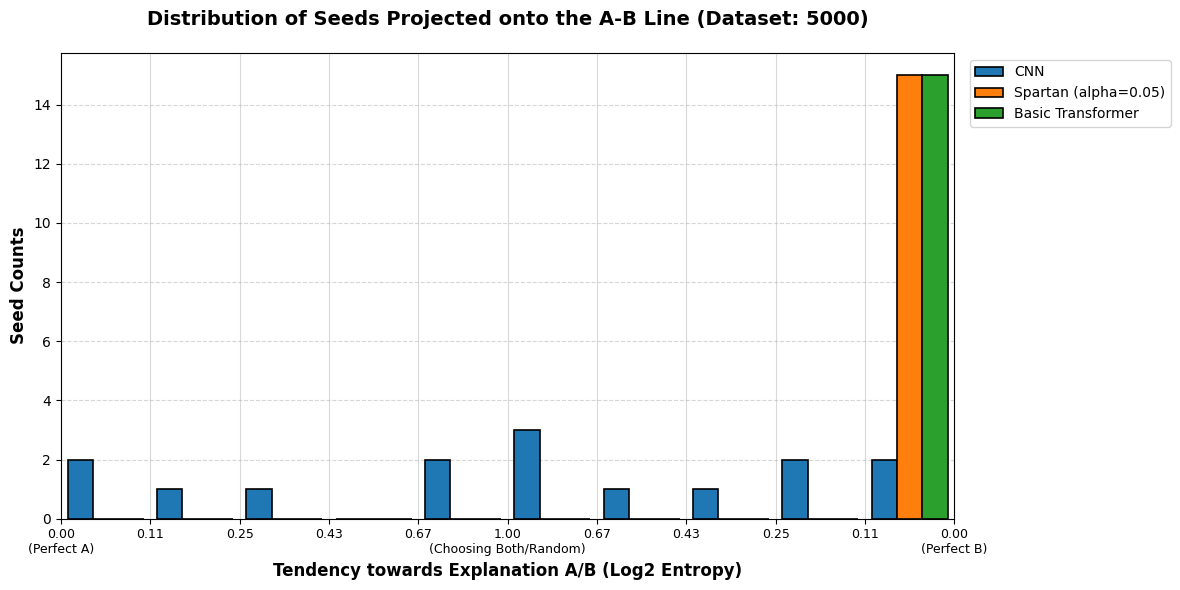

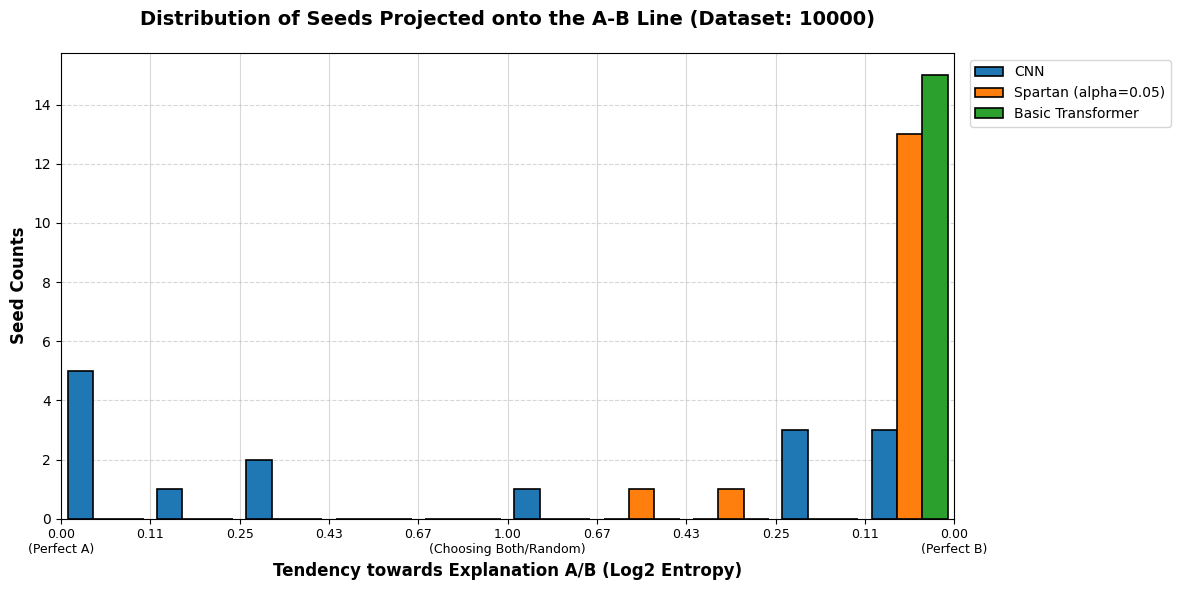

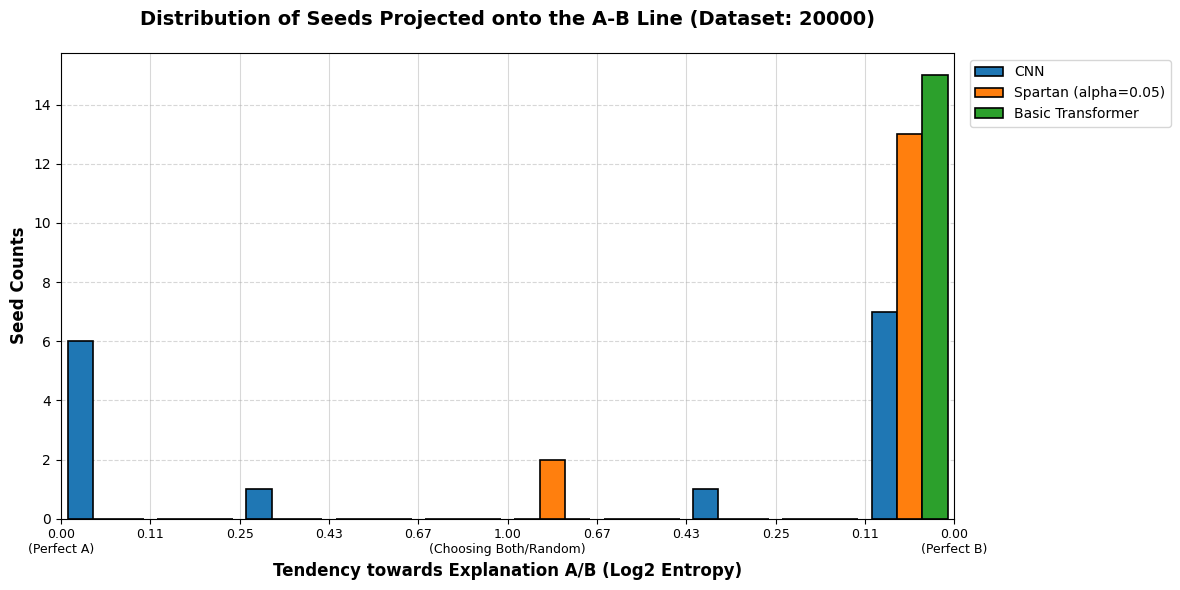

In [18]:
draw_proj_hist(
    [{'model_name' : 'cnn_shapes', 'name' : 'CNN'}, 
      {'model_name' : 'spartan_shapes', 'name': 'Spartan (alpha=0.05)', 
      'spartan' : True},
      {'model_name' : 'trans_shapes', 'name': 'Basic Transformer'}
      ],
      grid=5,
      size=2000,
);
draw_proj_hist(
    [{'model_name' : 'cnn_shapes', 'name' : 'CNN'}, 
      {'model_name' : 'spartan_shapes', 'name': 'Spartan (alpha=0.05)', 
      'spartan' : True},
      {'model_name' : 'trans_shapes', 'name': 'Basic Transformer'}
      ],
      grid=5,
      size=5000,
);
draw_proj_hist(
    [{'model_name' : 'cnn_shapes', 'name' : 'CNN'}, 
      {'model_name' : 'spartan_shapes', 'name': 'Spartan (alpha=0.05)', 
      'spartan' : True},
      {'model_name' : 'trans_shapes', 'name': 'Basic Transformer'}
      ],
      grid=5,
      size=10000,
);
draw_proj_hist(
    [{'model_name' : 'cnn_shapes', 'name' : 'CNN'}, 
      {'model_name' : 'spartan_shapes', 'name': 'Spartan (alpha=0.05)', 
      'spartan' : True},
      {'model_name' : 'trans_shapes', 'name': 'Basic Transformer'}
      ],
      grid=5,
      size=20000,
);

### Corrupted examples

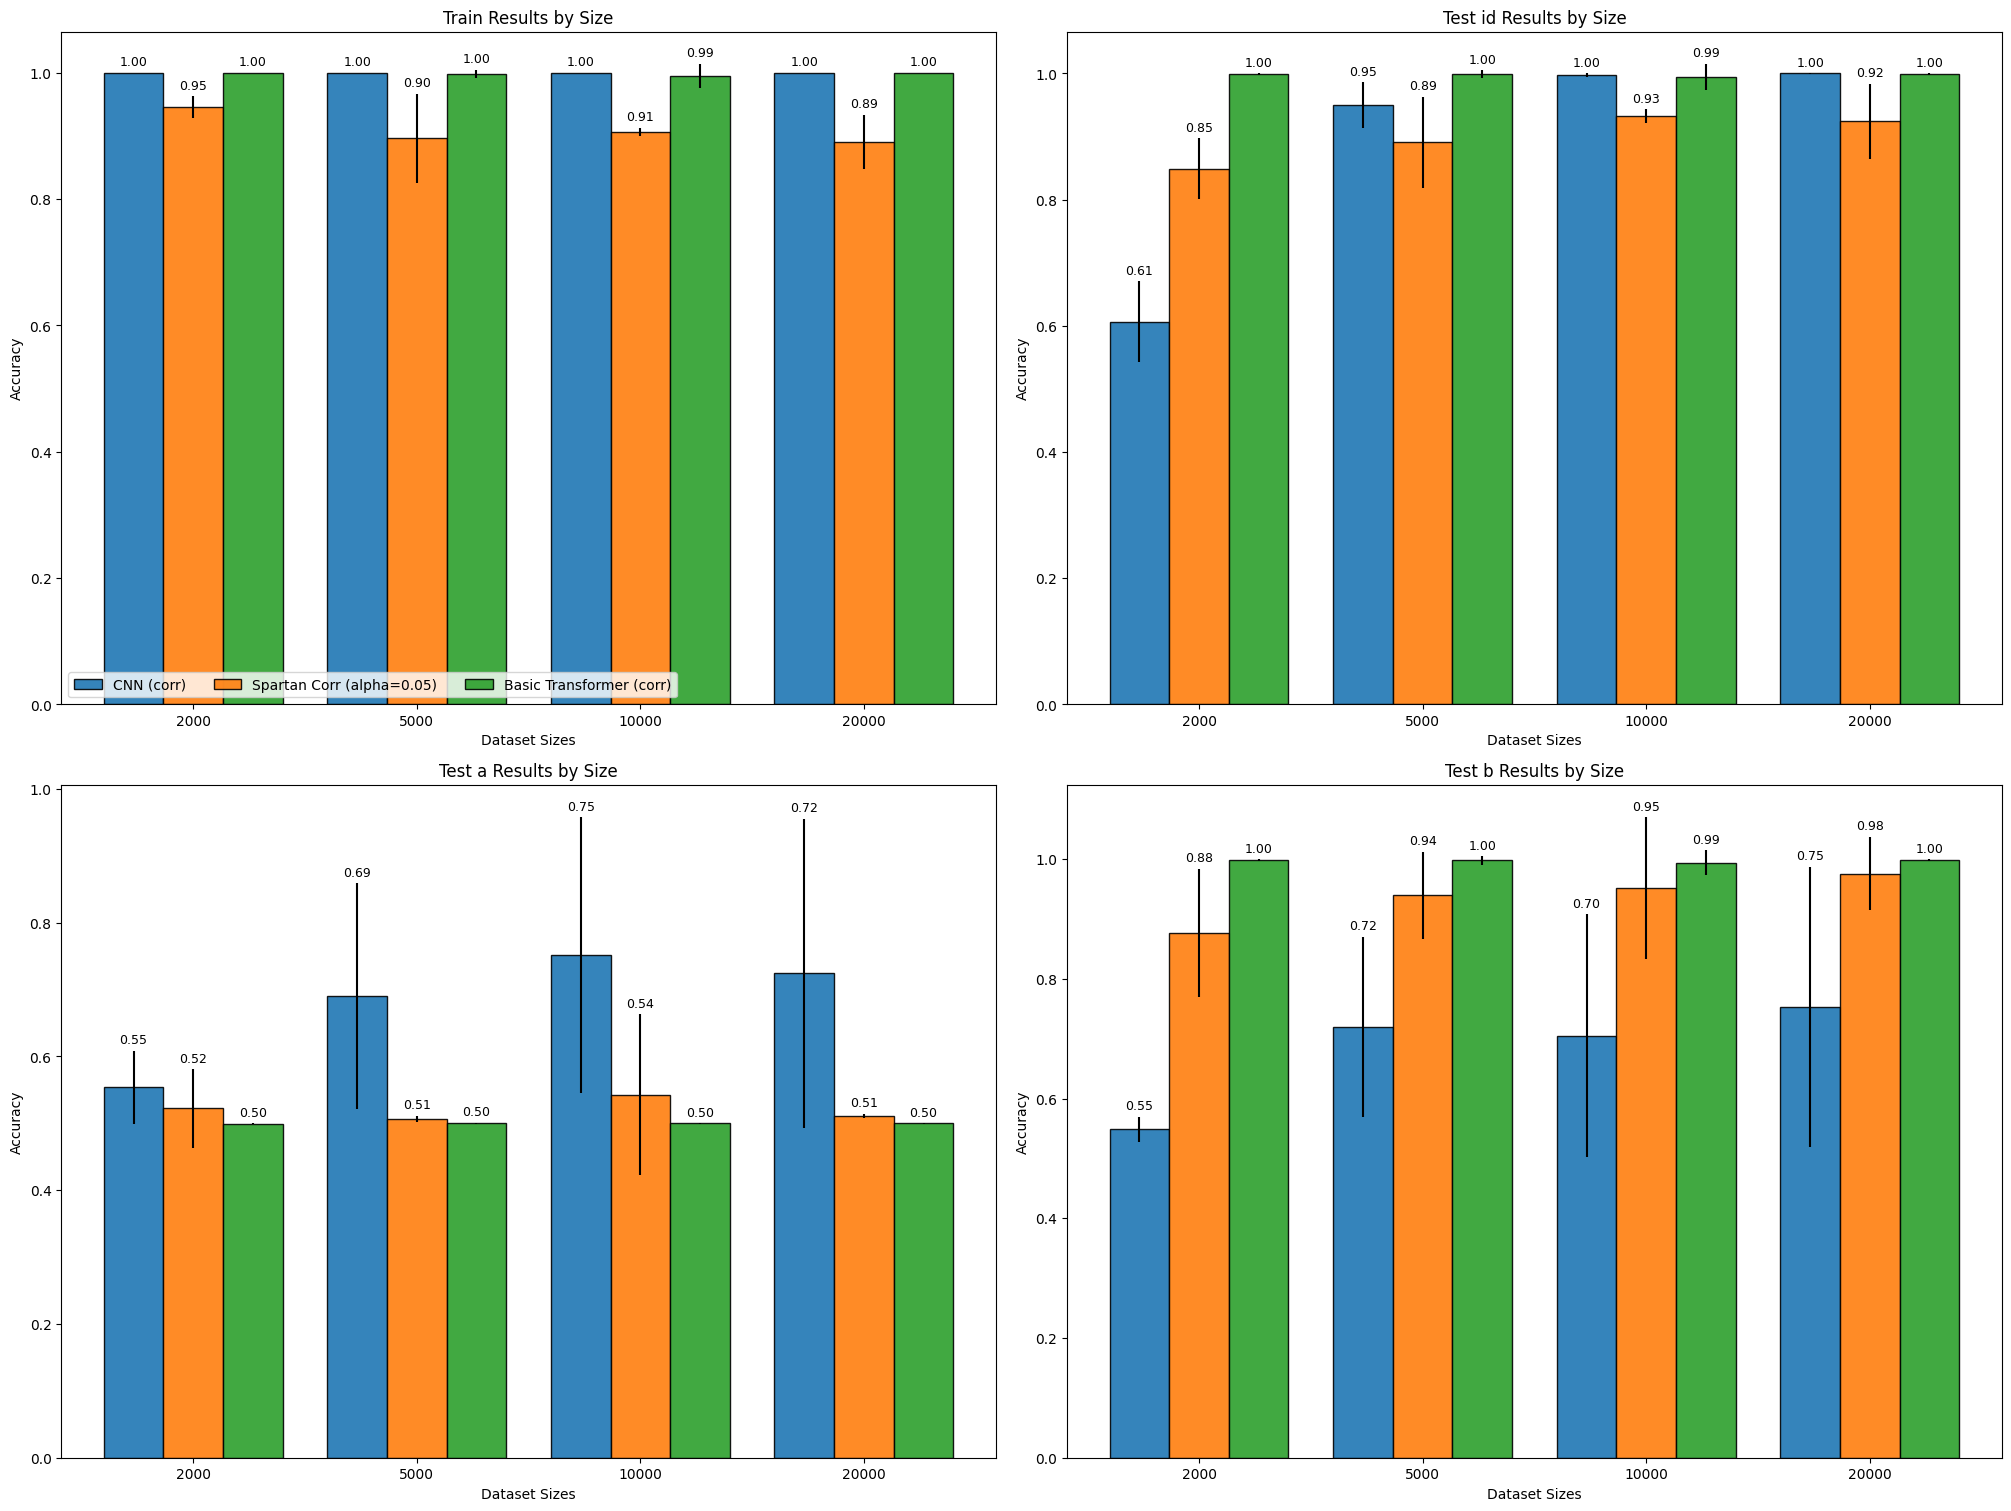

In [22]:
draw_chart_shapes(
    [{'model_name' : 'cnn_shapes', 'name' : 'CNN (corr)', 'corr' : True}, 
      {'model_name' : 'spartan_shapes', 'name': 'Spartan Corr (alpha=0.05)', 
      'spartan' : True, 'corr' : True},
      {'model_name' : 'trans_shapes', 'name': 'Basic Transformer (corr)', 'corr' : True}
      ],
    grid=5
);

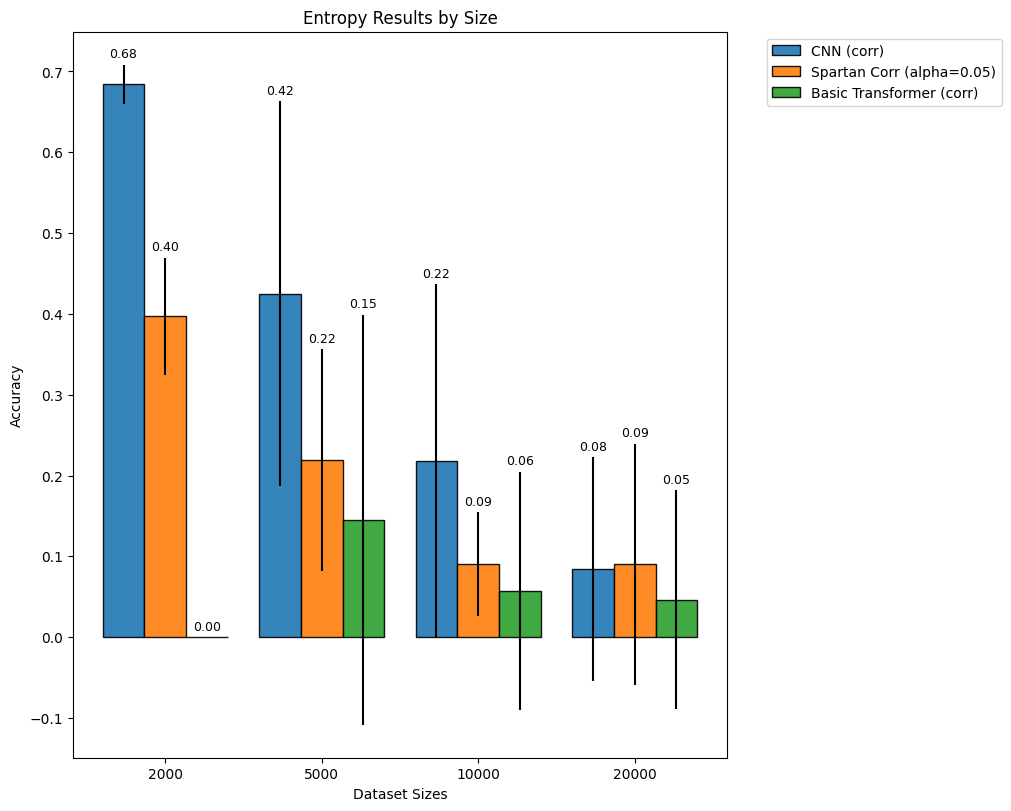

In [17]:
draw_entropy(
    [{'model_name' : 'cnn_shapes', 'name' : 'CNN (corr)', 'corr' : True}, 
      {'model_name' : 'spartan_shapes', 'name': 'Spartan Corr (alpha=0.05)', 
      'spartan' : True, 'corr' : True},
      {'model_name' : 'trans_shapes', 'name': 'Basic Transformer (corr)', 'corr' : True}
      ],
      grid=5, 
      sizes=[2000, 5000, 10000, 20000]
);

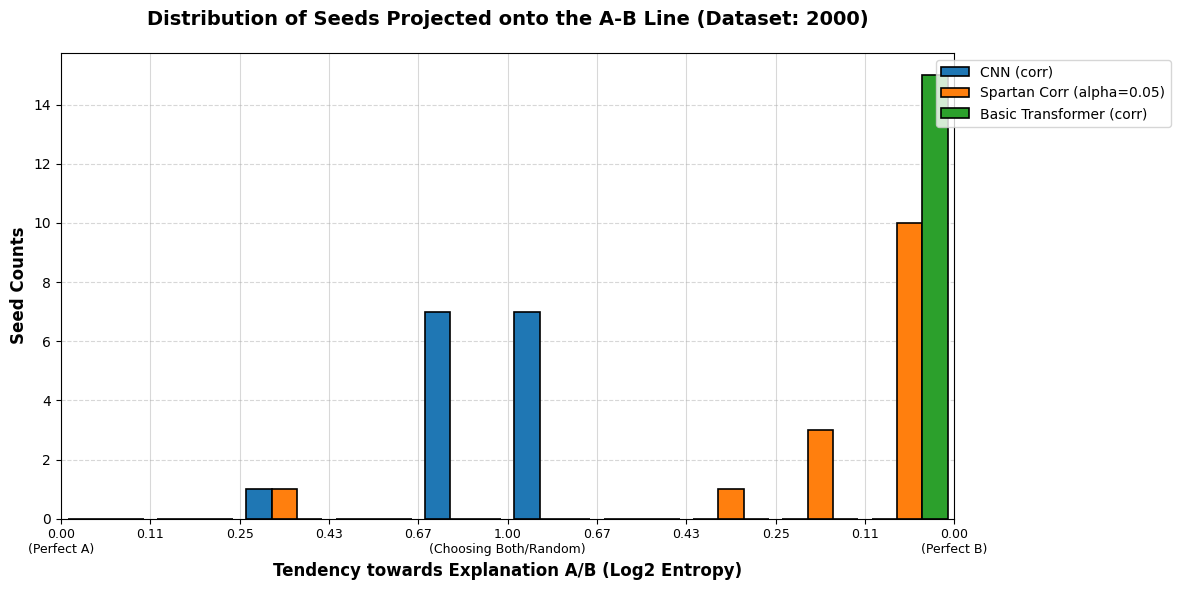

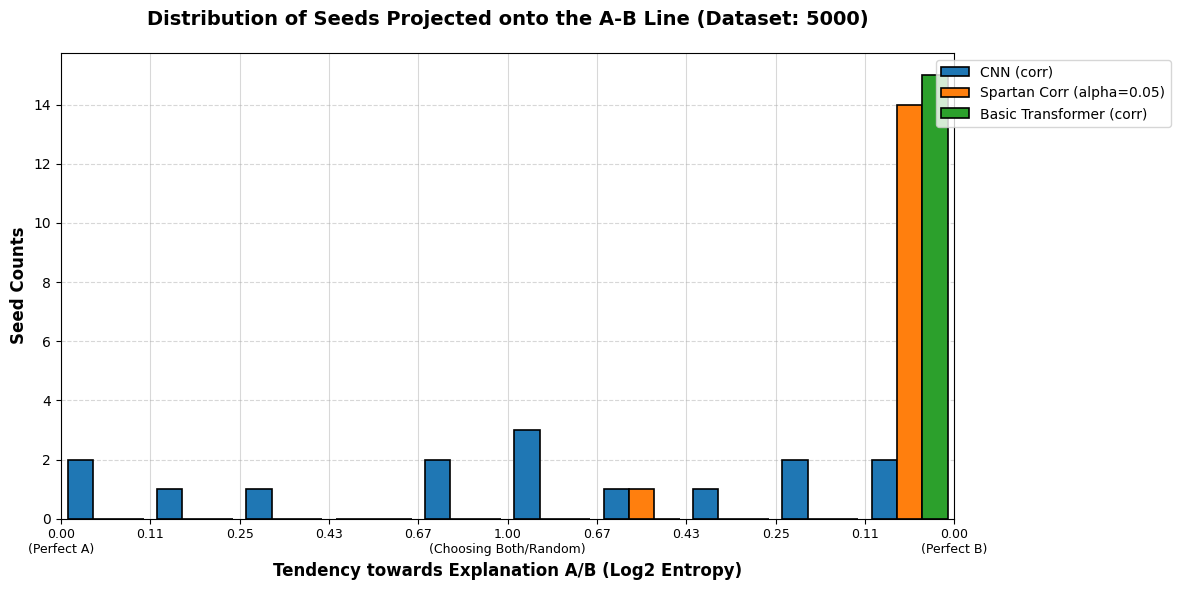

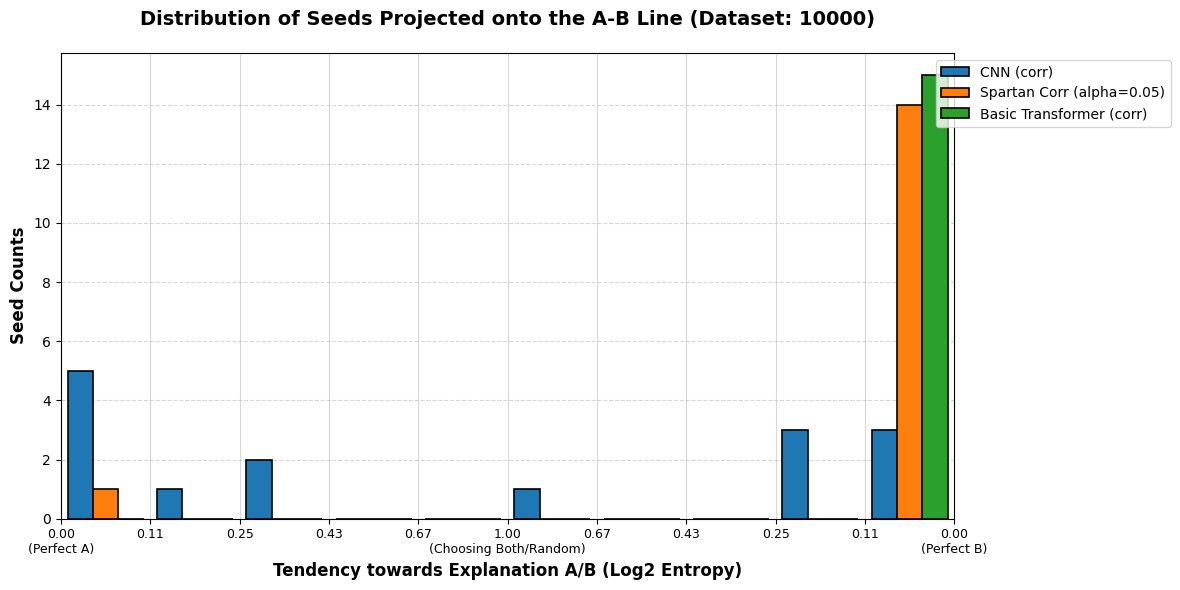

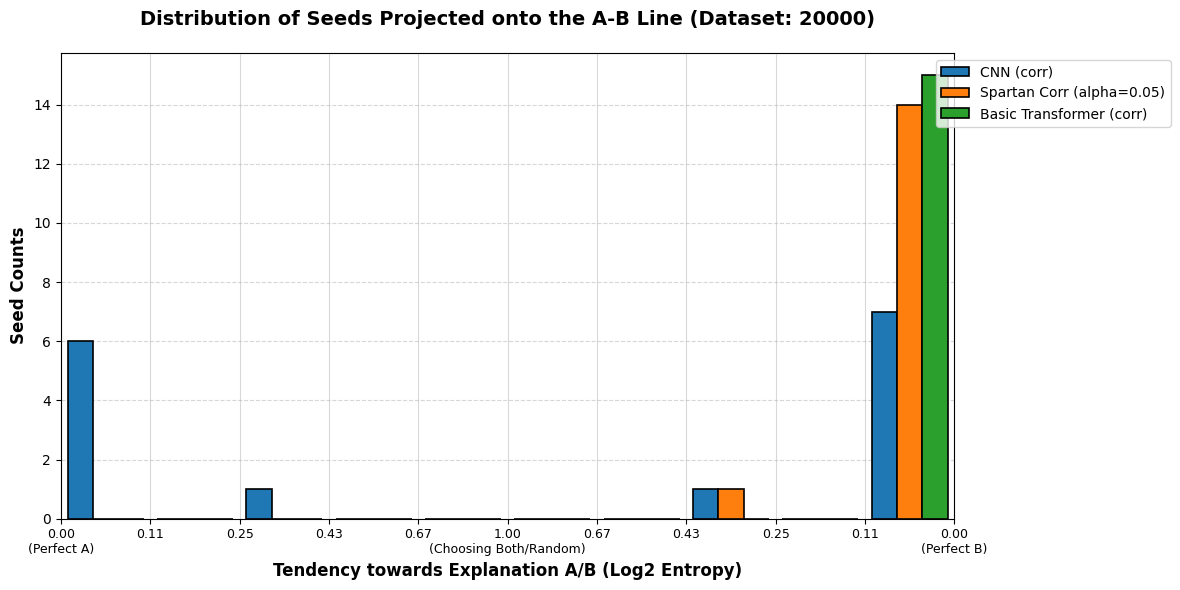

In [26]:
draw_proj_hist(
    [{'model_name' : 'cnn_shapes', 'name' : 'CNN (corr)', 'corr' : True}, 
      {'model_name' : 'spartan_shapes', 'name': 'Spartan Corr (alpha=0.05)', 
      'spartan' : True, 'corr' : True},
      {'model_name' : 'trans_shapes', 'name': 'Basic Transformer (corr)', 'corr' : True}
      ],
      grid=5,
      size=2000,
);
draw_proj_hist(
    [{'model_name' : 'cnn_shapes', 'name' : 'CNN (corr)', 'corr' : True}, 
      {'model_name' : 'spartan_shapes', 'name': 'Spartan Corr (alpha=0.05)', 
      'spartan' : True, 'corr' : True},
      {'model_name' : 'trans_shapes', 'name': 'Basic Transformer (corr)', 'corr' : True}
      ],
      grid=5,
      size=5000,
);
draw_proj_hist(
    [{'model_name' : 'cnn_shapes', 'name' : 'CNN (corr)', 'corr' : True}, 
      {'model_name' : 'spartan_shapes', 'name': 'Spartan Corr (alpha=0.05)', 
      'spartan' : True, 'corr' : True},
      {'model_name' : 'trans_shapes', 'name': 'Basic Transformer (corr)', 'corr' : True}
      ],
      grid=5,
      size=10000,
);
draw_proj_hist(
    [{'model_name' : 'cnn_shapes', 'name' : 'CNN (corr)', 'corr' : True}, 
      {'model_name' : 'spartan_shapes', 'name': 'Spartan Corr (alpha=0.05)', 
      'spartan' : True, 'corr' : True},
      {'model_name' : 'trans_shapes', 'name': 'Basic Transformer (corr)', 'corr' : True}
      ],
      grid=5,
      size=20000,
);

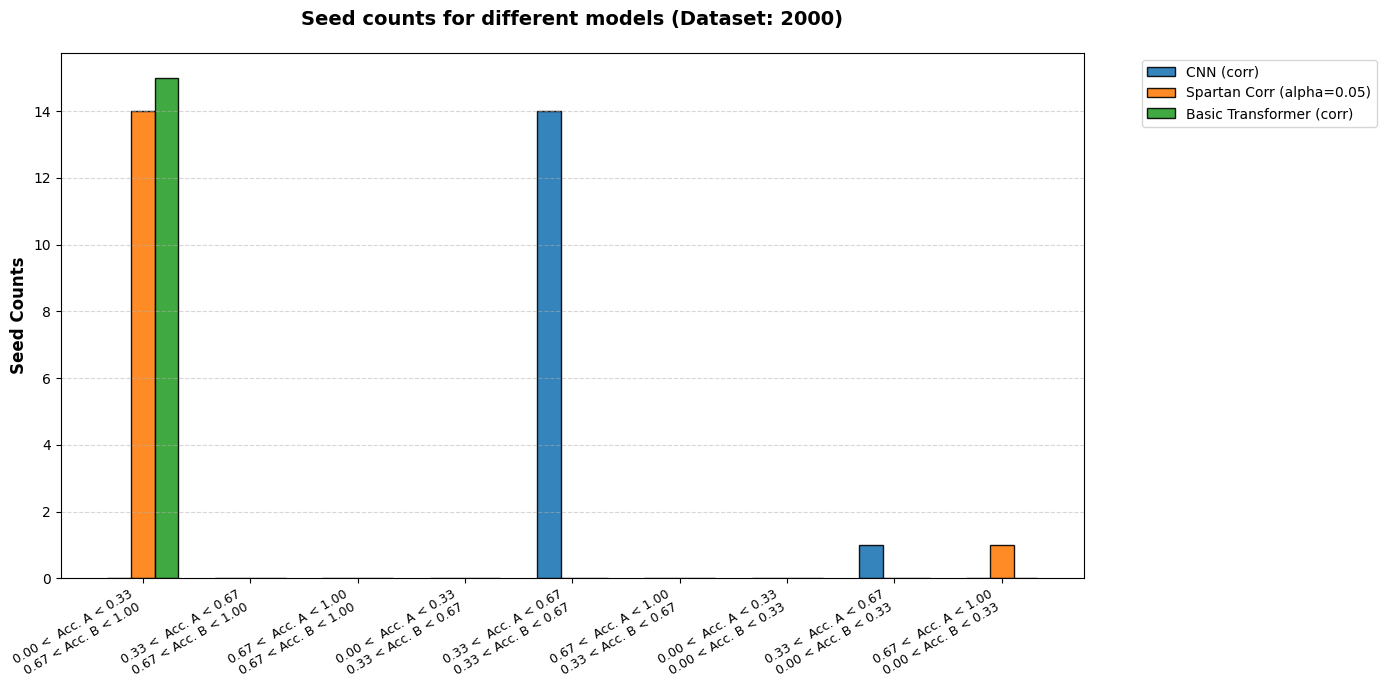

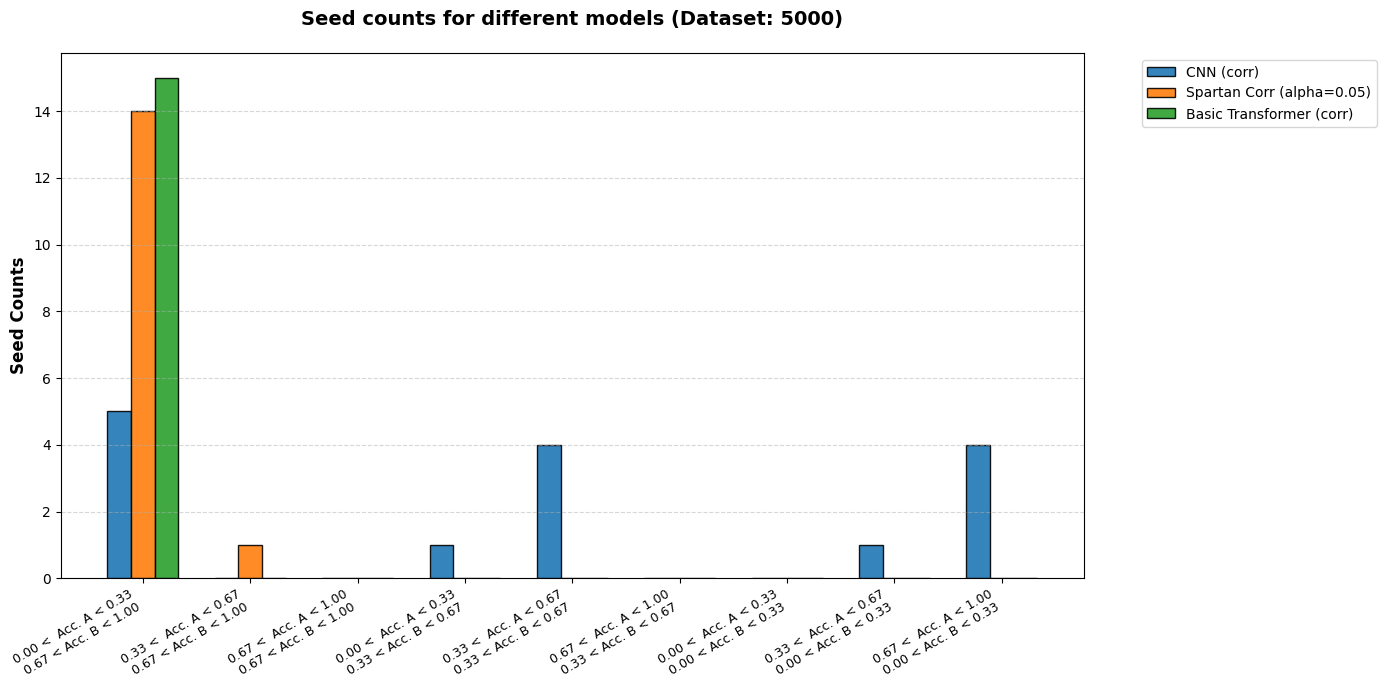

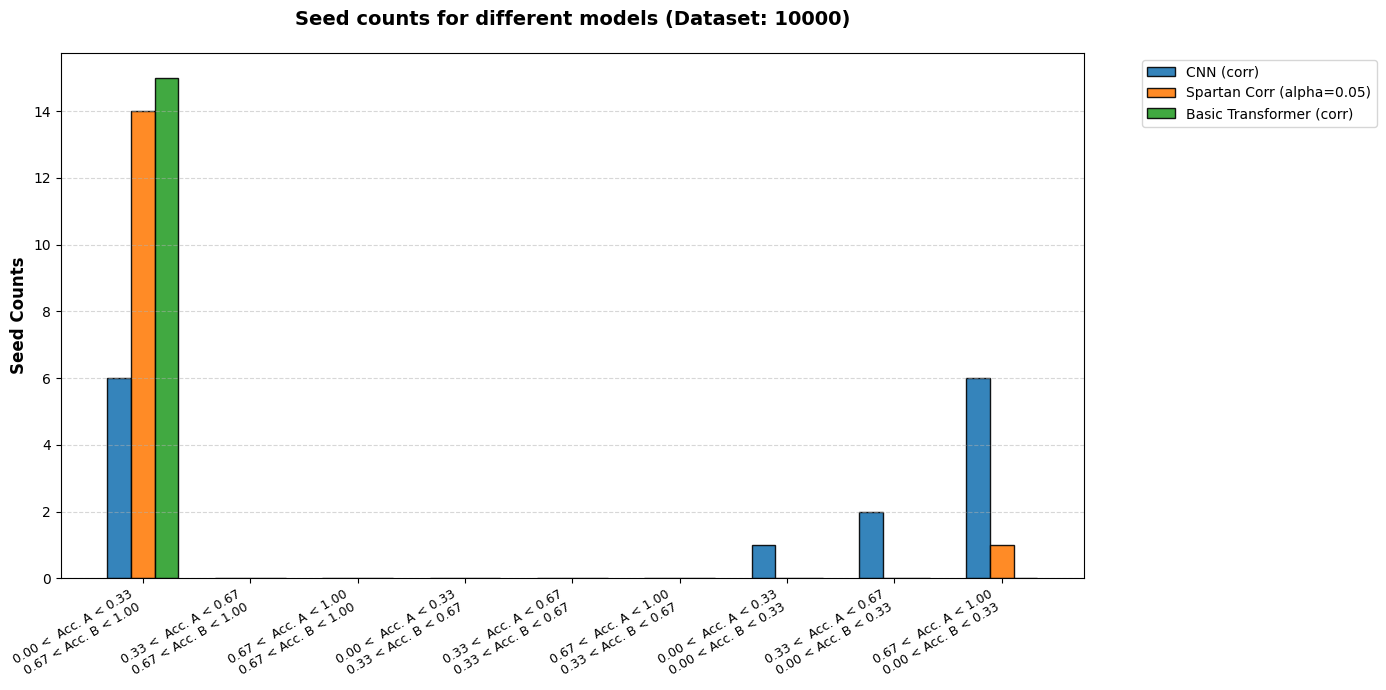

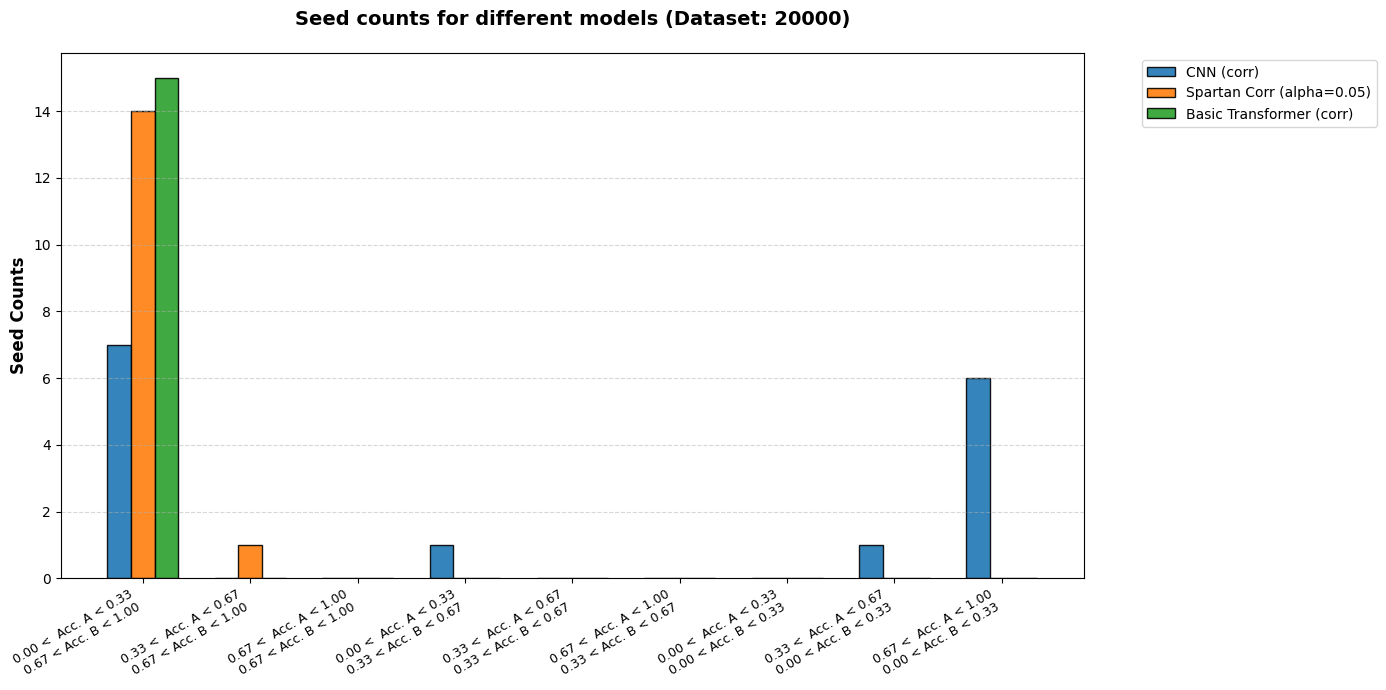

In [29]:
draw_hist_sparse(
     [{'model_name' : 'cnn_shapes', 'name' : 'CNN (corr)', 'corr' : True}, 
      {'model_name' : 'spartan_shapes', 'name': 'Spartan Corr (alpha=0.05)', 
      'spartan' : True, 'corr' : True},
      {'model_name' : 'trans_shapes', 'name': 'Basic Transformer (corr)', 'corr' : True}
      ],
      grid=5,
      size=2000,
);

draw_hist_sparse(
     [{'model_name' : 'cnn_shapes', 'name' : 'CNN (corr)', 'corr' : True}, 
      {'model_name' : 'spartan_shapes', 'name': 'Spartan Corr (alpha=0.05)', 
      'spartan' : True, 'corr' : True},
      {'model_name' : 'trans_shapes', 'name': 'Basic Transformer (corr)', 'corr' : True}
      ],
      grid=5,
      size=5000,
);

draw_hist_sparse(
     [{'model_name' : 'cnn_shapes', 'name' : 'CNN (corr)', 'corr' : True}, 
      {'model_name' : 'spartan_shapes', 'name': 'Spartan Corr (alpha=0.05)', 
      'spartan' : True, 'corr' : True},
      {'model_name' : 'trans_shapes', 'name': 'Basic Transformer (corr)', 'corr' : True}
      ],
      grid=5,
      size=10000,
);

draw_hist_sparse(
     [{'model_name' : 'cnn_shapes', 'name' : 'CNN (corr)', 'corr' : True}, 
      {'model_name' : 'spartan_shapes', 'name': 'Spartan Corr (alpha=0.05)', 
      'spartan' : True, 'corr' : True},
      {'model_name' : 'trans_shapes', 'name': 'Basic Transformer (corr)', 'corr' : True}
      ],
      grid=5,
      size=20000,
);

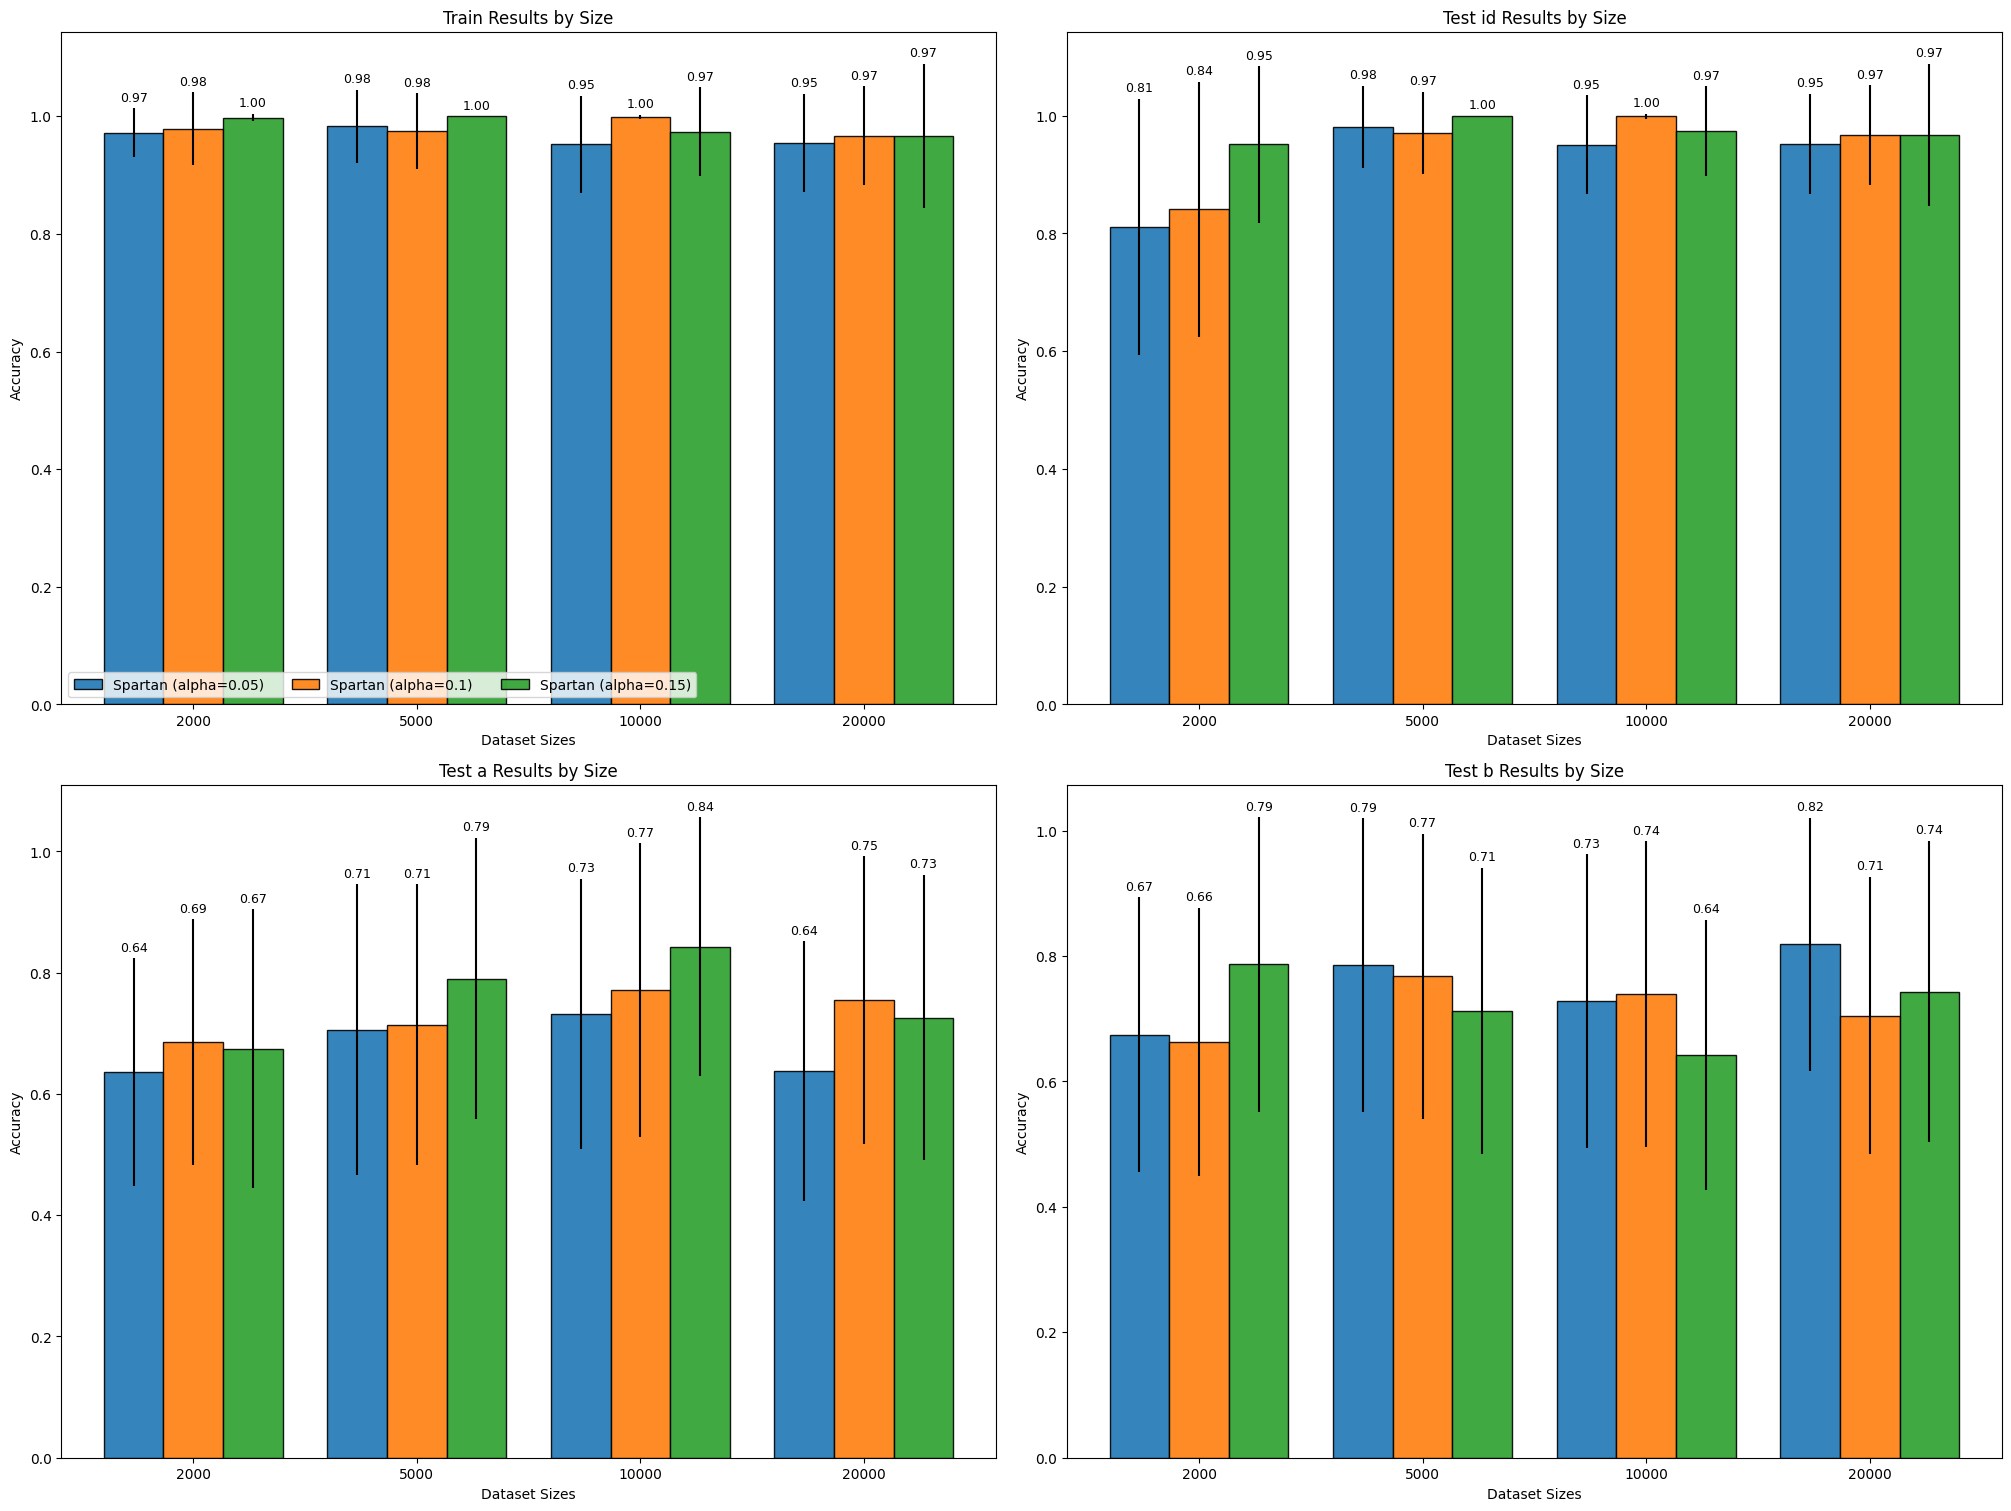

In [6]:
draw_chart_shapes(
    [{'model_name' : 'spartan_shapes', 'name': 'Spartan (alpha=0.05)', 
      'spartan' : True, 'alpha' : 0.05}, 
      {'model_name' : 'spartan_shapes', 'name': 'Spartan (alpha=0.1)', 
      'spartan' : True, 'alpha' : 0.1},
      {'model_name' : 'spartan_shapes', 'name': 'Spartan (alpha=0.15)', 
      'spartan' : True, 'alpha' : 0.15}
      ],
    grid=5,
    sizes=[2000, 5000, 10000, 20000]
);

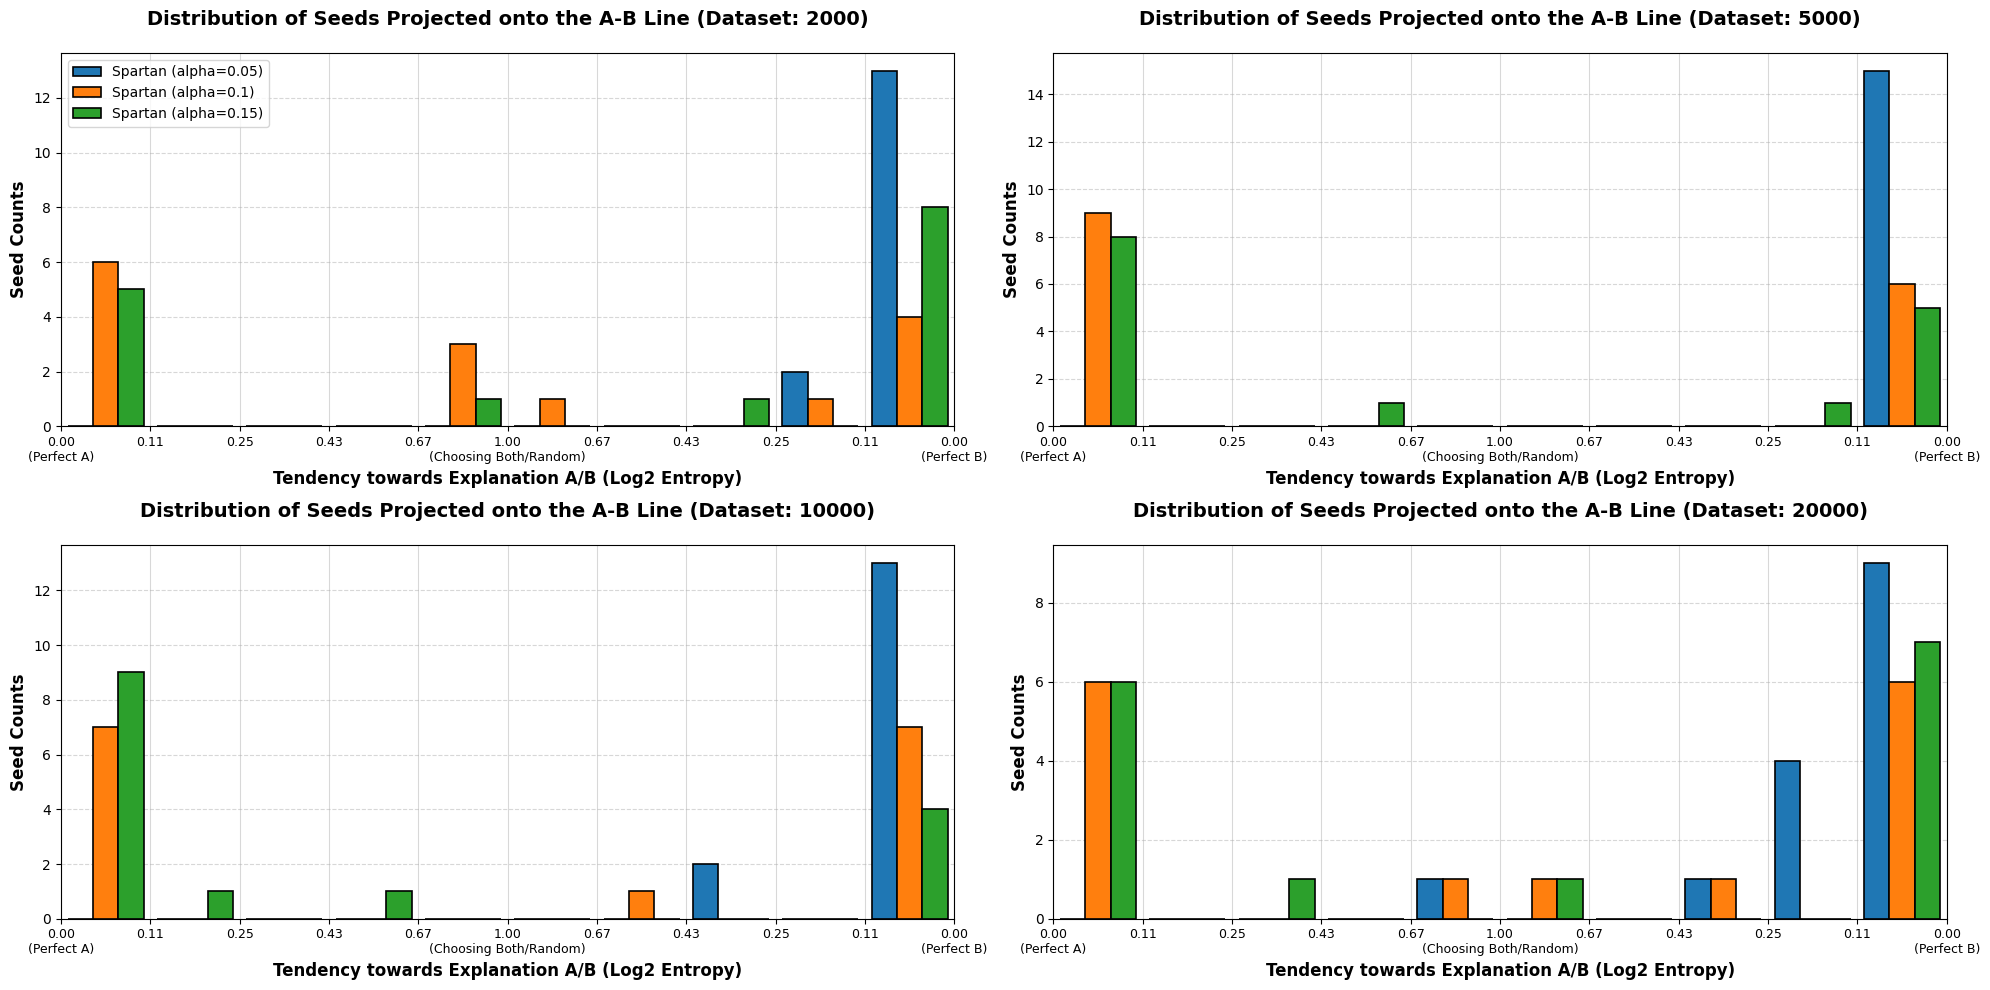

In [ ]:
draw_proj_hist(
     [{'model_name' : 'spartan_shapes', 'name': 'Spartan (alpha=0.05)', 
      'spartan' : True}, 
      {'model_name' : 'spartan_shapes', 'name': 'Spartan (alpha=0.1)', 
      'spartan' : True, 'alpha' : 0.1},
      {'model_name' : 'spartan_shapes', 'name': 'Spartan (alpha=0.15)', 
      'spartan' : True, 'alpha' : 0.15}
      ],
      grid=5,
);


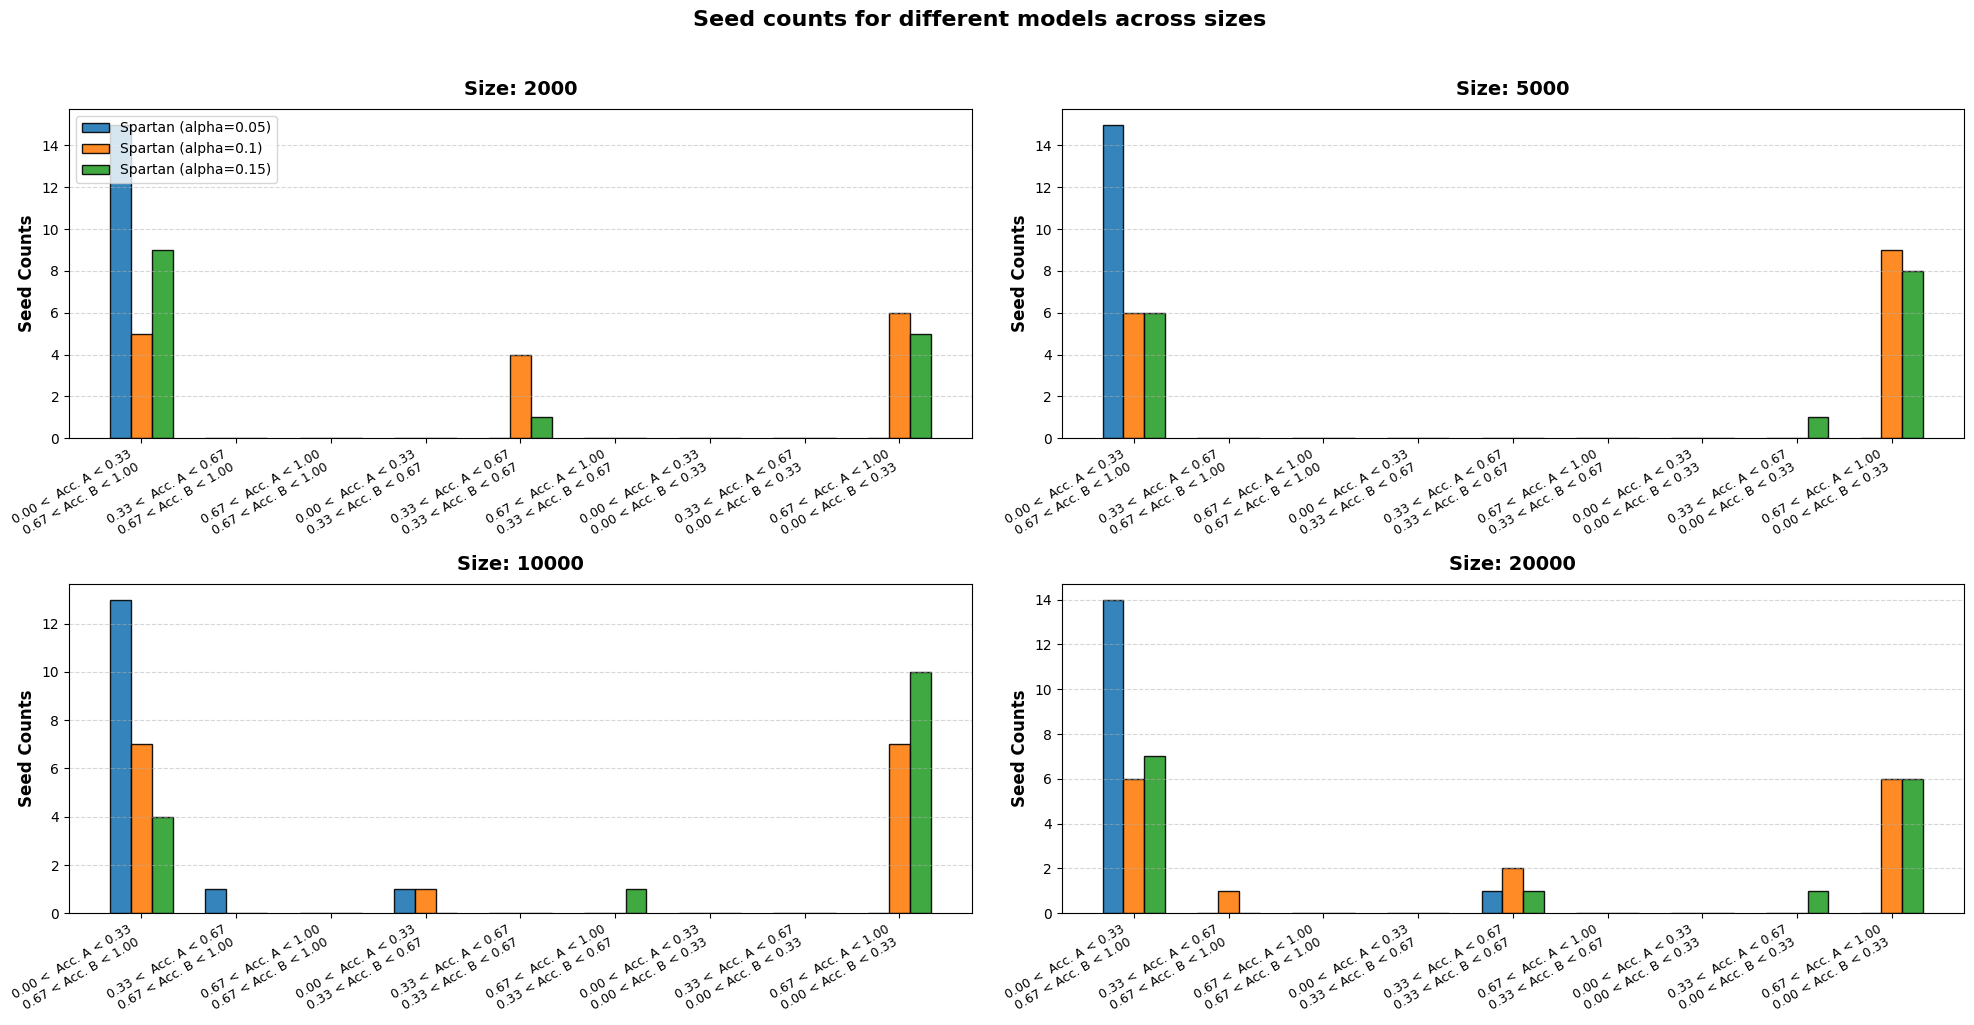

In [14]:
draw_hist_sparse(
     [{'model_name' : 'spartan_shapes', 'name': 'Spartan (alpha=0.05)', 
      'spartan' : True}, 
      {'model_name' : 'spartan_shapes', 'name': 'Spartan (alpha=0.1)', 
      'spartan' : True, 'alpha' : 0.1},
      {'model_name' : 'spartan_shapes', 'name': 'Spartan (alpha=0.15)', 
      'spartan' : True, 'alpha' : 0.15}
      ],
      grid=5,
);


### Emb vs One Hot (Agg)

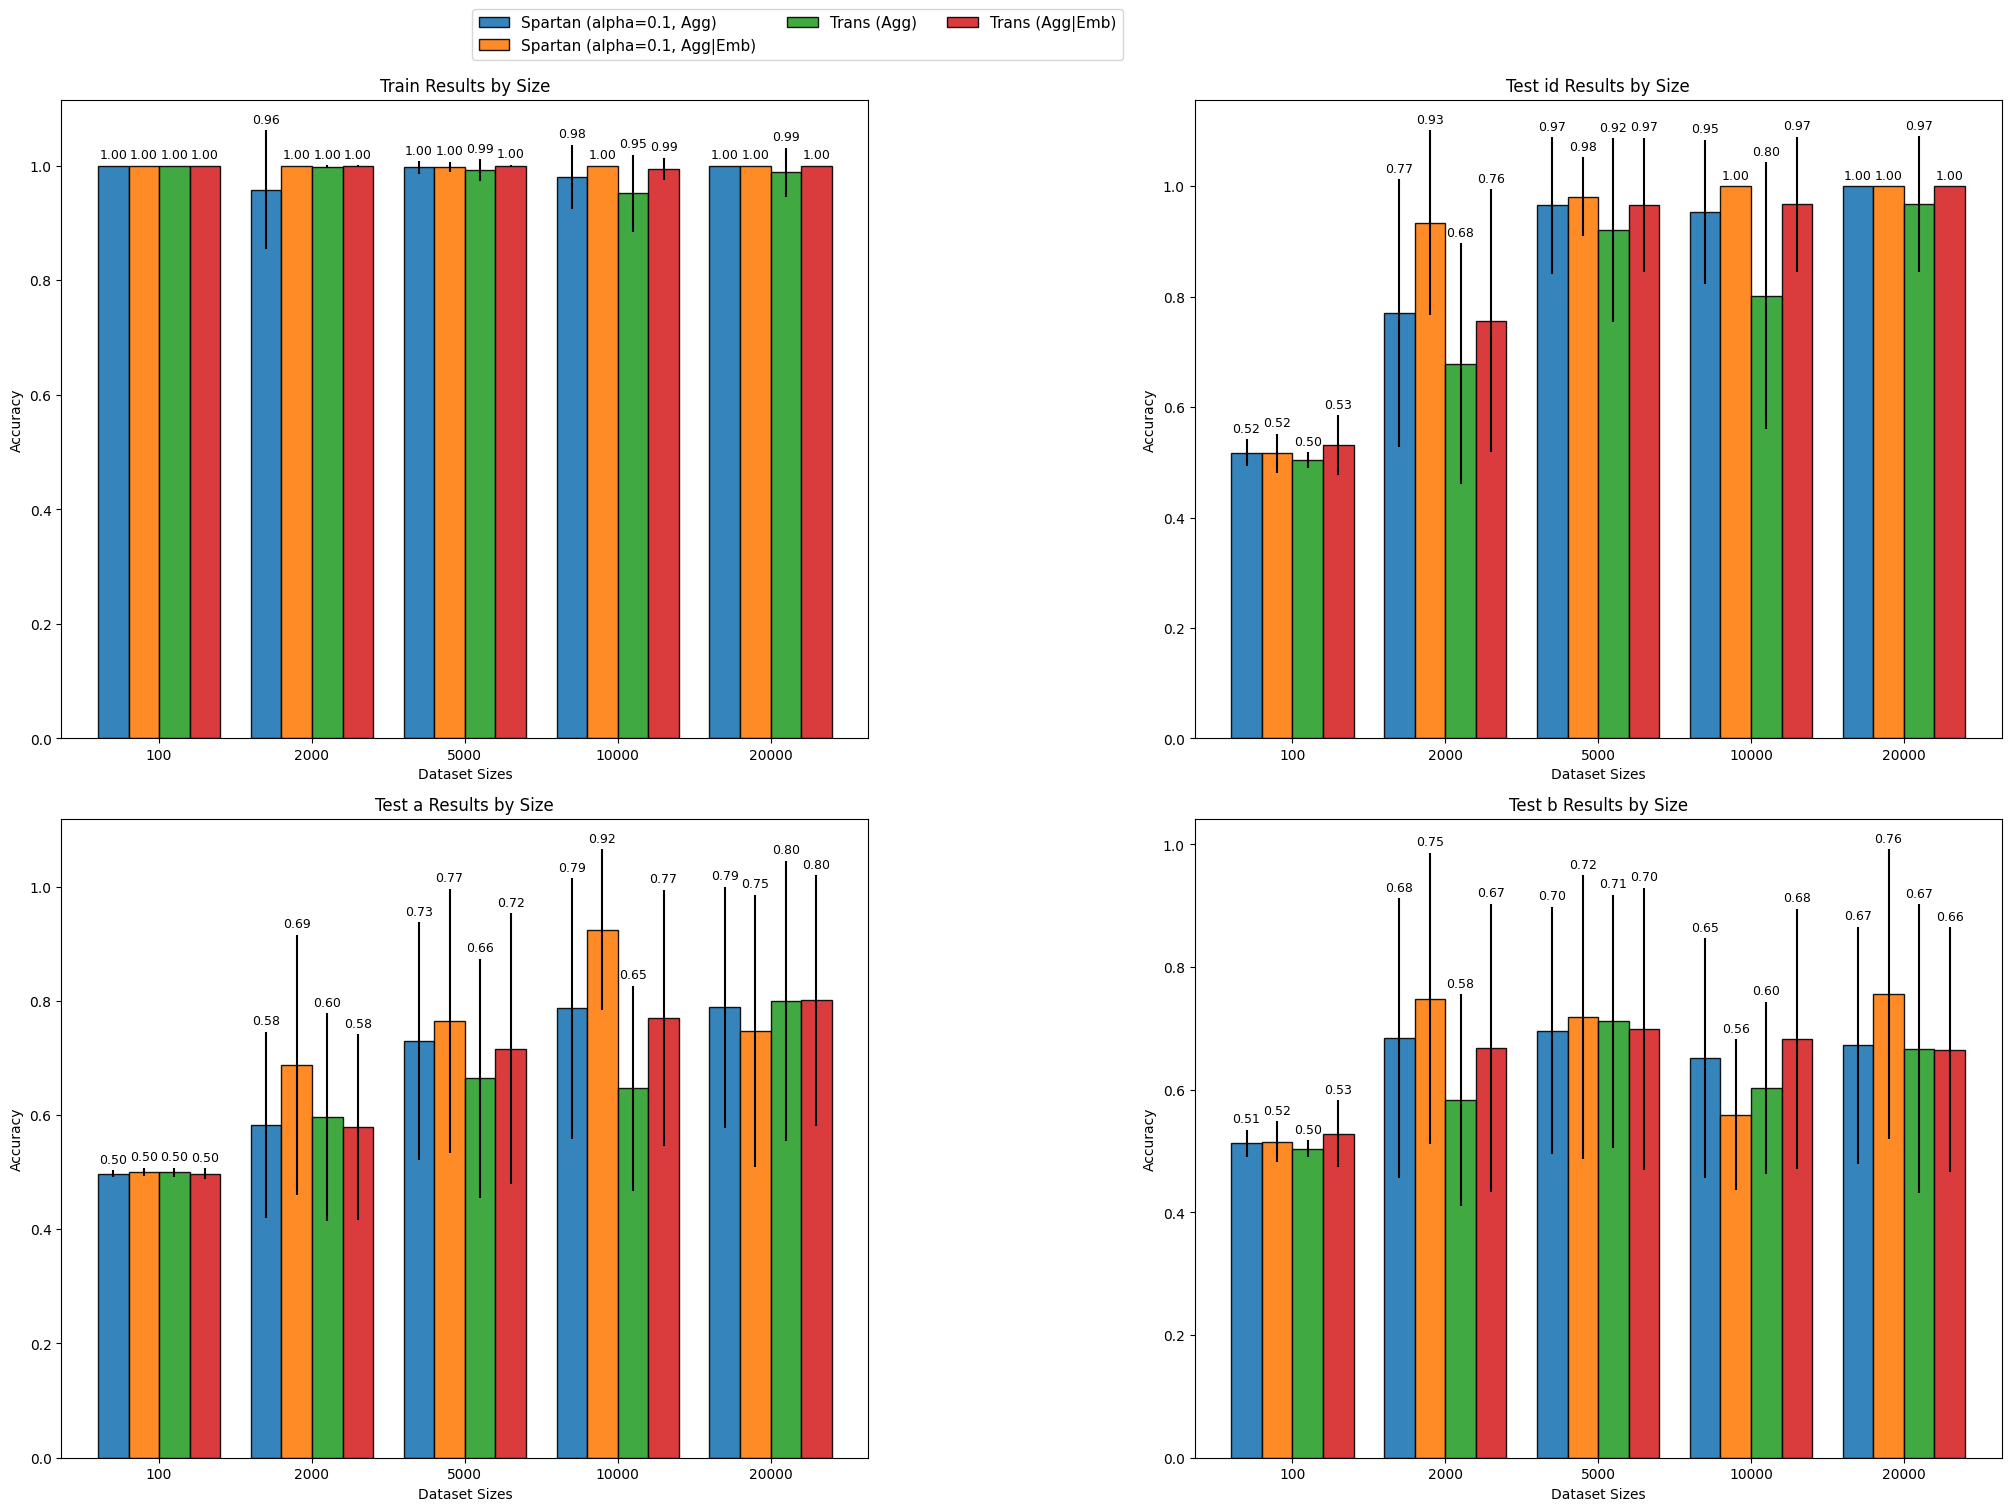

In [7]:
draw_chart_shapes(
    [{'model_name' : 'spartan_shapes_agg', 'name': 'Spartan (alpha=0.1, Agg)', 
      'spartan' : True}, 
      {'model_name' : 'spartan_shapes_agg_emb', 'name': 'Spartan (alpha=0.1, Agg|Emb)', 
      'spartan' : True},
      {'model_name' : 'trans_shapes_agg', 'name': 'Trans (Agg)'},
      {'model_name' : 'trans_shapes_agg_emb', 'name': 'Trans (Agg|Emb)'},
      ],
    grid=5,
    sizes=[100, 2000, 5000, 10000, 20000]
);

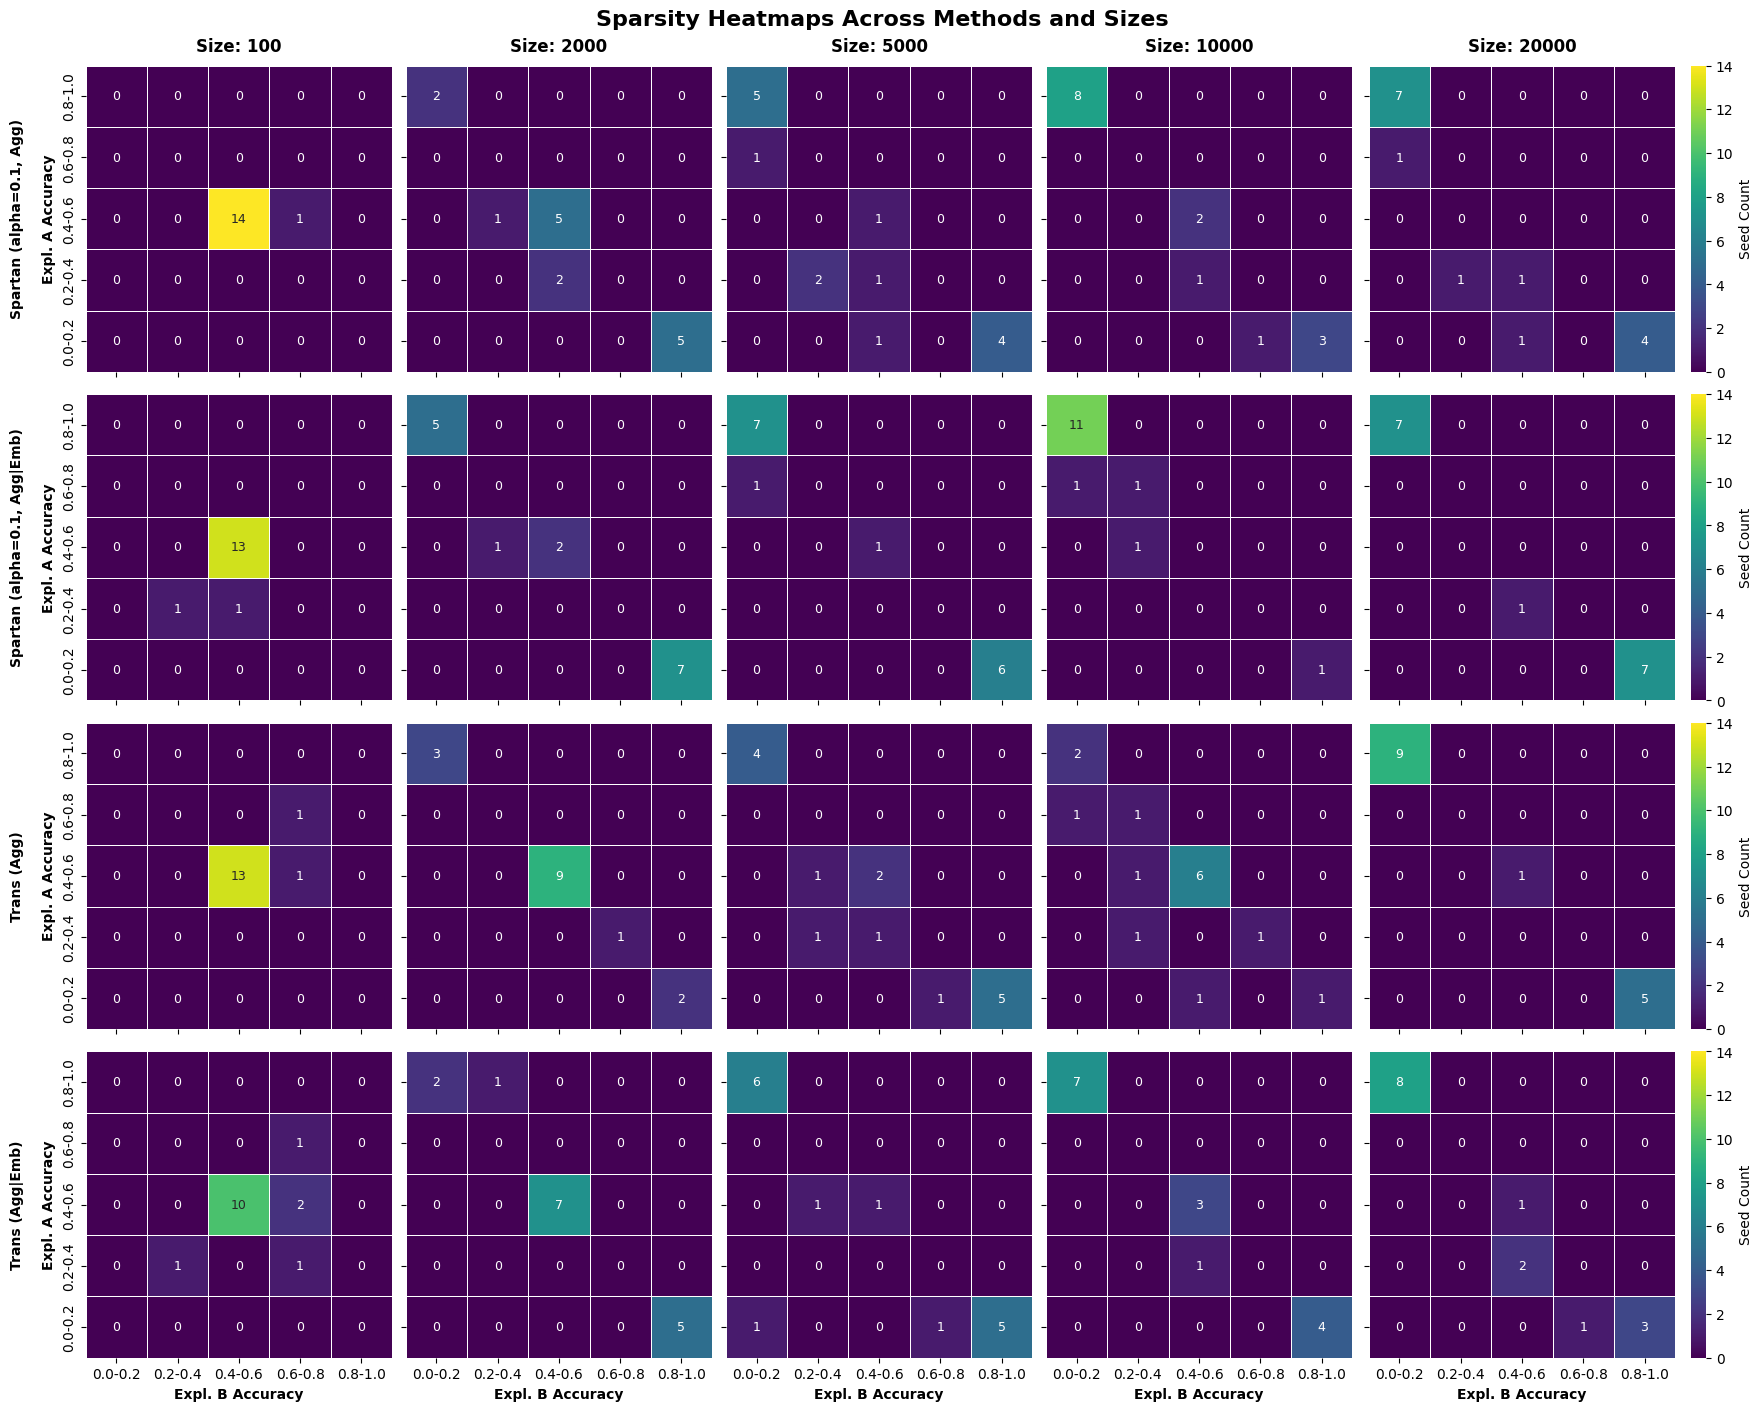

In [6]:
draw_2d_heatmap(
    [{'model_name' : 'spartan_shapes_agg', 'name': 'Spartan (alpha=0.1, Agg)', 
          'spartan' : True}, 
          {'model_name' : 'spartan_shapes_agg_emb', 'name': 'Spartan (alpha=0.1, Agg|Emb)', 
          'spartan' : True},
          {'model_name' : 'trans_shapes_agg', 'name': 'Trans (Agg)'},
          {'model_name' : 'trans_shapes_agg_emb', 'name': 'Trans (Agg|Emb)'},
          ],
);


### Different Alphas (No Agg)

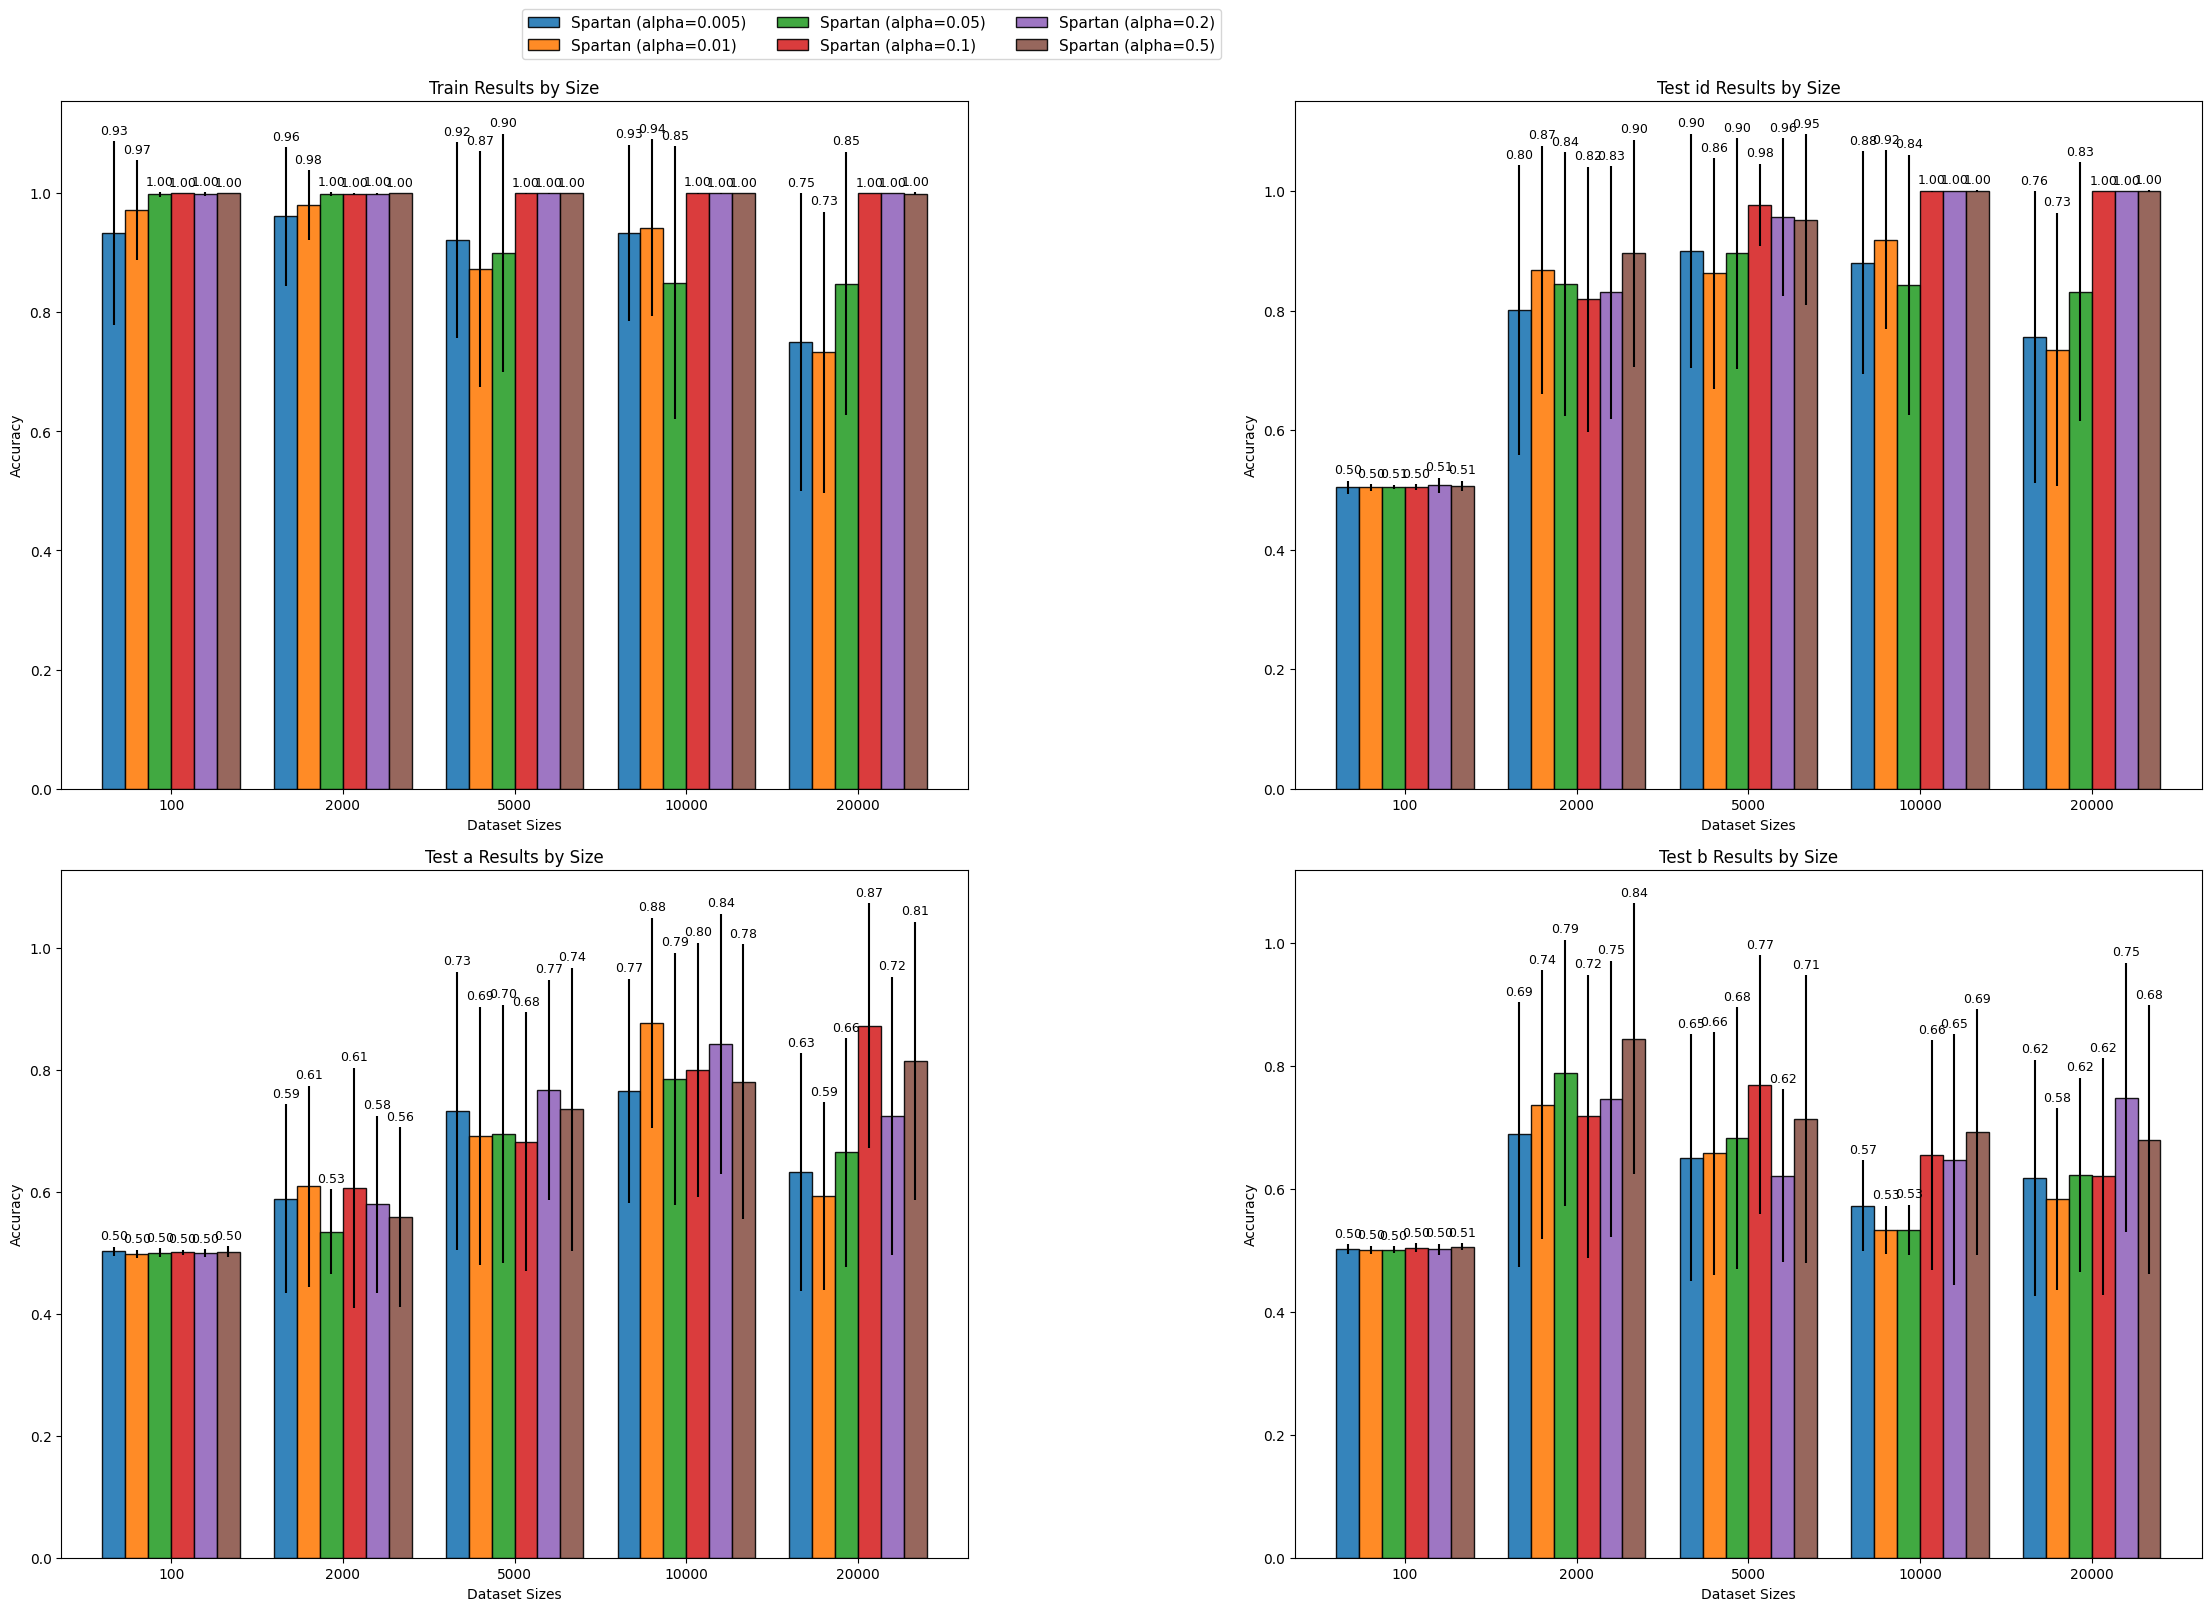

In [14]:
draw_chart_shapes(
    [{'model_name' : 'spartan_shapes_oh', 'name': 'Spartan (alpha=0.005)', 
      'spartan' : True, 'alpha' : 0.005},
      {'model_name' : 'spartan_shapes_oh', 'name': 'Spartan (alpha=0.01)', 
      'spartan' : True, 'alpha' : 0.01},
      {'model_name' : 'spartan_shapes_oh', 'name': 'Spartan (alpha=0.05)', 
      'spartan' : True, 'alpha' : 0.05},
      {'model_name' : 'spartan_shapes_oh', 'name': 'Spartan (alpha=0.1)', 
      'spartan' : True, 'alpha' : 0.1}, 
      {'model_name' : 'spartan_shapes_oh', 'name': 'Spartan (alpha=0.2)', 
      'spartan' : True, 'alpha' : 0.2},
      {'model_name' : 'spartan_shapes_oh', 'name': 'Spartan (alpha=0.5)', 
      'spartan' : True, 'alpha' : 0.5},
      
      ],
    grid=5,
    sizes=[100, 2000, 5000, 10000, 20000],
    figsize=(22, 16)
);

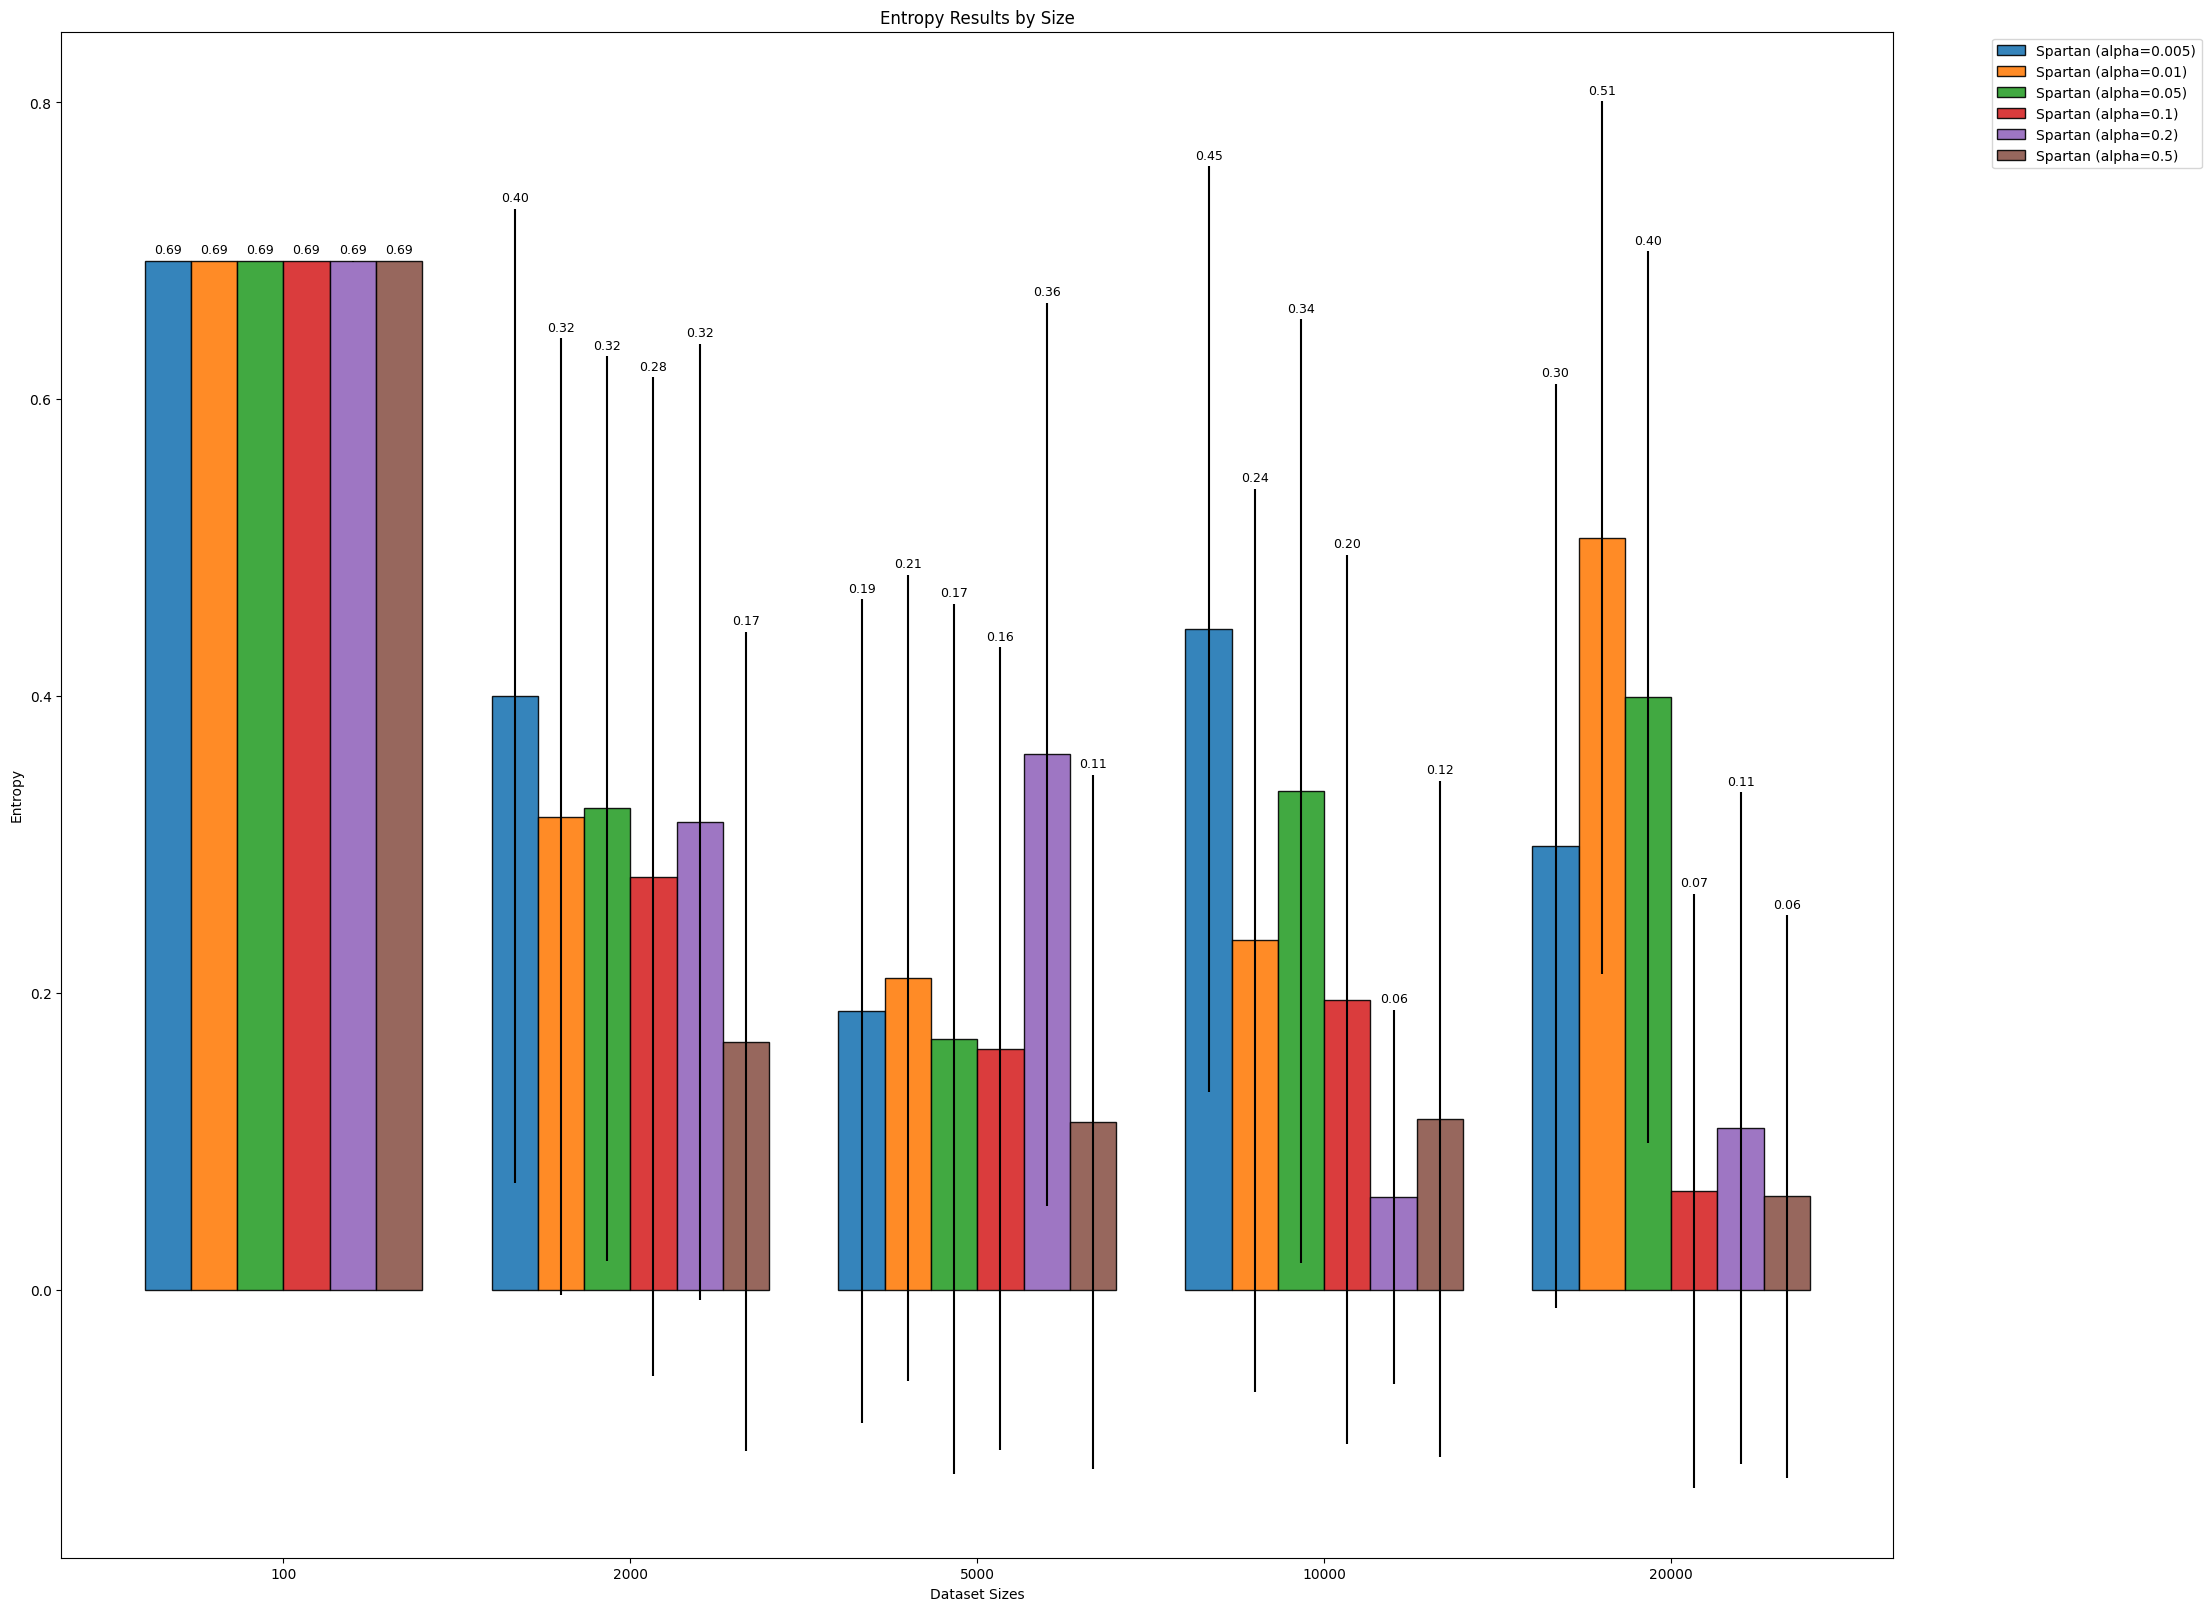

In [19]:
draw_entropy(
    [{'model_name' : 'spartan_shapes_oh', 'name': 'Spartan (alpha=0.005)', 
      'spartan' : True, 'alpha' : 0.005},
      {'model_name' : 'spartan_shapes_oh', 'name': 'Spartan (alpha=0.01)', 
      'spartan' : True, 'alpha' : 0.01},
      {'model_name' : 'spartan_shapes_oh', 'name': 'Spartan (alpha=0.05)', 
      'spartan' : True, 'alpha' : 0.05},
      {'model_name' : 'spartan_shapes_oh', 'name': 'Spartan (alpha=0.1)', 
      'spartan' : True, 'alpha' : 0.1}, 
      {'model_name' : 'spartan_shapes_oh', 'name': 'Spartan (alpha=0.2)', 
      'spartan' : True, 'alpha' : 0.2},
      {'model_name' : 'spartan_shapes_oh', 'name': 'Spartan (alpha=0.5)', 
      'spartan' : True, 'alpha' : 0.5},
      
      ],
    grid=5,
    sizes=[100, 2000, 5000, 10000, 20000],
    figsize=(22, 16)
);

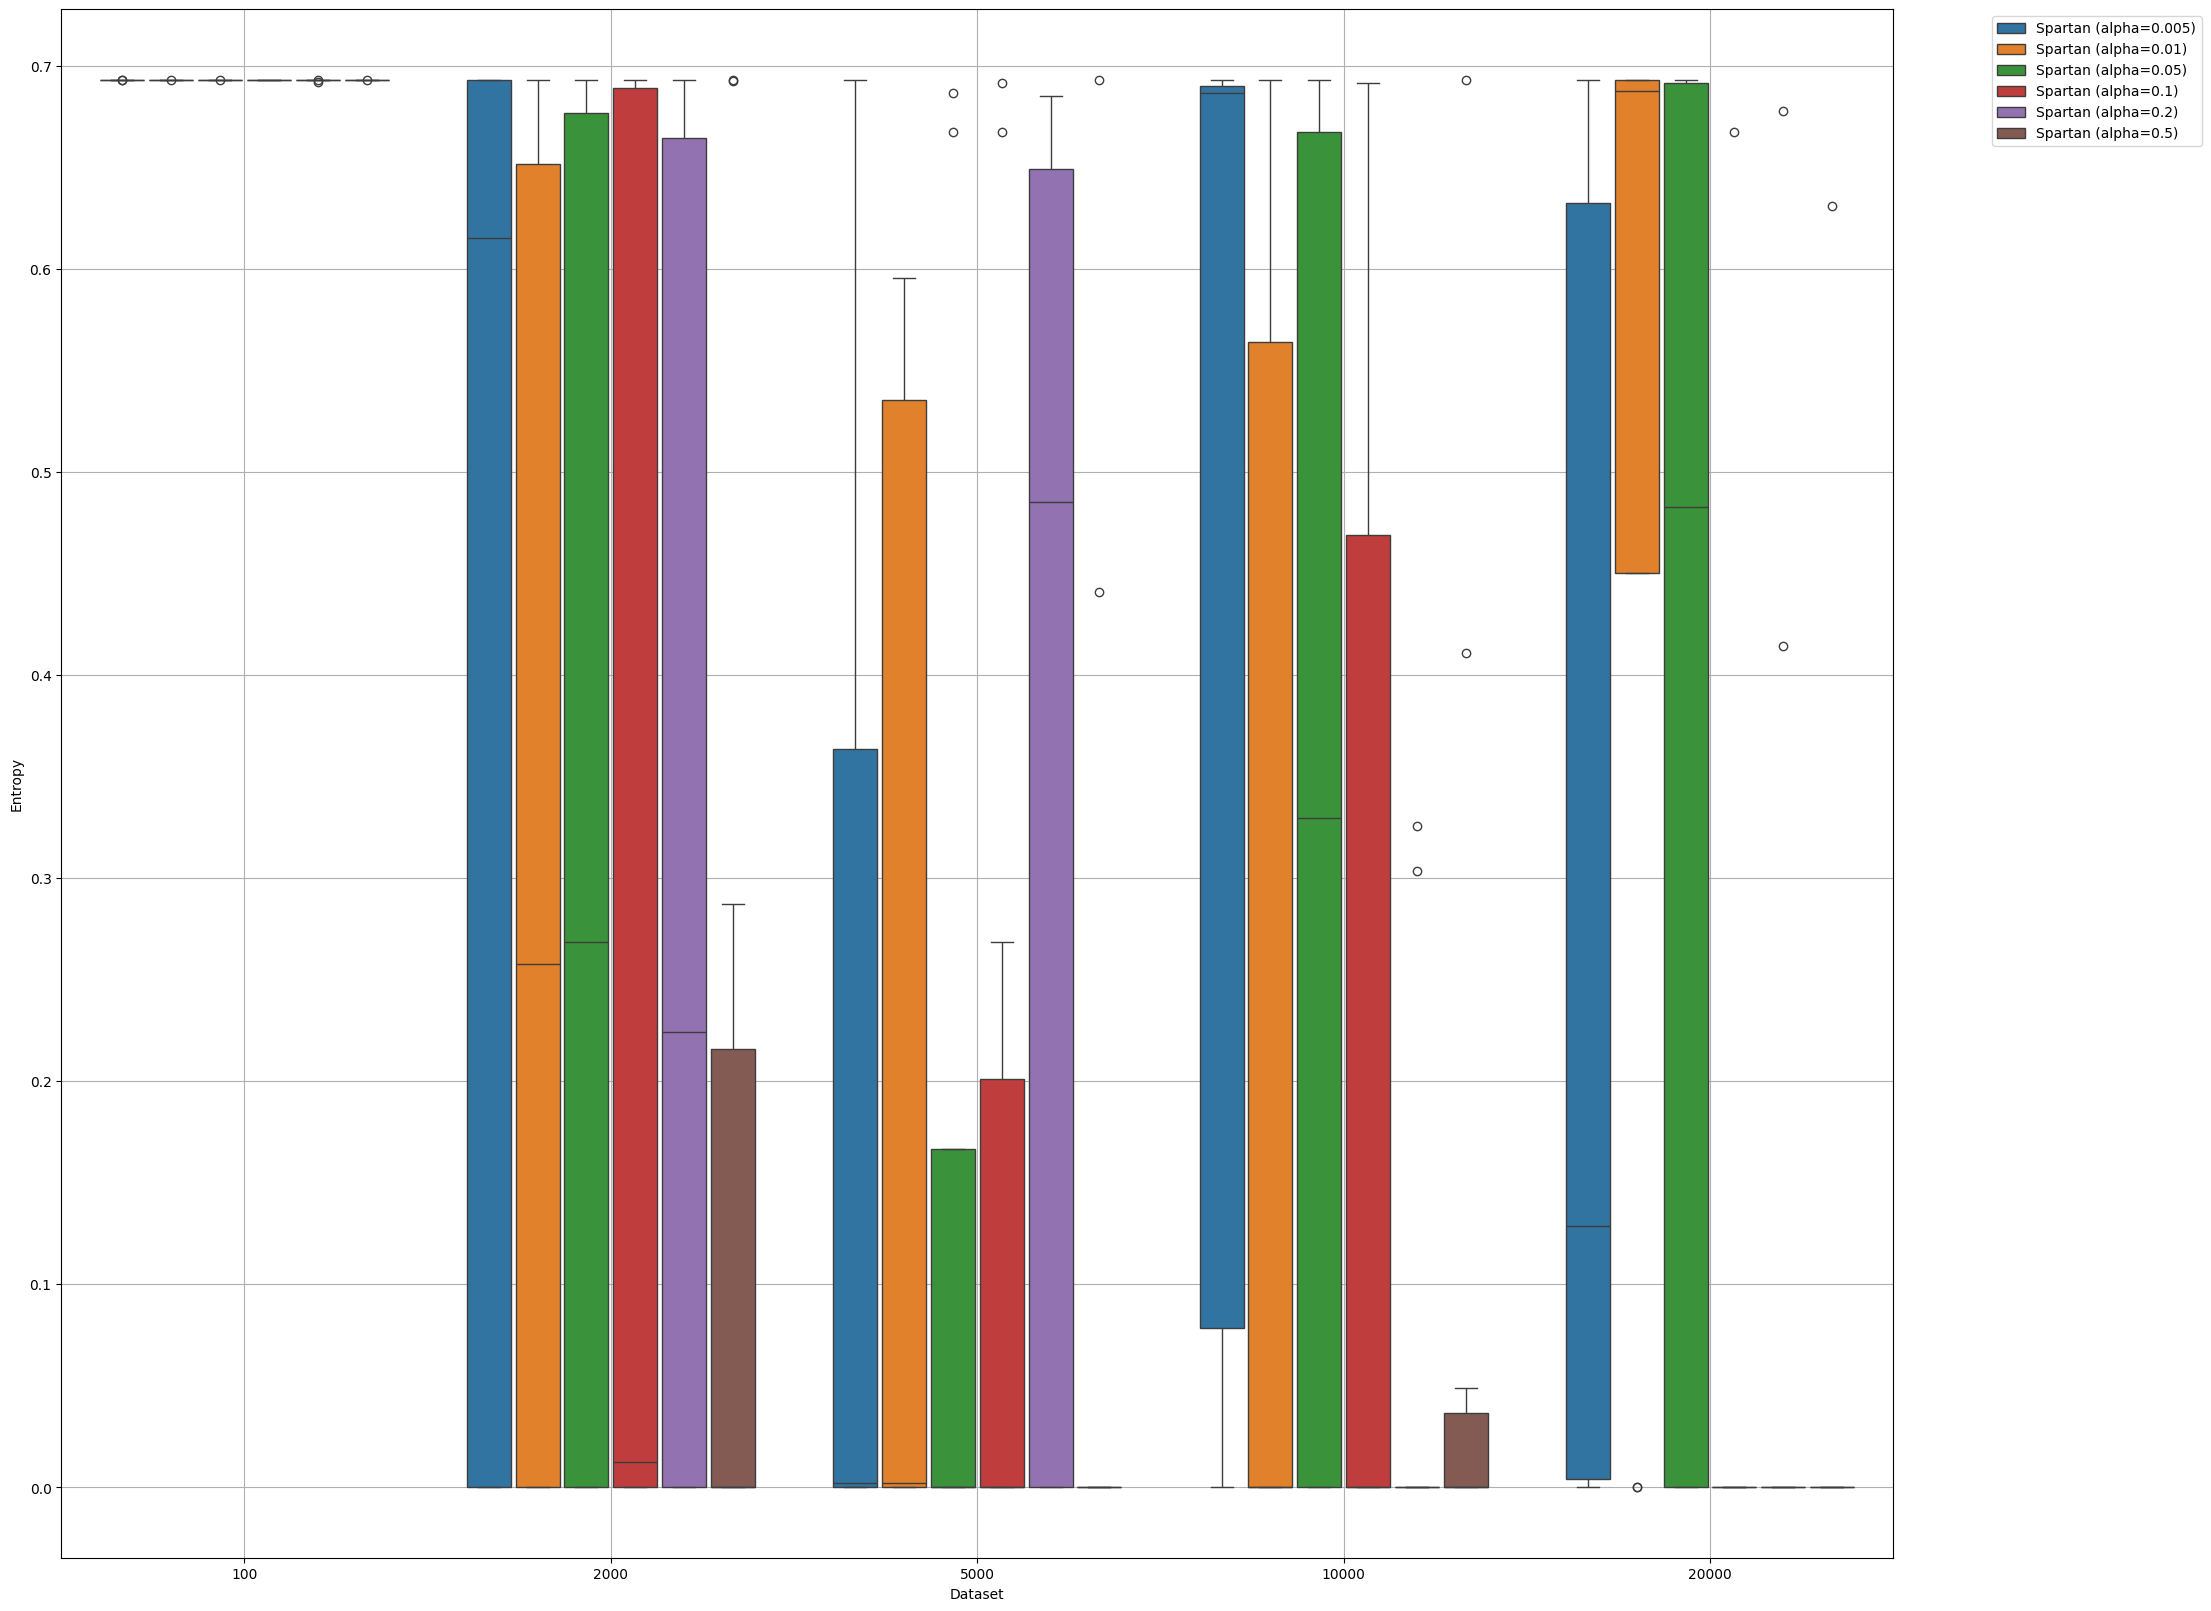

In [22]:
draw_entropy_box(
    [{'model_name' : 'spartan_shapes_oh', 'name': 'Spartan (alpha=0.005)', 
      'spartan' : True, 'alpha' : 0.005},
      {'model_name' : 'spartan_shapes_oh', 'name': 'Spartan (alpha=0.01)', 
      'spartan' : True, 'alpha' : 0.01},
      {'model_name' : 'spartan_shapes_oh', 'name': 'Spartan (alpha=0.05)', 
      'spartan' : True, 'alpha' : 0.05},
      {'model_name' : 'spartan_shapes_oh', 'name': 'Spartan (alpha=0.1)', 
      'spartan' : True, 'alpha' : 0.1}, 
      {'model_name' : 'spartan_shapes_oh', 'name': 'Spartan (alpha=0.2)', 
      'spartan' : True, 'alpha' : 0.2},
      {'model_name' : 'spartan_shapes_oh', 'name': 'Spartan (alpha=0.5)', 
      'spartan' : True, 'alpha' : 0.5},
      
      ],
    grid=5,
    sizes=[100, 2000, 5000, 10000, 20000],
    figsize=(22, 16)
);

### One hot encoding results 

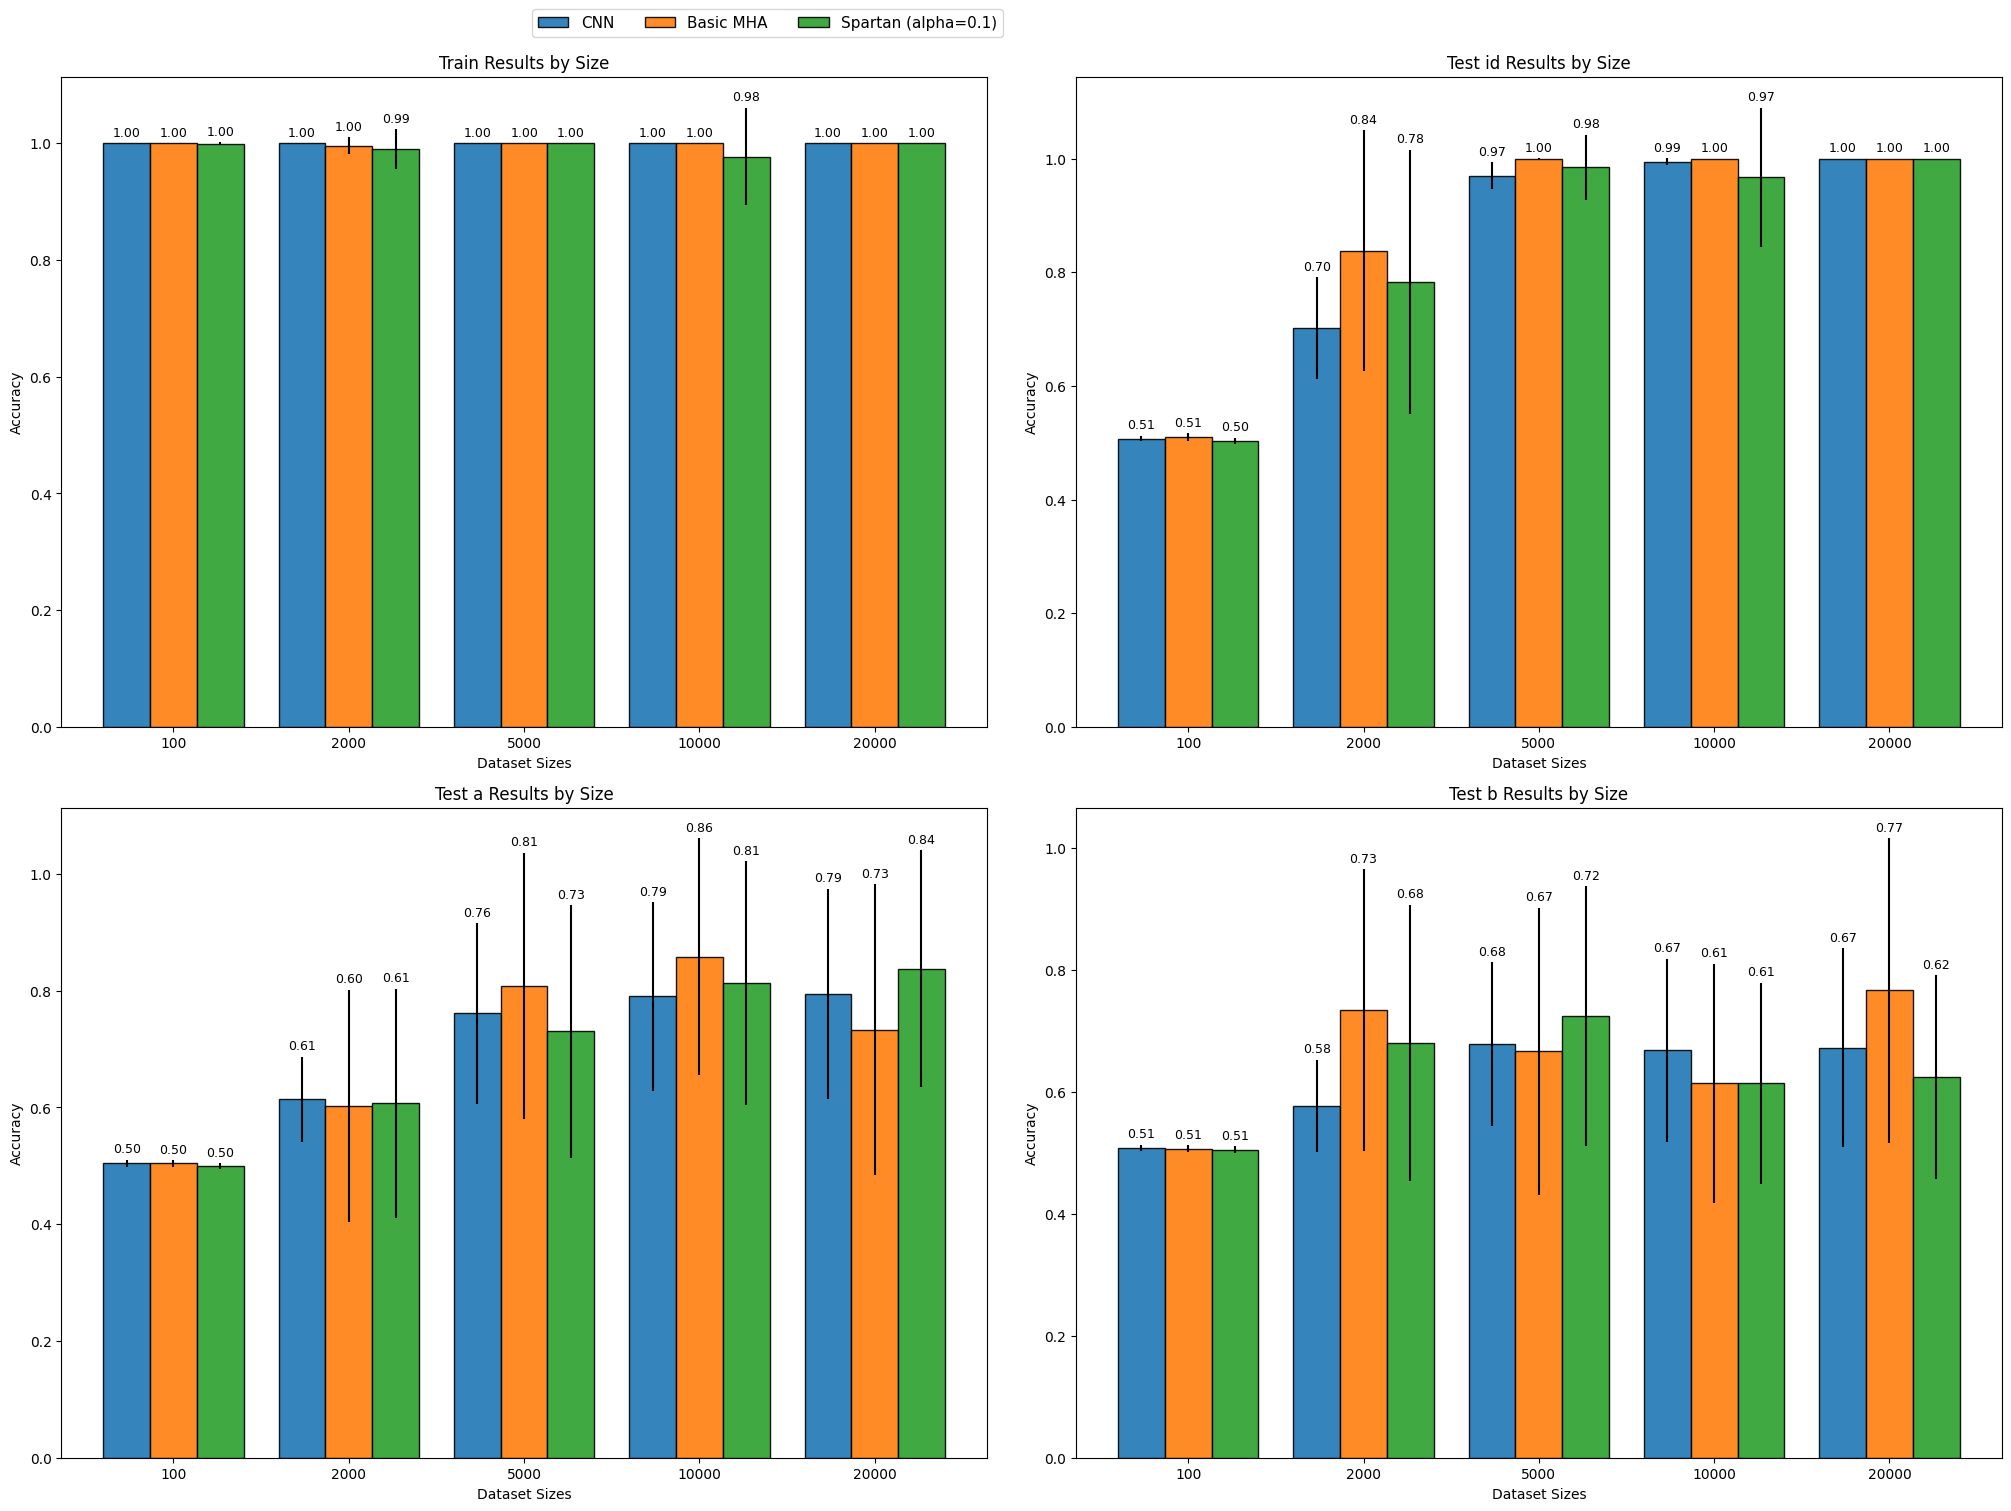

In [17]:
draw_chart_shapes(
    [{'model_name' : 'cnn_shapes', 'name': 'CNN'},
     {'model_name' : 'trans_shapes', 'name': 'Basic MHA'},  
      {'model_name' : 'spartan_shapes_oh15', 'name': 'Spartan (alpha=0.1)', 
      'spartan' : True, 'alpha' : 0.1}
      ],
    grid=5,
    sizes=[100, 2000, 5000, 10000, 20000]
);

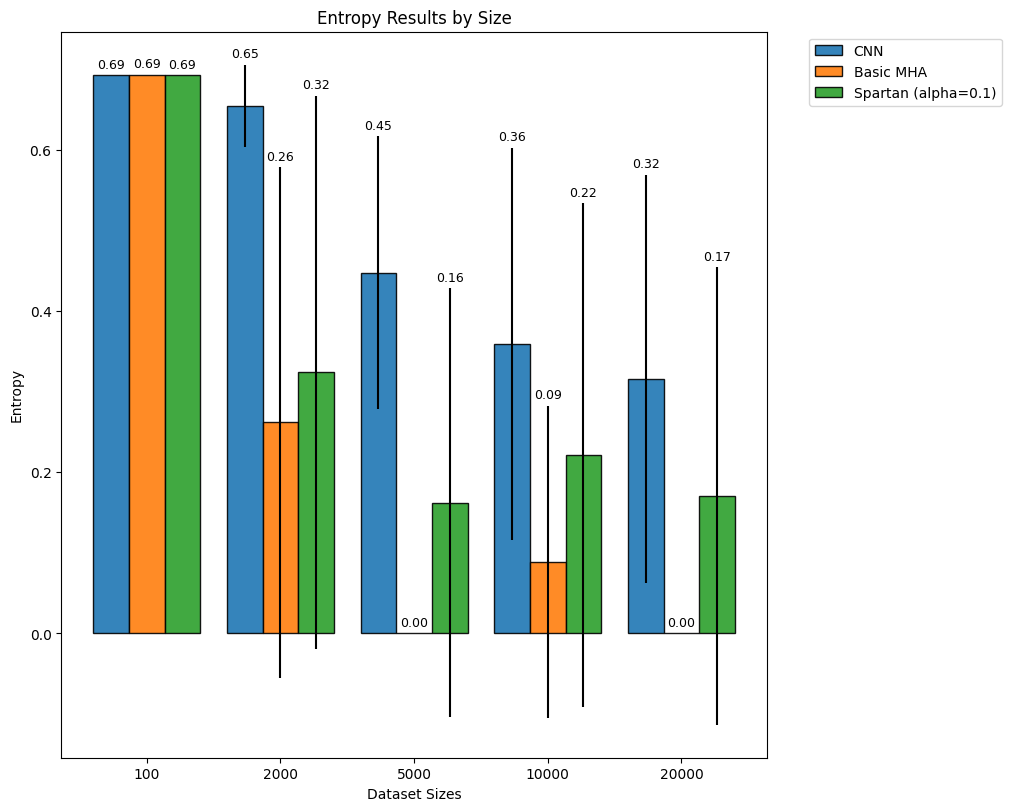

In [18]:
draw_entropy(
    [{'model_name' : 'cnn_shapes', 'name': 'CNN'},
     {'model_name' : 'trans_shapes', 'name': 'Basic MHA'},  
      {'model_name' : 'spartan_shapes_oh15', 'name': 'Spartan (alpha=0.1)', 
      'spartan' : True, 'alpha' : 0.1}
      ],
    grid=5,
    sizes=[100, 2000, 5000, 10000, 20000]
);

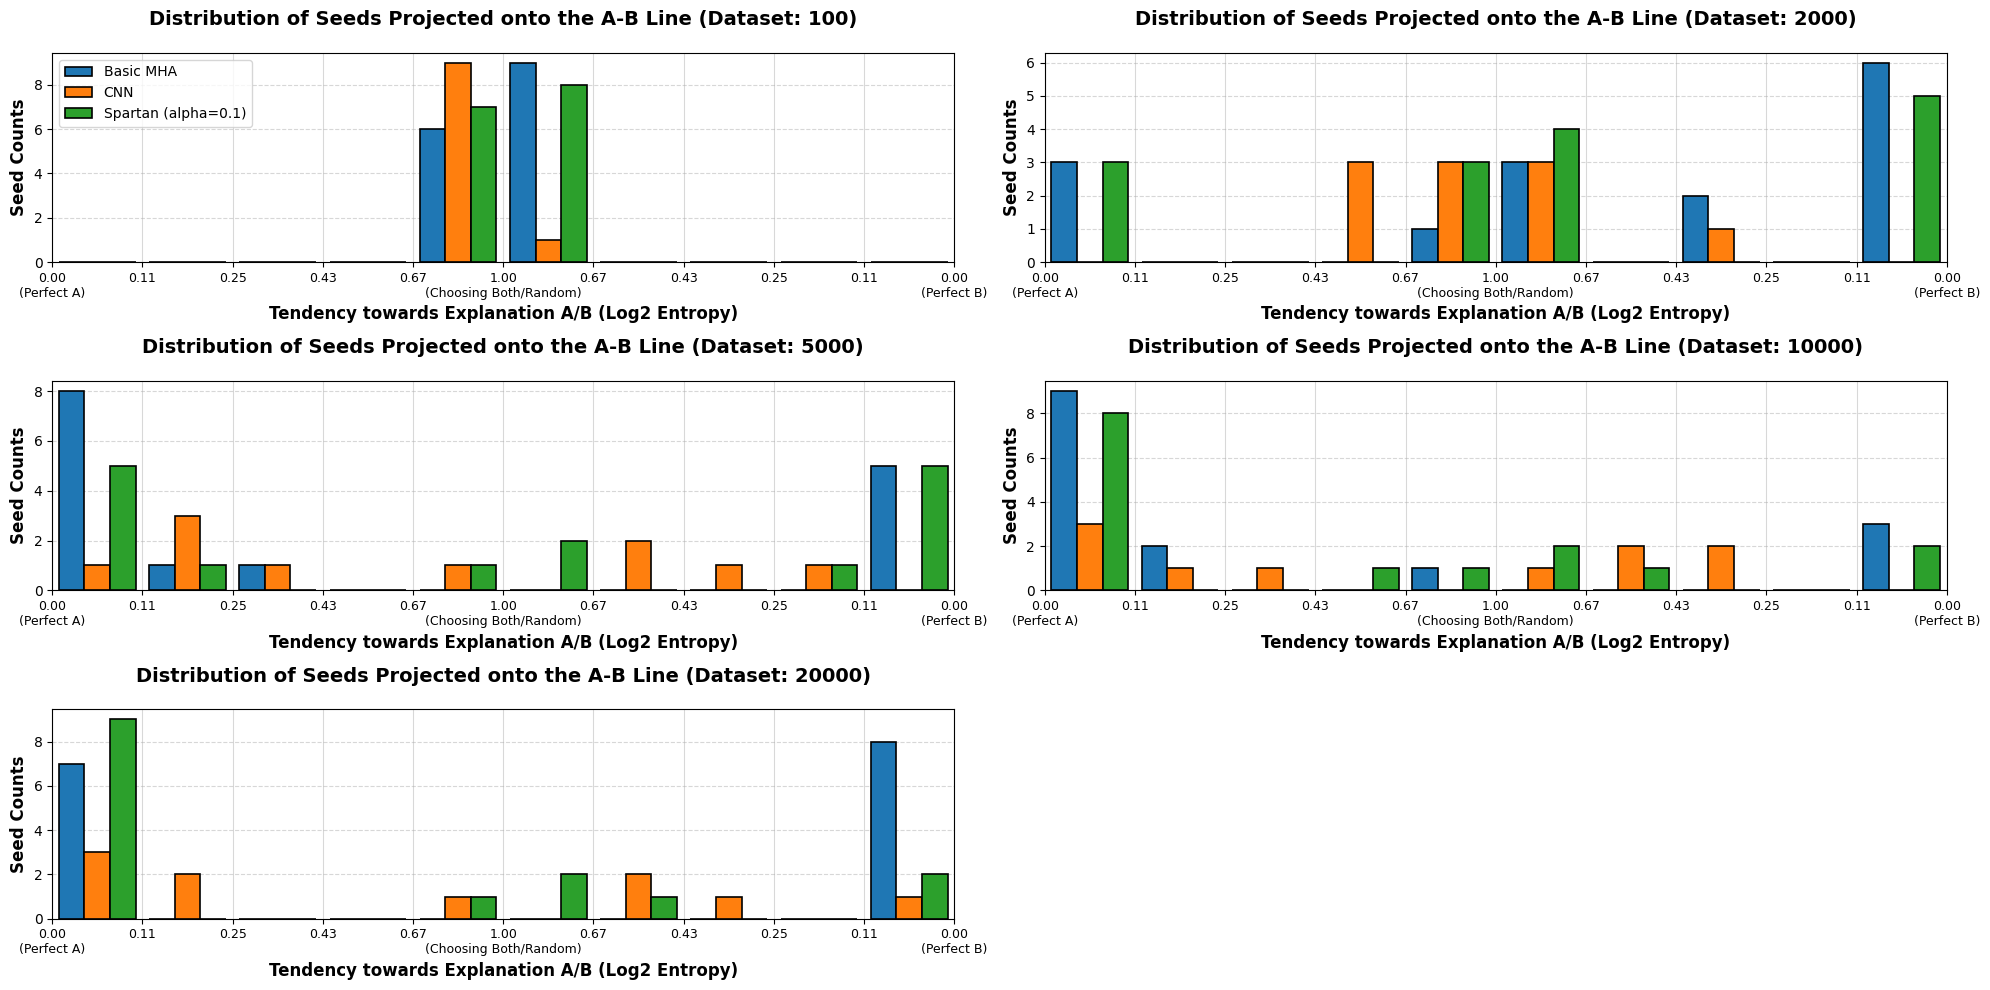

In [19]:
draw_proj_hist(
     [{'model_name' : 'trans_shapes', 'name': 'Basic MHA'}, 
      {'model_name' : 'cnn_shapes', 'name': 'CNN'},
      {'model_name' : 'spartan_shapes_oh15', 'name': 'Spartan (alpha=0.1)', 
      'spartan' : True, 'alpha' : 0.1}
      ],
      grid=5,
      sizes=[100, 2000, 5000, 10000, 20000]
);


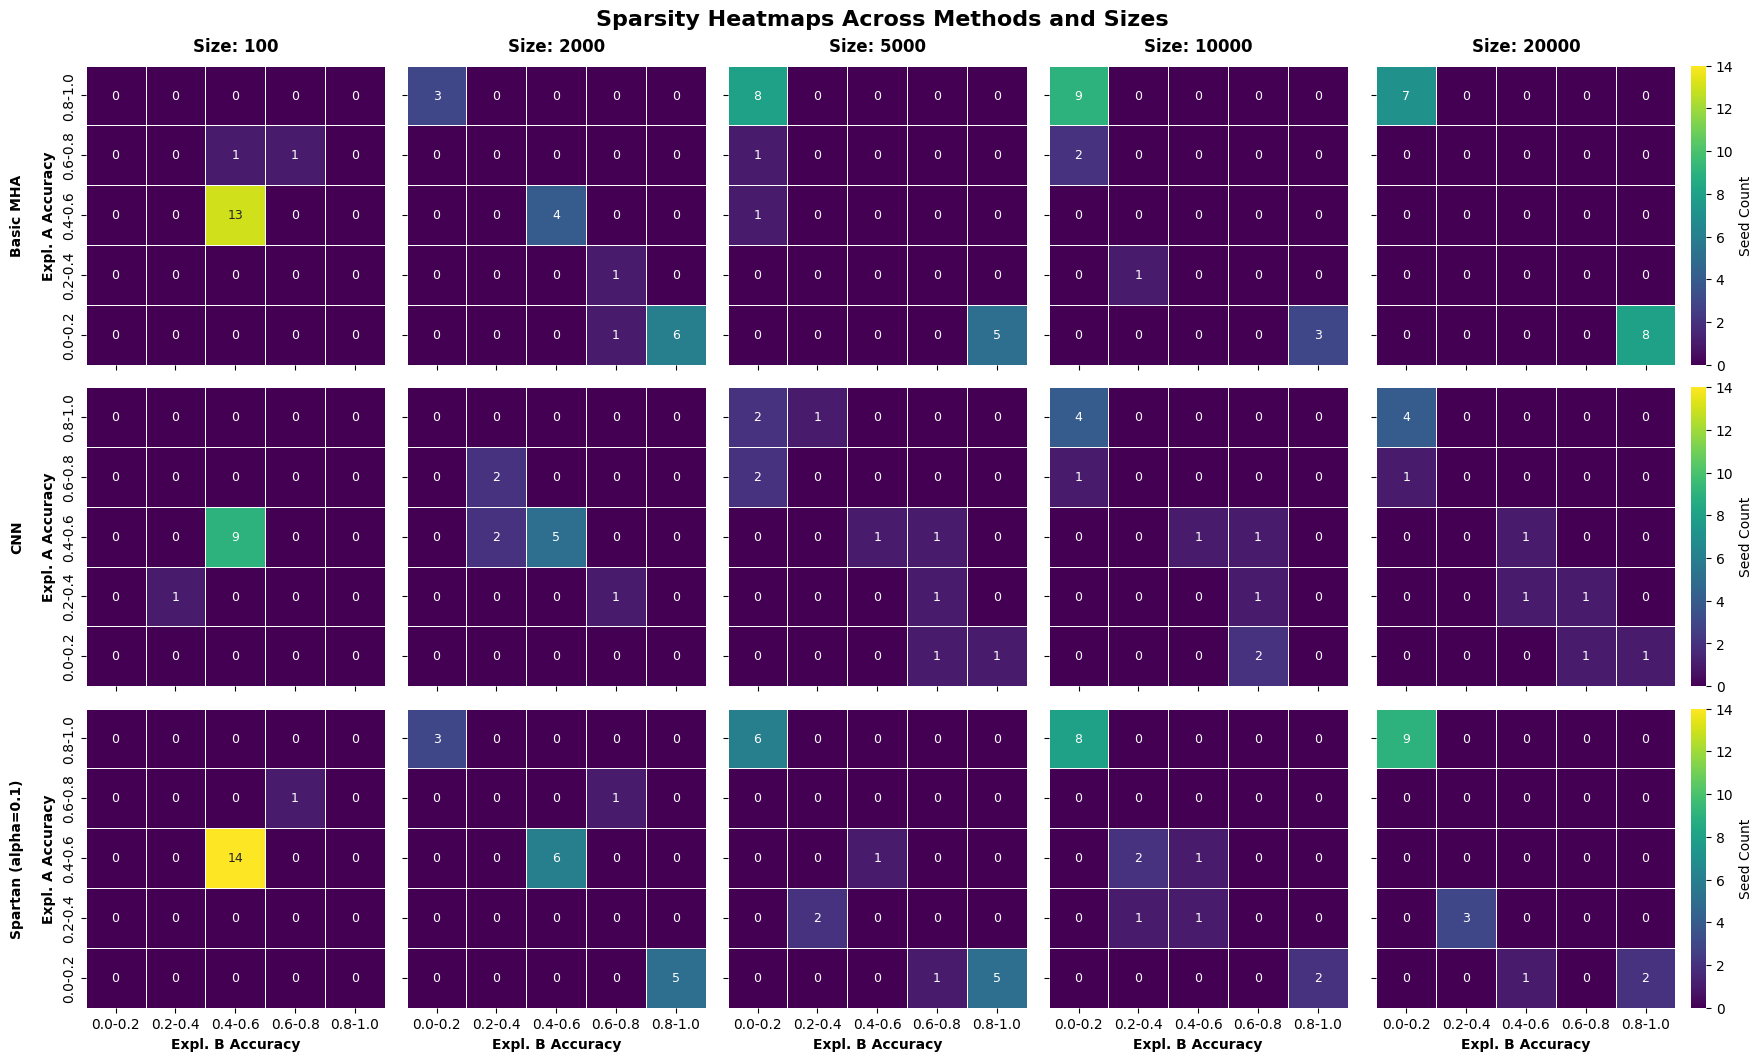

In [ ]:
draw_2d_heatmap(
     [{'model_name' : 'trans_shapes', 'name': 'Basic MHA'}, 
      {'model_name' : 'cnn_shapes', 'name': 'CNN'},
      {'model_name' : 'spartan_shapes_oh15', 'name': 'Spartan (alpha=0.1)', 
      'spartan' : True, 'alpha' : 0.1}
      ],
);


### Ensembles results

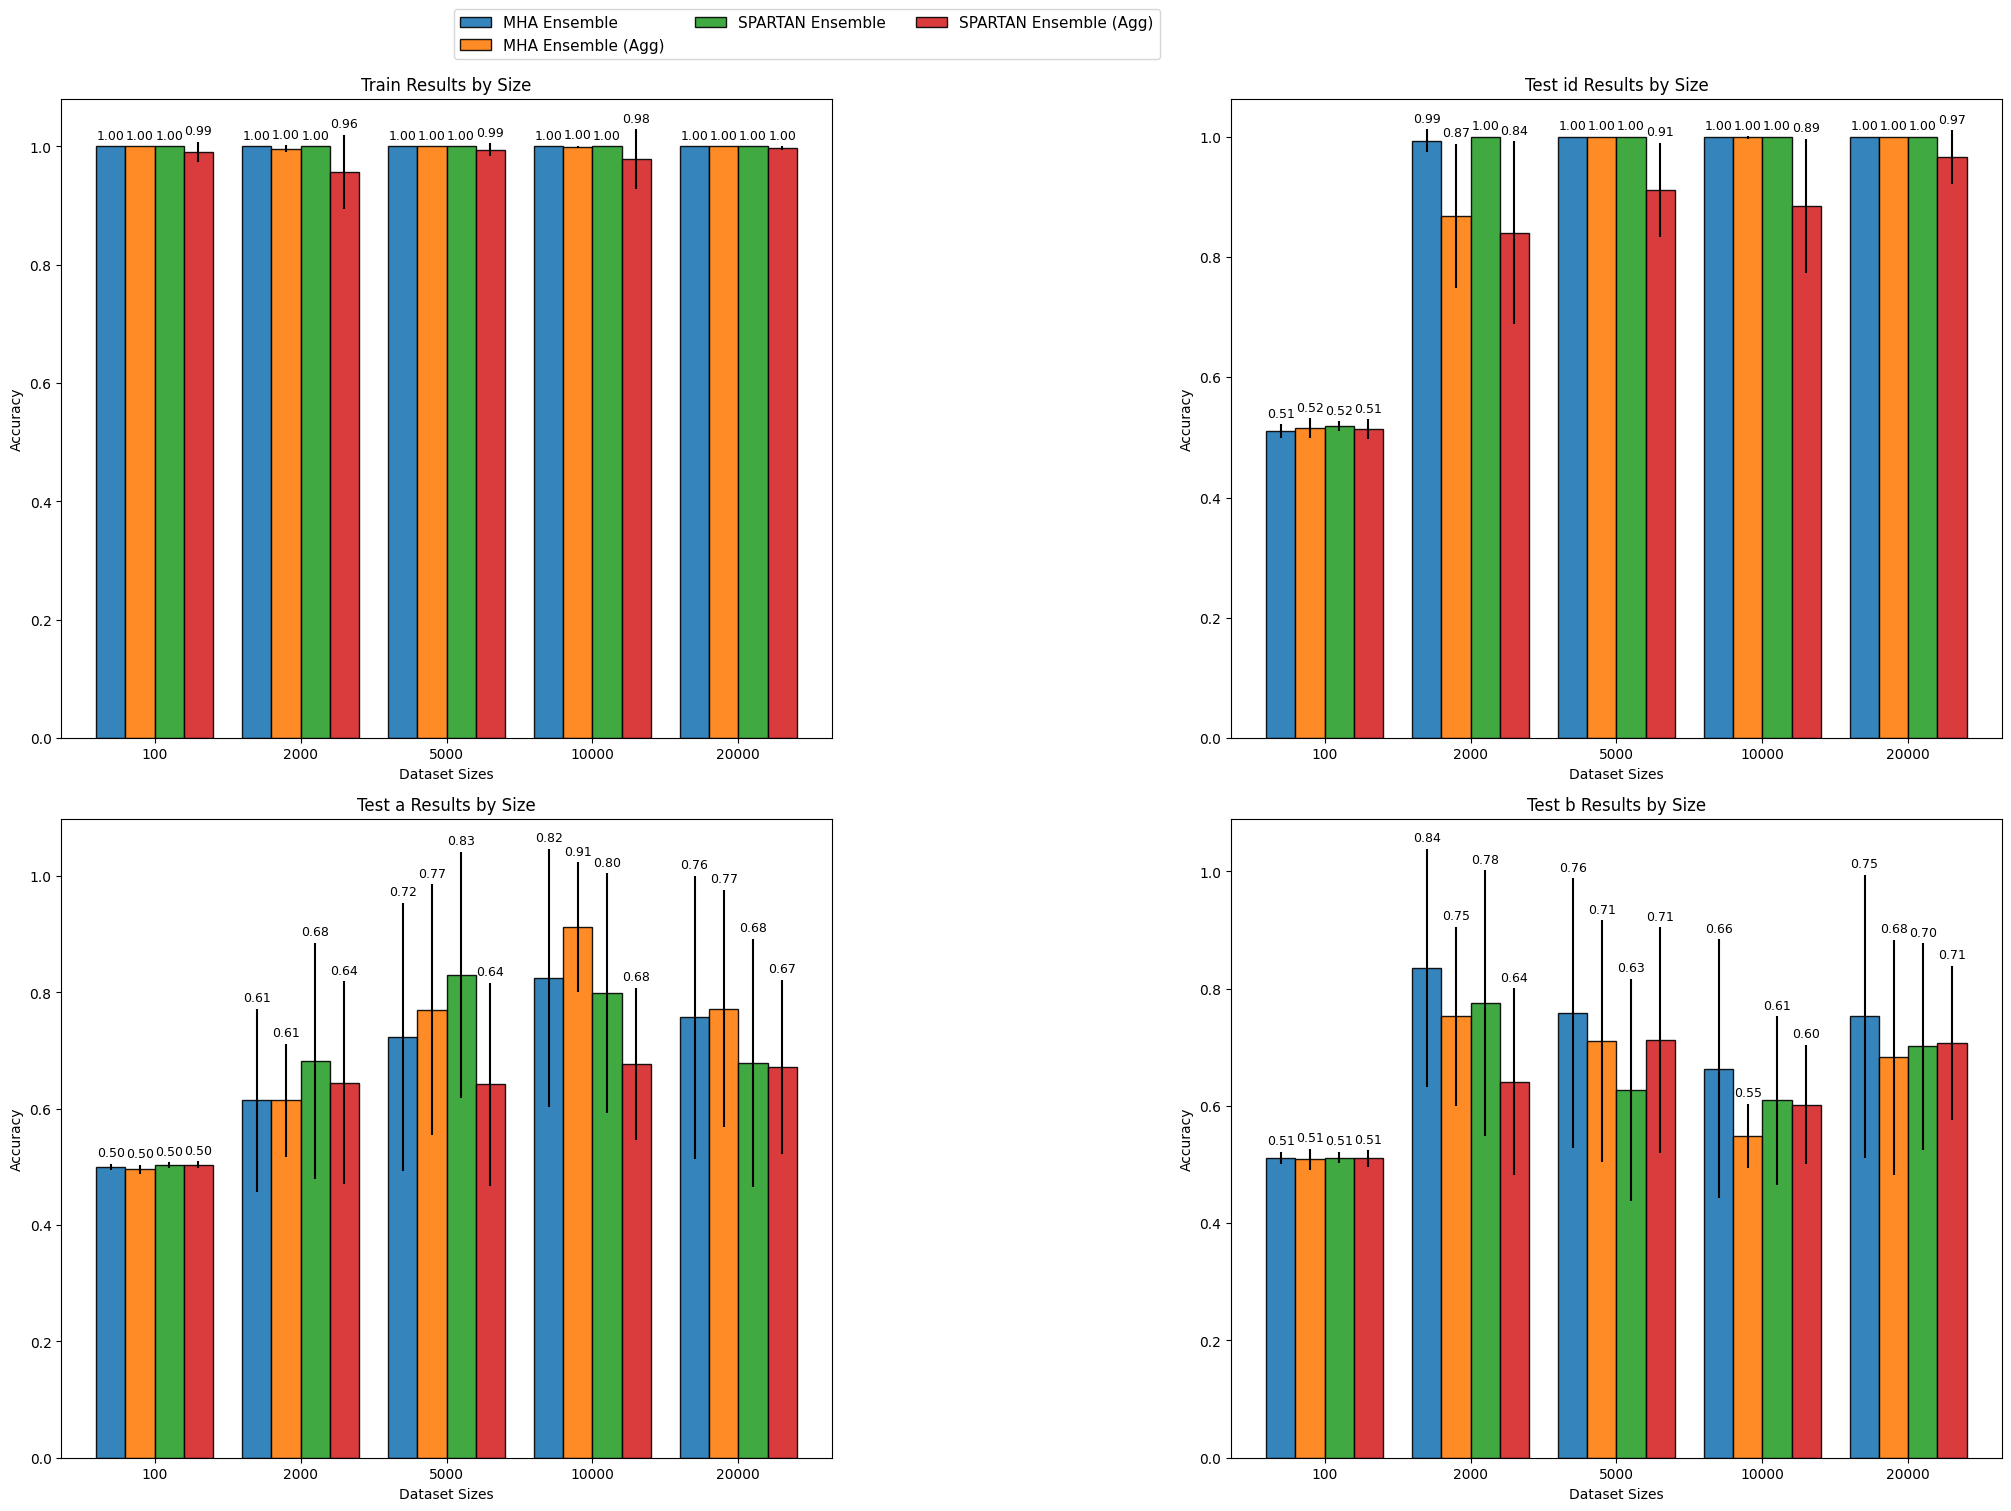

In [11]:
draw_chart_shapes(
    [{'model_name' : 'ensemble_shapes', 'name': 'MHA Ensemble', 'spartan' : True},
     {'model_name' : 'ensemble_shapes_agg', 'name': 'MHA Ensemble (Agg)', 'spartan' : True},  
    {'model_name' : 'ensemble_shapes_spartan', 'name': 'SPARTAN Ensemble', 'spartan' : True},
    {'model_name' : 'ensemble_shapes_agg_spartan', 'name': 'SPARTAN Ensemble (Agg)', 'spartan' : True}
      ],
    grid=5,
    sizes=[100, 2000, 5000, 10000, 20000]
);

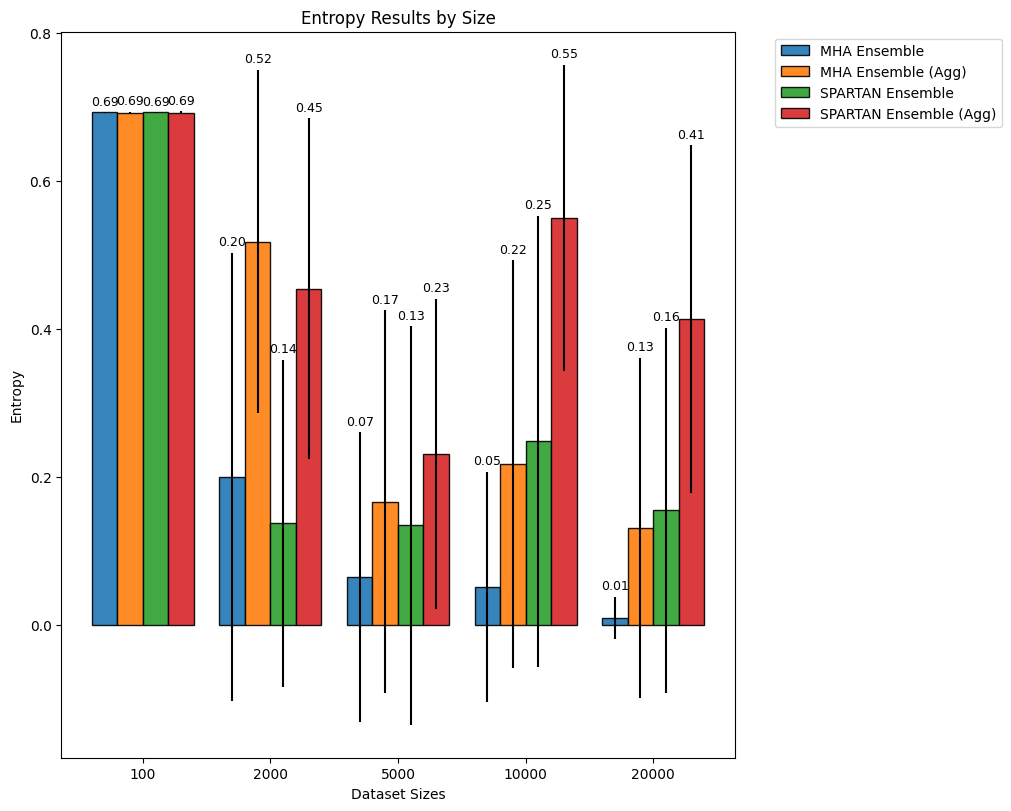

In [14]:
draw_entropy(
    [{'model_name' : 'ensemble_shapes', 'name': 'MHA Ensemble', 'spartan' : True},
     {'model_name' : 'ensemble_shapes_agg', 'name': 'MHA Ensemble (Agg)', 'spartan' : True},  
    {'model_name' : 'ensemble_shapes_spartan', 'name': 'SPARTAN Ensemble', 'spartan' : True},
    {'model_name' : 'ensemble_shapes_agg_spartan', 'name': 'SPARTAN Ensemble (Agg)', 'spartan' : True}
      ],
    grid=5,
    sizes=[100, 2000, 5000, 10000, 20000]
);

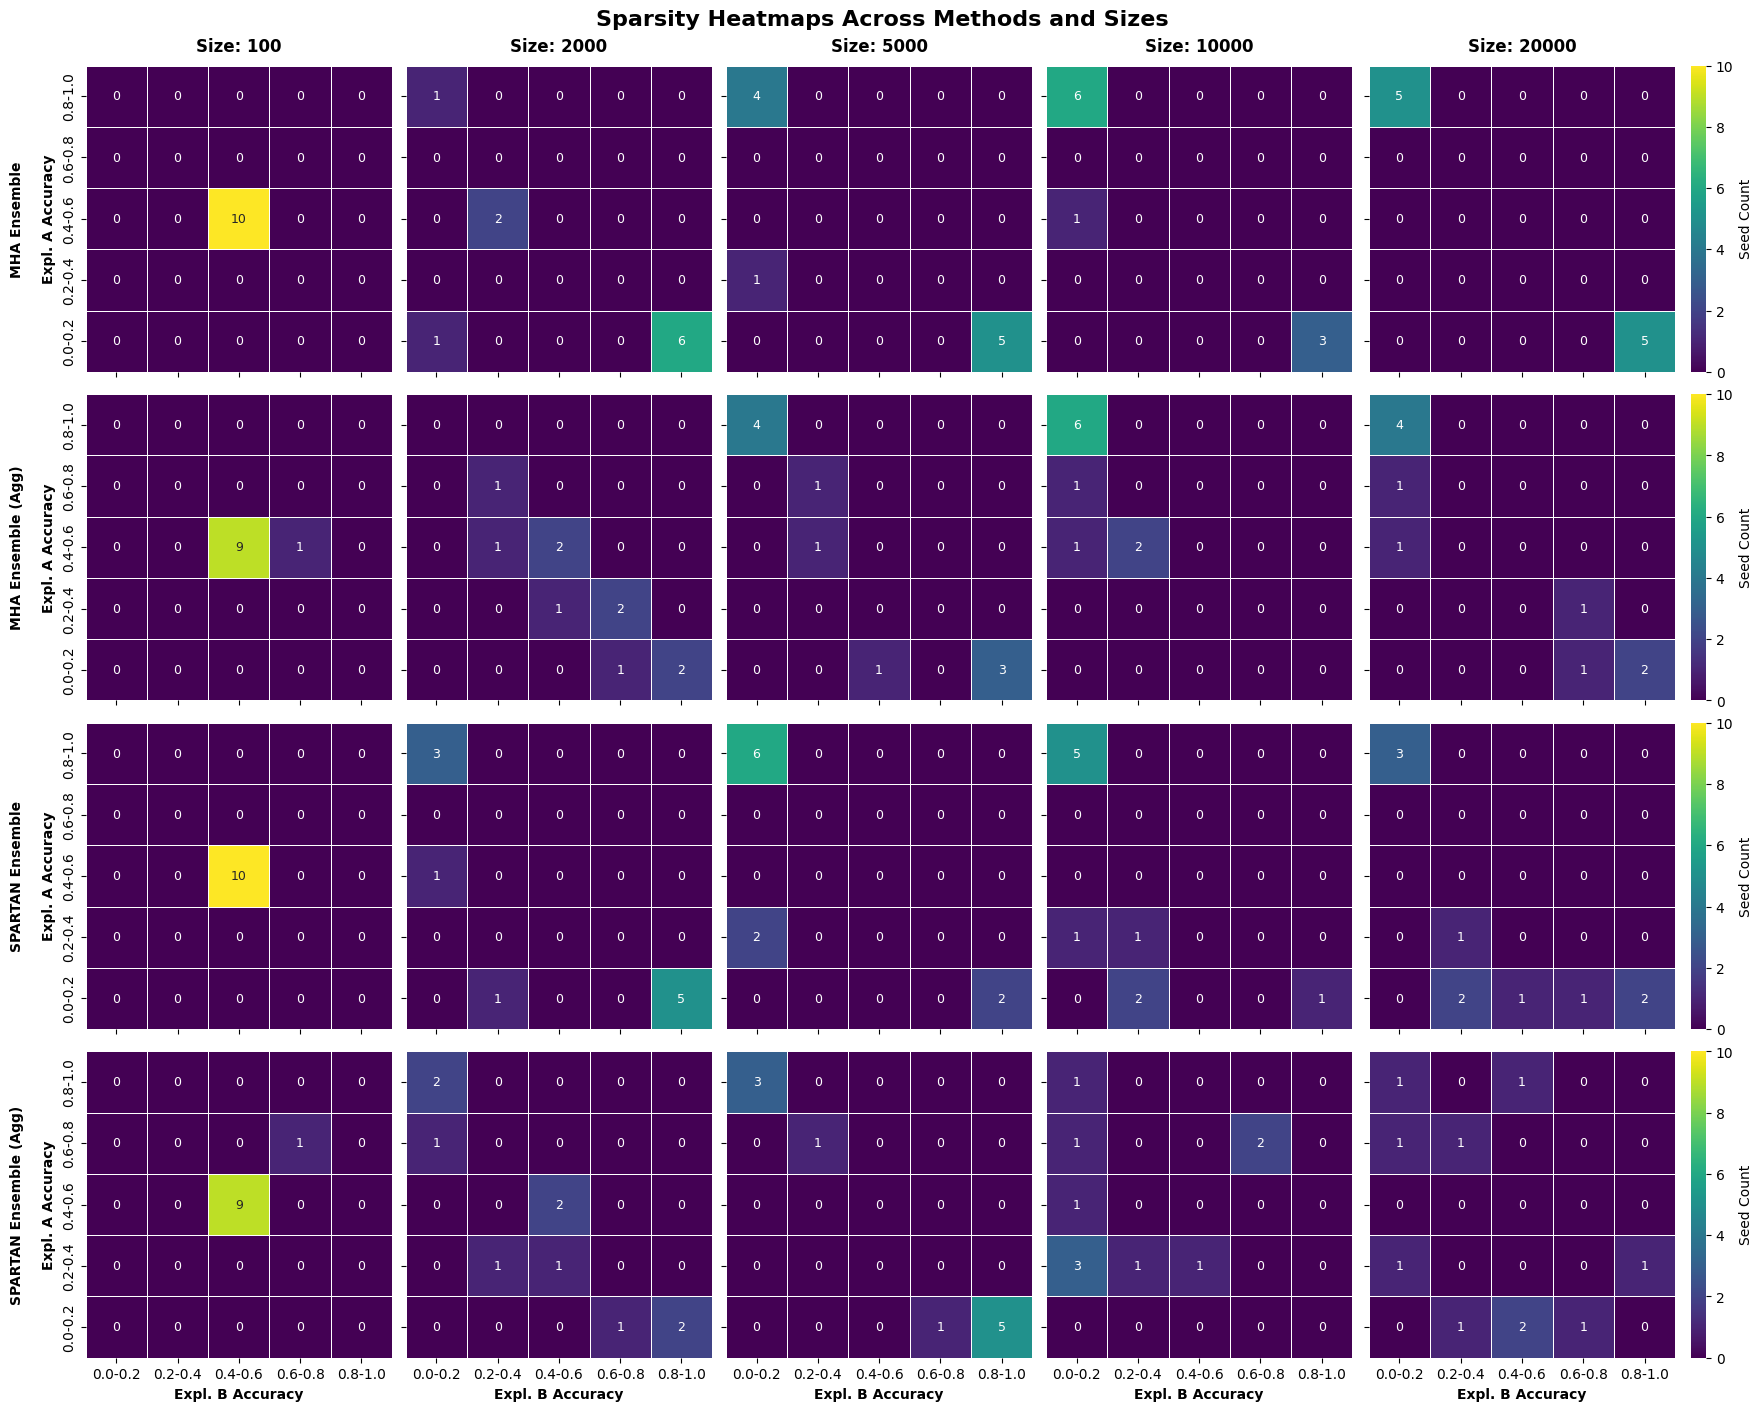

In [15]:
draw_2d_heatmap(
     [{'model_name' : 'ensemble_shapes', 'name': 'MHA Ensemble', 'spartan' : True},
    {'model_name' : 'ensemble_shapes_agg', 'name': 'MHA Ensemble (Agg)', 'spartan' : True},  
    {'model_name' : 'ensemble_shapes_spartan', 'name': 'SPARTAN Ensemble', 'spartan' : True},
    {'model_name' : 'ensemble_shapes_agg_spartan', 'name': 'SPARTAN Ensemble (Agg)', 'spartan' : True}
    ],
);
